<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Dr. Sharifi-Zarchi, Fall 2025 <br>
<font color=3C99D size=5>
Practical Assignment 5 - Natural Language Processing <br>
<font color=696880 size=4>
By: Sina Bayrami

</center>


# Notebook Overview — NER from BiLSTM to (Tiny)BERT

This notebook is a **hands-on, end-to-end practical lab** for a core NLP task: **Named Entity Recognition (NER)**.  
You will start from a strong non-Transformer baseline and gradually build up the ideas that lead to modern Transformer encoders and BERT-style pretraining—then you will compare those approaches fairly on the **same NER problem**.

The goal is not to “memorize architectures”, but to **learn what each ingredient adds**, why it matters, and how to evaluate models correctly.

## 1) What is NER and what are we trying to do?


**Named Entity Recognition (NER)** is a **token-level sequence labeling** task.

- **Input:** a sentence as a sequence of tokens  
  $$
  x = (x_1, x_2, \dots, x_T)
  $$
- **Output:** a label for each token  
  $$
  y = (y_1, y_2, \dots, y_T)
  $$
  where labels usually follow a BIO-style format (e.g., **B-PERSON**, **I-ORG**, **O**).

**What we want:** learn a model $f_\theta$ that predicts the correct tag for each token:
$$
\hat{y}_t = \arg\max_k \; p_\theta(y_t = k \mid x)
$$

NER is difficult because:
- Entities can span multiple tokens (e.g., “New York City”)
- Context matters (e.g., “Jordan” can be a person or a location)
- Most tokens are **not** entities → the label **O** is dominant

## 2) How we evaluate: Metrics (and why F1 is the main one)

In NER, **token accuracy** can be misleading because a model can predict **O** almost everywhere and still look “good”.

So we use two families of metrics:

### A) Token Accuracy (quick sanity metric)
Token accuracy is:
$$
\text{Acc}=\frac{\#\{t:\hat{y}_t=y_t\}}{T}
$$
But because **O** dominates, accuracy often hides failures on entities.

### B) Entity-level Precision / Recall / F1 (the main metric)
We care about **entities as spans**, not just individual tokens.

From a BIO tag sequence we extract a set of predicted entity spans $\hat{E}$ and gold spans $E$.  
A predicted entity is counted as **correct (TP)** only if:
- the span boundaries match exactly, and
- the entity type matches exactly

Define:
- $TP$: number of correctly predicted entities  
- $FP$: predicted entities not in gold  
- $FN$: gold entities missed by the model  

Then:
$$
P=\frac{TP}{TP+FP},\qquad
R=\frac{TP}{TP+FN}
$$
and the **F1-score** is the harmonic mean:
$$
F1 = \frac{2PR}{P+R}
$$
F1 heavily penalizes models that:
- miss entities (high FN → low recall),
- hallucinate entities (high FP → low precision),
- or get boundaries/types wrong (not counted as TP).

**In this notebook, the most important score is entity-level F1.**  
Token accuracy is mainly a secondary diagnostic.

## 3) What happens in each stage?

### Part 1 — Baseline: BiLSTM Tagger (sequential encoder)
Start with a strong classical baseline:
- a contextual encoder that reads tokens left-to-right and right-to-left
- predicts a tag per token

**What you learn:** a sequential model captures order naturally, but has limited parallelism and long-range interaction costs.

---

### Part 2 — Add Self-Attention on top of the baseline
You keep the baseline encoder and **add a single self-attention mechanism** after it.

**What you learn:** attention can mix global context and sometimes improve tagging quality; attention maps are also interpretable.

---

### Part 3 — Attention-only (remove the sequential encoder)
Now you remove the sequential component and try a model that relies on **self-attention only**, without any explicit notion of position.

**What you learn:** self-attention alone can mix token content, but **does not inherently know order**, so performance can degrade on tasks where order matters.

---

### Part 4 — Fix the order problem by adding Positional Encoding
You keep the attention-only design, but now inject **positional information** into the token representations.

**What you learn:** adding position makes attention usable for order-sensitive tasks, and you can directly compare Part 3 vs Part 4 as an ablation.

---

### Part 5 — Upgrade to Multi-Head Attention
You replace single attention with **multi-head attention**, so the model can represent different relation patterns in parallel.

**What you learn:** multiple heads can specialize (local vs long-range, boundaries vs separators, etc.), and you can visualize different heads.

---

### Part 6 — Build a deeper Transformer encoder (“mini-BERT brick”) + depth ablation
You turn the attention block into a standard encoder layer and stack layers to study **depth vs performance**.

**What you learn:** depth can help, but not always; optimization and overfitting constraints appear; ablations teach you what matters empirically.

---

### Part 7 — BERT-style inputs and embedding recipe
You transition from “generic sequence tagging inputs” to **BERT-style inputs**:
- special tokens ([CLS], [SEP], [MASK])
- token type (segment) IDs
- position IDs
- embedding composition used by BERT-like models

**What you learn:** how the input representation design supports pretraining and downstream fine-tuning.

---

### Part 8 — Pretraining objective: MLM (Masked Language Modeling)
You pretrain your encoder on **MLM**, where only a subset of tokens are predicted (masked positions).

**What you learn:** pretraining teaches general language/statistical structure without labels, and the masking strategy matters.

---

### Part 9 — Pretraining objective: NSP + joint MLM+NSP
You extend pretraining with a second objective: **Next Sentence Prediction (NSP)**, and train with MLM+NSP jointly.

**What you learn:** multi-objective pretraining, what NSP is trying to encourage, and why its benefit can be mixed.

---

### Part 10 — Fine-tune TinyBERT for NER (scratch vs pretrained initializations)
You fine-tune on NER and compare three conditions under a similar fine-tuning budget:
- random initialization (scratch)
- MLM-pretrained initialization
- MLM+NSP-pretrained initialization

**What you learn:** how pretraining affects downstream learning speed, stability, and final entity F1.

---

### Part 11 — Fine-tune a foundation model (pretrained DistilBERT/BERT)
You fine-tune a real pretrained Transformer model using a modern library pipeline.

**What you learn:** what large-scale pretraining buys you in practice (data efficiency + stronger performance), and how subword tokenization affects label alignment conceptually.

---

### Part 12 — Analysis Lab: attention interpretability + computational cost
You treat the final part like a mini research lab:
- visualize attention maps from a fine-tuned pretrained model
- inspect predictions vs gold labels
- measure how runtime scales with sequence length
- build a final comparison table across all approaches

**What you learn:** interpretability signals (with caution), and the practical limitation of attention’s quadratic scaling.

## 4) The full “sequence chain” of the notebook (the big picture)

You can summarize the notebook progression as:

1. **Reliable NER evaluation + reproducible training loop**  
2. **Sequential baseline (BiLSTM)**  
3. **Add attention (global mixing) while keeping sequence awareness**  
4. **Remove sequence awareness → observe failure**  
5. **Restore order with positional encoding → recover performance**  
6. **Scale attention with multi-head + depth → stronger encoder**  
7. **Adopt BERT-style input/embedding recipe**  
8. **Pretrain with MLM (self-supervision)**  
9. **Optionally add NSP and compare**  
10. **Fine-tune and measure the value of pretraining**  
11. **Compare against a real pretrained foundation model**  
12. **Interpret + analyze efficiency and limitations**

This is a controlled story of **how modern Transformer encoders emerge from specific design decisions**.

## 5) What we expect you to practice while completing TODOs

As you fill in TODO sections, your focus should be:
- correctness and reproducibility (your code must rerun cleanly)
- fair comparisons (avoid changing multiple factors at once)
- careful evaluation (use entity F1 as the main score)
- interpretation (attention maps and failure cases are part of the learning)

Whenever you change something important, document it briefly in a Markdown cell near the change.

## 6) Grading criteria

Your grade in this notebook will be based on:

1. **Correct implementation and rerunnability**  
   Your solutions must be correct and the notebook should run end-to-end when re-executed.

2. **Reasonable training progression**  
   Training curves should show a sensible learning trend (loss decreasing, metrics stabilizing).

3. **Reasonable final performance per part**  
   You do *not* need the absolute best score, but your results should not be drastically below the expected ranges shown in each section output.

4. **Quality of plots and visualizations**  
   Curves and attention heatmaps must be clearly plotted, labeled, and interpretable.

5. **Correct and well-explained answers to Concept Checks**  
   Method questions and interpretation questions must be answered accurately and with clear reasoning.

## 7) Notes for students (important)

- You are allowed to modify any code, **but your notebook will be re-run by the grader**.  
  Write clean, stable code and avoid hidden dependencies.

- Try to keep model comparisons under **equal conditions** as much as possible (same data splits, same evaluation logic, similar budgets) so the comparisons are fair.

- Do **not** change the core assignment identity:
  - keep the task as **NER**
  - keep the selected dataset
  - do not replace the overall model families with unrelated architectures

- You have flexibility in details:
  - hyperparameters, number of epochs, optimization choices, regularization, etc.
  - but if you change something important, explain why (briefly) in Markdown.

- If a section gives unexpected results (low F1, overfitting, worse than a previous model, etc.),
  you can still earn partial or even full credit for that section **if you diagnose the reason correctly and explain it clearly**.

---

# Install Dependencies

In [30]:
!pip -q install seqeval

In [31]:
!pip -q install -U transformers accelerate

# Part 0 — Setup, Data Pipeline, and Evaluation Harness

In this part, **we build the experimental foundation** that every later section relies on. The main goal is not modeling yet—it is making sure we can **load the dataset**, **represent sequences with padding/masks**, and **evaluate NER correctly** (especially with **entity-level F1**, not just token accuracy).

Most later parts reuse the same interfaces designed here (dataset → dataloader → model → loss → metrics). So we should write Part 0 as if we are preparing a small, reliable research framework.

## What we should have by the end of Part 0

- A reproducible setup (seeds + device)
- A dataset object that returns token sequences and NER tags
- A collate function that pads inputs and labels correctly  
  (and does **not** let padded tokens influence loss/metrics)
- A label mapping (`label2id`, `id2label`) that is consistent and checked
- A reliable metric function that reports:
  - token accuracy (sanity only)
  - entity-level precision / recall / F1 (main score)

## Imports and Logging Hygiene

We import all libraries used throughout the notebook and suppress noisy warnings/logs so outputs stay readable and focused on the experiments.

In [32]:
!pip -q install -U datasets huggingface_hub


In [33]:
from datasets import load_dataset, DatasetDict


In [34]:
import os
import warnings

# --- Reduce noisy HuggingFace logs ---
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()  # only show errors

# --- Reduce a common PyTorch DataParallel warning ---
warnings.filterwarnings(
    "ignore",
    message=r"Was asked to gather along dimension 0, but all input tensors were scalars.*",
    category=UserWarning,
)

# --- Standard library / utilities ---
from dataclasses import dataclass
from typing import List, Dict, Tuple
import random
import math
import time
import inspect
from collections import Counter

# --- Numerics / data ---
import numpy as np
import pandas as pd

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# --- Datasets + evaluation ---
from datasets import load_dataset, DatasetDict
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from dataclasses import dataclass

# --- Visualization / progress ---
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Transformers (later parts use these) ---
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    
)

## Configuration (CFG)

Centralizes the key hyperparameters and conventions (seed, batch size, vocabulary limits, padding/ignore rules) so experiments stay consistent and easy to modify.

In [35]:
@dataclass
class CFG:
    # Reproducibility / dataloading
    seed: int = 34
    batch_size: int = 32
    num_workers: int = 2

    # Vocabulary (for from-scratch / word-level baselines)
    max_vocab_size: int = 50_000
    min_freq: int = 2
    pad_token: str = "<pad>"
    unk_token: str = "<unk>"

    # Label padding rule for masked loss/metrics
    ignore_index: int = -100

cfg = CFG()
cfg

CFG(seed=34, batch_size=32, num_workers=2, max_vocab_size=50000, min_freq=2, pad_token='<pad>', unk_token='<unk>', ignore_index=-100)

## Reproducibility (Seeding) and Device Selection

Set random seeds and determinism settings so runs are comparable, then select the compute device (CPU/GPU) used throughout the notebook.

In [36]:
# TODO:
# Implement a seeding utility that makes experiments reproducible.
#
# Requirements:
# - Seed Python's `random`
# - Seed NumPy
# - Seed PyTorch (CPU) and CUDA (if available)
# - (Optional but recommended) set deterministic flags for cuDNN
#
# Notes:
# - Full determinism can be slower.
# - The goal is that re-running the notebook yields similar curves/metrics.

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Load the OntoNotes5 NER Dataset (HuggingFace)

We load the train/validation/test splits and print basic sanity checks (sizes + available columns) to verify the dataset pipeline is correct.

In [37]:
BASE = "https://huggingface.co/datasets/tner/ontonotes5/resolve/refs/convert/parquet/ontonotes5"

data_files = {
    "train": f"{BASE}/train/0000.parquet",
    "validation": f"{BASE}/validation/0000.parquet",
    "test": f"{BASE}/test/0000.parquet",
}

ds = load_dataset("parquet", data_files=data_files)

print(ds)
print("Columns:", ds["train"].column_names)
print("Train size:", len(ds["train"]))
print("Valid size:", len(ds["validation"]))
print("Test size :", len(ds["test"]))

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 59924
    })
    validation: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 8528
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 8262
    })
})
Columns: ['tokens', 'tags']
Train size: 59924
Valid size: 8528
Test size : 8262


## Normalize the Dataset Schema (Ensure We Have `ner_tags`)

Different NER exports sometimes use different column names for labels. This cell standardizes the label column name to `ner_tags` so the rest of the notebook can stay consistent.

In [38]:
# Part 0 — Ensure the dataset has a consistent NER label column name: `ner_tags`

print("Columns:", ds["train"].column_names)

def ensure_ner_tags(ds, preferred: str = "ner_tags"):
    cols = ds["train"].column_names
    if preferred in cols:
        return ds

    # Common alternatives in parquet exports / NER datasets
    candidates = ["tags", "ner", "labels", "bio_tags", "ner_tag", "ner_labels"]
    for cand in candidates:
        if cand in cols:
            print(f"Renaming '{cand}' -> '{preferred}'")
            return ds.rename_column(cand, preferred)

    raise KeyError(f"Could not find NER label column. Available columns: {cols}")

ds = ensure_ner_tags(ds, preferred="ner_tags")
print("After normalize:", ds["train"].column_names)

Columns: ['tokens', 'tags']
Renaming 'tags' -> 'ner_tags'
After normalize: ['tokens', 'ner_tags']


## Define the Fixed OntoNotes5 Label Space (and Sanity-Check)

We will use the official OntoNotes5 BIO label mapping so that decoding, metrics, and model heads all agree on the exact label IDs. We also sanity-check that the dataset does not contain unknown tag IDs.

In [39]:
ONTONOTES_LABEL2ID = {
    "O": 0,
    "B-CARDINAL": 1,
    "B-DATE": 2,
    "I-DATE": 3,
    "B-PERSON": 4,
    "I-PERSON": 5,
    "B-NORP": 6,
    "B-GPE": 7,
    "I-GPE": 8,
    "B-LAW": 9,
    "I-LAW": 10,
    "B-ORG": 11,
    "I-ORG": 12,
    "B-PERCENT": 13,
    "I-PERCENT": 14,
    "B-ORDINAL": 15,
    "B-MONEY": 16,
    "I-MONEY": 17,
    "B-WORK_OF_ART": 18,
    "I-WORK_OF_ART": 19,
    "B-FAC": 20,
    "B-TIME": 21,
    "I-CARDINAL": 22,
    "B-LOC": 23,
    "B-QUANTITY": 24,
    "I-QUANTITY": 25,
    "I-NORP": 26,
    "I-LOC": 27,
    "B-PRODUCT": 28,
    "I-TIME": 29,
    "B-EVENT": 30,
    "I-EVENT": 31,
    "I-FAC": 32,
    "B-LANGUAGE": 33,
    "I-PRODUCT": 34,
    "I-ORDINAL": 35,
    "I-LANGUAGE": 36,
}

# Reverse mapping (id -> label string)
id2label = {v: k for k, v in ONTONOTES_LABEL2ID.items()}
label2id = ONTONOTES_LABEL2ID

max_id = max(id2label)
label_names = [id2label[i] for i in range(max_id + 1)]  # index == label_id
num_labels = len(label_names)

print("Num labels:", num_labels)
print("Max id:", max_id)
print("First 10:", label_names[:10])

# Sanity-check: dataset should not contain label IDs outside this mapping
all_ids = set()
for split in ["train", "validation", "test"]:
    for seq in ds[split]["ner_tags"]:
        all_ids.update(seq)

missing = sorted([i for i in all_ids if i not in id2label])
if missing:
    raise ValueError(f"Dataset contains unknown label ids: {missing}")

print("All dataset label ids are covered")

Num labels: 37
Max id: 36
First 10: ['O', 'B-CARDINAL', 'B-DATE', 'I-DATE', 'B-PERSON', 'I-PERSON', 'B-NORP', 'B-GPE', 'I-GPE', 'B-LAW']
All dataset label ids are covered


## Robust Label-Space Construction

Some dataset formats preserve label-name metadata, while others only store integer IDs. This cell builds a reliable `label_names / label2id / id2label` setup by first using metadata if available, and otherwise inferring what it can from the data—while remaining compatible with the fixed OntoNotes mapping.

In [40]:
def infer_label_ids_from_split(split, col: str = "ner_tags", max_scan: int | None = None):
    """
    Infer label information when metadata is missing.

    - If tags are strings -> return sorted unique strings (with "O" first if present).
    - If tags are ints    -> return sorted unique int IDs (mapping to names handled elsewhere).
    """
    n = len(split) if max_scan is None else min(len(split), max_scan)

    first_seq = split[0][col]
    if len(first_seq) == 0:
        raise ValueError("Empty tag sequence encountered.")

    # Case 1: tags are strings already
    if isinstance(first_seq[0], str):
        s = set()
        for i in range(n):
            s.update(split[i][col])
        names = sorted(s)
        if "O" in names:
            names = ["O"] + [x for x in names if x != "O"]
        return names

    # Case 2: tags are ints (metadata missing)
    if isinstance(first_seq[0], (int, np.integer)):
        s = set()
        for i in range(n):
            s.update(split[i][col])
        return sorted(int(x) for x in s)

    raise TypeError(f"Unknown tag type: {type(first_seq[0])}")


# 1) Try to read metadata (works when Sequence(ClassLabel) is preserved)
label_names = None
feat = ds["train"].features.get("ner_tags", None)

if feat is not None and hasattr(feat, "feature") and hasattr(feat.feature, "names"):
    label_names = list(feat.feature.names)

# 2) Otherwise infer from data
if label_names is None:
    inferred = infer_label_ids_from_split(ds["train"], col="ner_tags", max_scan=20_000)

    # If inferred is ints -> use the official OntoNotes mapping
    if len(inferred) > 0 and isinstance(inferred[0], int):
        label2id = ONTONOTES_LABEL2ID
        id2label = {v: k for k, v in label2id.items()}
        label_names = [id2label[i] for i in range(max(id2label) + 1)]
    else:
        # inferred is already list[str]
        label_names = inferred
        label2id = {name: i for i, name in enumerate(label_names)}
        id2label = {i: name for name, i in label2id.items()}

num_labels = len(label_names)
print("Num labels:", num_labels)
print("First labels:", label_names[:20])

Num labels: 37
First labels: ['O', 'B-CARDINAL', 'B-DATE', 'I-DATE', 'B-PERSON', 'I-PERSON', 'B-NORP', 'B-GPE', 'I-GPE', 'B-LAW', 'I-LAW', 'B-ORG', 'I-ORG', 'B-PERCENT', 'I-PERCENT', 'B-ORDINAL', 'B-MONEY', 'I-MONEY', 'B-WORK_OF_ART', 'I-WORK_OF_ART']


## Quick Data Sanity Check (Tokens + Decoded Tags)

Before building models, I always inspect a couple of raw examples. This cell prints tokens alongside their NER tags (decoded to strings if needed) so you can confirm the dataset is loaded correctly and the label mapping behaves as expected.

In [41]:
def show_sample(i: int = 0, split: str = "train") -> None:
    ex = ds[split][i]
    tokens = ex["tokens"]
    tags = ex["ner_tags"]

    # If tags are ints, decode them; if already strings, keep them.
    if len(tags) > 0 and isinstance(tags[0], int):
        tags = [id2label[int(t)] for t in tags]

    print("TOKENS:", tokens)
    print("TAGS  :", tags)


show_sample(34, "train")
print("-" * 80)
show_sample(43, "train")

TOKENS: ['Employers', 'must', 'deposit', 'withholding', 'taxes', 'exceeding', '$', '3,000', 'within', 'three', 'days', 'after', 'payroll', '--', 'or', 'pay', 'stiff', 'penalties', '--', 'and', 'that', "'s", 'a', 'big', 'problem', 'for', 'small', 'businesses', '.']
TAGS  : ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-MONEY', 'O', 'B-DATE', 'I-DATE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
--------------------------------------------------------------------------------
TOKENS: ['Alice', 'Fixx', ',', 'who', 'runs', 'her', 'own', 'public', '-', 'relations', 'concern', 'in', 'New', 'York', ',', 'says', 'she', 'has', 'had', 'to', 'overhaul', 'her', 'pension', 'and', 'profit', '-', 'sharing', 'plans', 'three', 'times', 'in', 'the', 'past', 'three', 'years', '.']
TAGS  : ['B-PERSON', 'I-PERSON', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-GPE', 'I-GPE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CARDINAL', 'O', 

## Build a Word-Level Vocabulary (for the from-scratch baselines)

In the early parts of this notebook, we will train non-Transformer models on **word IDs**.  
This cell builds a vocabulary from the training tokens and creates both mappings:

- `stoi`: string → integer ID  
- `itos`: integer ID → string  

Your implementation choices here (normalization, frequency thresholds, vocab cap, special tokens) will affect downstream results, so document what you decide.

Vocab design choices:
- Built ONLY from ds["train"]["tokens"] (no leakage).
- Reserved special tokens: PAD=0, UNK=1.
- Applied normalization: lowercase + digit masking (e.g., "1999"->"0000", "v2"->"v0").
- Kept tokens with freq >= cfg.min_freq.
- Capped vocab to cfg.max_vocab_size (including specials).


In [42]:
from collections import Counter
from typing import List, Dict, Tuple

def normalize_token(tok: str) -> str:
    # Optional normalization (simple + effective):
    tok = tok.lower()
    # digit masking: "1999" -> "0", "v2" -> "v0"
    tok = "".join("0" if ch.isdigit() else ch for ch in tok)
    return tok

def build_word_vocab(
    sentences: List[List[str]],
    pad_token: str,
    unk_token: str,
    max_vocab_size: int,
    min_freq: int,
) -> Tuple[Dict[str, int], Dict[int, str]]:
    # Count tokens from TRAIN ONLY
    counter = Counter()
    for sent in sentences:
        counter.update(normalize_token(t) for t in sent)

    # Reserve special tokens
    specials = [pad_token, unk_token]
    stoi: Dict[str, int] = {pad_token: 0, unk_token: 1}
    itos: Dict[int, str] = {0: pad_token, 1: unk_token}

    # Filter by min_freq, then sort by frequency (desc), then alphabetically for stability
    items = [(tok, freq) for tok, freq in counter.items() if freq >= min_freq and tok not in stoi]
    items.sort(key=lambda x: (-x[1], x[0]))

    # Cap vocab size (including specials)
    cap = max(0, max_vocab_size - len(specials))
    for tok, _ in items[:cap]:
        idx = len(stoi)
        stoi[tok] = idx
        itos[idx] = tok

    return stoi, itos


# --- Build vocab from training split ---
train_tokens = ds["train"]["tokens"]
stoi, itos = build_word_vocab(
    sentences=train_tokens,
    pad_token=cfg.pad_token,
    unk_token=cfg.unk_token,
    max_vocab_size=cfg.max_vocab_size,
    min_freq=cfg.min_freq,
)

print("Vocab size:", len(stoi))
print("PAD id:", stoi[cfg.pad_token], "UNK id:", stoi[cfg.unk_token])
print("Top few ids:", {i: itos[i] for i in range(min(10, len(itos)))})


Vocab size: 20603
PAD id: 0 UNK id: 1
Top few ids: {0: '<pad>', 1: '<unk>', 2: 'the', 3: ',', 4: '.', 5: 'of', 6: 'to', 7: 'and', 8: 'a', 9: 'in'}


## Wrap the NER Data as a PyTorch Dataset (word-level IDs)

This cell defines a simple `Dataset` that converts each example into `(input_ids, labels)` for the from-scratch baselines, while still keeping the raw tokens for debugging and qualitative inspection.

In [43]:
class NERWordDataset(Dataset):
    """
    Word-level NER dataset:
    - Converts token strings into integer IDs using `stoi`
    - Returns aligned NER label IDs from the dataset
    - Keeps raw tokens for debugging/inspection
    """
    def __init__(self, hf_split, stoi: Dict[str, int]):
        self.split = hf_split
        self.stoi = stoi
        self.unk_id = stoi[cfg.unk_token]

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        input_ids = [self.stoi.get(tok, self.unk_id) for tok in tokens]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "tokens": tokens,  # keep raw tokens for debugging
        }


train_ds = NERWordDataset(ds["train"], stoi)
valid_ds = NERWordDataset(ds["validation"], stoi)
test_ds  = NERWordDataset(ds["test"], stoi)

print(
    f"train length: {len(train_ds)}\n"
    f"validation length: {len(valid_ds)}\n"
    f"test length: {len(test_ds)}"
)

train length: 59924
validation length: 8528
test length: 8262


## Collate Function + DataLoaders (padding, masks, and label ignoring)

In this cell you will implement batching for variable-length token sequences: pad `input_ids`, build an `attention_mask`, and pad `labels` using an ignore index so padded positions do not contribute to loss or metrics. Then you will plug this collate function into PyTorch `DataLoader`s.

In [44]:
from typing import List, Dict
import torch
from torch.utils.data import DataLoader

def ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    pad_id = stoi[cfg.pad_token]
    ignore_index = cfg.ignore_index

    lengths = [len(ex["input_ids"]) for ex in batch]
    max_len = max(lengths) if lengths else 0
    B = len(batch)

    input_ids = torch.full((B, max_len), pad_id, dtype=torch.long)
    attention_mask = torch.zeros((B, max_len), dtype=torch.long)
    labels = torch.full((B, max_len), ignore_index, dtype=torch.long)

    for i, ex in enumerate(batch):
        ids = ex["input_ids"]
        y = ex["labels"]
        L = len(ids)
        input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
        attention_mask[i, :L] = 1
        labels[i, :L] = torch.tensor(y, dtype=torch.long)

    out = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "lengths": torch.tensor(lengths, dtype=torch.long),
    }

    if "tokens" in batch[0]:
        out["tokens"] = [ex["tokens"] for ex in batch]

    return out

cfg.num_workers = 0

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in batch.items()}


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


{'input_ids': torch.Size([32, 68]),
 'attention_mask': torch.Size([32, 68]),
 'labels': torch.Size([32, 68]),
 'lengths': torch.Size([32]),
 'tokens': list}

## Metrics Utilities (masking, decoding, and seqeval formatting)

In this cell you will implement the metric utilities used throughout the notebook. Your goal is to (1) correctly ignore padded positions, (2) convert label IDs into BIO tag strings, and (3) compute both token accuracy and entity-level precision/recall/F1 using `seqeval`.

In [45]:
from typing import List, Dict, Tuple
import torch
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

def ids_to_tags(
    label_ids: torch.Tensor,
    pred_ids: torch.Tensor,
) -> Tuple[List[List[str]], List[List[str]]]:
    y_true: List[List[str]] = []
    y_pred: List[List[str]] = []

    label_ids = label_ids.detach().cpu()
    pred_ids = pred_ids.detach().cpu()

    B, T = label_ids.shape

    for i in range(B):
        true_tags: List[str] = []
        pred_tags: List[str] = []
        for j in range(T):
            gold = int(label_ids[i, j].item())
            if gold == cfg.ignore_index:
                continue
            pred = int(pred_ids[i, j].item())
            true_tags.append(label_names[gold])
            pred_tags.append(label_names[pred])
        y_true.append(true_tags)
        y_pred.append(pred_tags)

    return y_true, y_pred


@torch.no_grad()
def compute_token_accuracy(label_ids: torch.Tensor, pred_ids: torch.Tensor) -> float:
    mask = (label_ids != cfg.ignore_index)
    correct = (pred_ids == label_ids) & mask
    denom = int(mask.sum().item())
    return float(correct.sum().item() / denom) if denom > 0 else 0.0


@torch.no_grad()
def compute_ner_metrics(
    label_ids: torch.Tensor,
    pred_ids: torch.Tensor,
    verbose: bool = False,
) -> Dict[str, float]:
    y_true, y_pred = ids_to_tags(label_ids, pred_ids)

    token_acc = compute_token_accuracy(label_ids, pred_ids)
    precision = float(precision_score(y_true, y_pred))
    recall = float(recall_score(y_true, y_pred))
    f1 = float(f1_score(y_true, y_pred))

    if verbose:
        print(classification_report(y_true, y_pred))

    return {"token_acc": token_acc, "precision": precision, "recall": recall, "f1": f1}


## Sanity-check baseline: label distribution + random predictor

In this cell you will build a quick sanity baseline to validate your data + metrics pipeline. The idea is to compute a simple label distribution from the training data and then generate random tag predictions for a batch. This baseline should score poorly in entity-level F1, but it helps confirm that your metric code runs end-to-end and that the label imbalance is real.


In [46]:
import numpy as np
import torch

def label_distribution(hf_split) -> np.ndarray:
    num_labels = len(label_names)
    counts = np.zeros(num_labels, dtype=np.float64)

    for labels in hf_split["ner_tags"]:
        for y in labels:
            counts[y] += 1.0

    probs = counts / counts.sum()
    return probs


# --- compute empirical distribution on training split ---
probs = label_distribution(ds["train"])

# --- print most frequent labels ---
top_ids = np.argsort(probs)[::-1][:10]
for idx in top_ids:
    print(f"{label_names[idx]}: {probs[idx]:.4f}")


# --- random baseline evaluation on one real batch ---
batch = next(iter(train_loader))
label_ids = batch["labels"]

num_labels = len(label_names)

# sample predictions with same padded shape
flat_samples = np.random.choice(
    np.arange(num_labels),
    size=label_ids.numel(),
    p=probs,
)

pred_ids = torch.tensor(flat_samples, dtype=torch.long).view_as(label_ids)

metrics = compute_ner_metrics(label_ids, pred_ids, verbose=False)
metrics


O: 0.8628
I-ORG: 0.0168
B-PERSON: 0.0142
B-GPE: 0.0142
I-DATE: 0.0122
B-ORG: 0.0118
I-PERSON: 0.0102
B-DATE: 0.0100
B-CARDINAL: 0.0068
B-NORP: 0.0063


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


{'token_acc': 0.7890625, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

## Concept Checks (answer in Markdown, no code)

1. **Why do we use entity-level F1 as the main score for NER instead of token accuracy?**  
   Explain using the label imbalance and what “getting an entity correct” actually means.

NER datasets are highly imbalanced because most tokens are labeled “O” (not part of any entity). A model can achieve high token accuracy by predicting “O” most of the time without actually identifying entities. Entity-level F1 is preferred because it evaluates whether the model correctly identifies the complete entity span and type, which is the real goal of NER. An entity is only counted as correct if both its boundaries and label are predicted correctly.

2. **What is the purpose of `ignore_index` in token classification training?**  
   In our own words, what goes wrong if padded positions are not ignored?

ignore_index prevents padded positions from contributing to the loss and evaluation metrics. Without it, the model would learn from artificial padding tokens, which do not represent real data. This would bias training, inflate accuracy, and cause the model to learn incorrect patterns from padding rather than meaningful tokens.

3. **Padding and masking:**  
   We will create both a padded `labels` tensor and an `attention_mask`.  
   - What does each one control?  
   - Where do we expect each one to be used later (loss vs model vs metrics)?

What does each control?

Padded labels: Ensure all sequences have equal length and mark padded positions using ignore_index so they are excluded from loss and metric calculations.

Attention mask: Tells the model which tokens are real (1) and which are padding (0), so the model does not attend to padded positions.

Where are they used later?

Padded labels: Used during loss computation and metrics evaluation.

Attention mask: Used inside the model forward pass to control attention or sequence processing.

4. **BIO-style tagging:**  
   What does it mean for a model to be “wrong” even if it predicts many correct token labels?  
   Hint: think about entity boundaries and types.

A model can predict many individual token labels correctly but still be wrong if it predicts incorrect entity boundaries or entity types. In BIO tagging, an entity must start with a B-tag and continue with correct I-tags. If the model misses the start, ends too early, extends too far, or predicts the wrong entity type, the entire entity is considered incorrect, even if some tokens were labeled correctly.

# Part 1 — Baseline: BiLSTM Tagger (Sequence Encoder)

In this part we build our **strong non-Transformer baseline** for NER: a **BiLSTM tagger**.

Why start here? Because sequence labeling is one of the most natural settings for recurrent models:
- A BiLSTM reads the sentence **left-to-right and right-to-left**, so each token representation can use both past and future context.
- We predict a tag **for every token** (token-level classification), while carefully ignoring padded positions during training and evaluation.

This baseline will become our reference point for the rest of the notebook:
- Later, we will add attention on top of it.
- Then we will remove recurrence and try attention-only models.
- Finally, we will compare against pretrained Transformer encoders.

**Important:** In this part we focus on building a *clean experiment loop*: correct masking, fair metrics, stable training, and a clear report of both token accuracy and entity-level F1.

## What we will do in Part 1
By the end of this part, we will have:
1. A BiLSTM model that produces logits of shape `(B, T, num_labels)`.
2. A loss function that properly ignores padded labels using `ignore_index`.
3. A training loop with reasonable optimization defaults (and gradient clipping).
4. An evaluation loop that reports **loss + token accuracy + entity-level P/R/F1**.
5. A few qualitative examples (tokens + gold tags + predicted tags) to see failure modes.

## DataLoaders for Validation and Test
We instantiate deterministic (non-shuffled) DataLoaders for validation and test so that evaluation is stable and comparable across runs and across later model variants.

In [47]:
# Re-create loaders explicitly (train_loader is already defined in Part 0)
valid_loader = DataLoader(
    valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=ner_collate_fn,
)

print("Batches:", len(train_loader), len(valid_loader), len(test_loader))

Batches: 1873 267 259


## Baseline Model: BiLSTM Tagger (Token-Level Classifier)
We implement our first strong non-Transformer baseline: a bidirectional LSTM encoder followed by a per-token classifier. The key goal here is to produce contextual representations while handling padding correctly so that evaluation is fair and later comparisons remain meaningful.

In [48]:
class BiLSTMTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        emb_dim: int = 128,
        hidden_dim: int = 384,
        num_layers: int = 1,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_ids)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_out, _ = self.lstm(packed)

        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=input_ids.size(1)
        )

        out = self.dropout(out)
        logits = self.classifier(out)
        return logits


vocab_size = len(stoi)
pad_id = stoi[cfg.pad_token]

model = BiLSTMTagger(
    vocab_size=vocab_size,
    num_labels=len(label_names),
    pad_id=pad_id,
).to(device)

print(model)


BiLSTMTagger(
  (embedding): Embedding(20603, 128, padding_idx=0)
  (lstm): LSTM(128, 384, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=768, out_features=37, bias=True)
)


## Sanity Check: Forward Pass Shapes
We run a single batch through the model to verify that the forward pass works and the logits have the expected shape `[B, T, num_labels]`. This quick check saves a lot of debugging time later.

In [49]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
lengths = batch["lengths"].to(device)

logits = model(input_ids, lengths)

print("input_ids:", input_ids.shape)
print("logits   :", logits.shape, "(should be [B, T, num_labels])")

input_ids: torch.Size([32, 66])
logits   : torch.Size([32, 66, 37]) (should be [B, T, num_labels])


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


## Training & Evaluation Utilities (TODO)
We now define the core utilities that we will reuse throughout the notebook: **masked loss computation** (ignoring padded tokens), an **evaluation pass** that reports both token accuracy and entity-level P/R/F1, and a **single-epoch training loop** with optional gradient clipping. Keep the design clean and reusable—later parts will plug into the same API.

In [50]:
def loss_sum_and_tokens(logits: torch.Tensor, labels: torch.Tensor):
    B, T, C = logits.shape
    logits_flat = logits.view(B * T, C)
    labels_flat = labels.view(B * T)

    loss_fn = nn.CrossEntropyLoss(ignore_index=cfg.ignore_index, reduction="sum")
    loss_sum = loss_fn(logits_flat, labels_flat)

    num_tokens = (labels_flat != cfg.ignore_index).sum().item()
    return loss_sum, num_tokens


def loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    loss_sum, num_tokens = loss_sum_and_tokens(logits, labels)
    return loss_sum / max(num_tokens, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    y_true_all = []
    y_pred_all = []

    token_correct = 0
    token_total = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, lengths)
        preds = logits.argmax(dim=-1)

        # ----- loss -----
        loss_sum, num_tokens = loss_sum_and_tokens(logits, labels)
        total_loss += loss_sum.item()
        total_tokens += num_tokens

        # ----- token accuracy -----
        mask = labels != cfg.ignore_index
        token_correct += ((preds == labels) & mask).sum().item()
        token_total += mask.sum().item()

        # ----- entity metrics -----
        y_true, y_pred = ids_to_tags(labels, preds)
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    metrics = {
        "loss": total_loss / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }

    return metrics



def train_one_epoch(model, loader, optimizer, grad_clip: float = 1.0):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, lengths)
        loss = loss_mean(logits, labels)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        loss_sum, num_tokens = loss_sum_and_tokens(logits.detach(), labels)
        total_loss += loss_sum.item()
        total_tokens += num_tokens

    return total_loss / max(total_tokens, 1)


## Training Loop with Early Stopping (TODO)
We now run the full training procedure for the BiLSTM baseline: define an optimizer, iterate over epochs, evaluate on the validation set each epoch, and apply **early stopping based on entity-level F1**. We also store a compact training history for later plotting and reload the best checkpoint before final testing.

In [51]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

EPOCHS = 5
patience = 2


best_f1 = -1.0
best_state = None
bad_epochs = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_metrics = evaluate(model, valid_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_token_acc"].append(val_metrics["token_acc"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_p={val_metrics['precision']:.4f} | "
        f"val_r={val_metrics['recall']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1 + 1e-6:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)
print(f"Best validation F1: {best_f1:.4f}")


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Epoch 01 | train_loss=0.4772 | val_loss=0.3583 | val_token_acc=0.9013 | val_p=0.3220 | val_r=0.2927 | val_f1=0.3067
Epoch 02 | train_loss=0.3169 | val_loss=0.3127 | val_token_acc=0.9103 | val_p=0.3874 | val_r=0.3433 | val_f1=0.3640
Epoch 03 | train_loss=0.2832 | val_loss=0.3008 | val_token_acc=0.9132 | val_p=0.3944 | val_r=0.4126 | val_f1=0.4033
Epoch 04 | train_loss=0.2627 | val_loss=0.2858 | val_token_acc=0.9169 | val_p=0.4121 | val_r=0.4360 | val_f1=0.4237
Epoch 05 | train_loss=0.2471 | val_loss=0.2757 | val_token_acc=0.9189 | val_p=0.4271 | val_r=0.4366 | val_f1=0.4318
Best validation F1: 0.4318


We probably needed more epochs to get a better F1

## Visualize Learning Curves (TODO)
We plot the main training curves to check whether optimization is behaving sensibly: losses should generally decrease and validation metrics (especially **entity-level F1**) should stabilize. These plots are a key diagnostic tool before we trust any final test results.

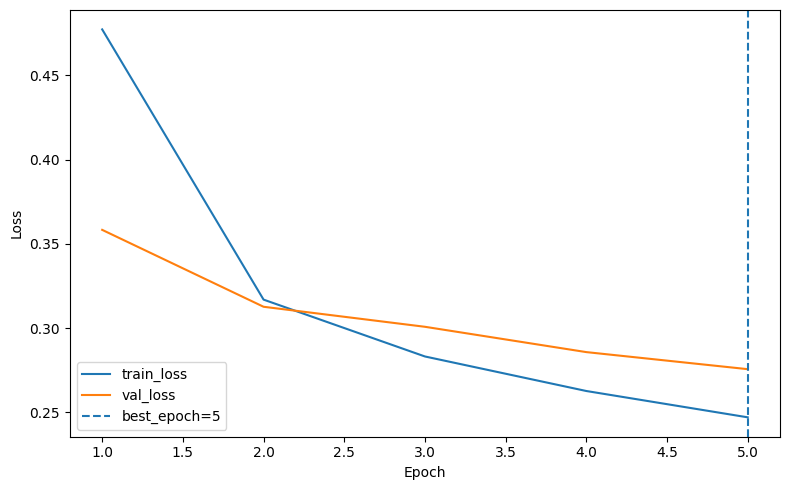

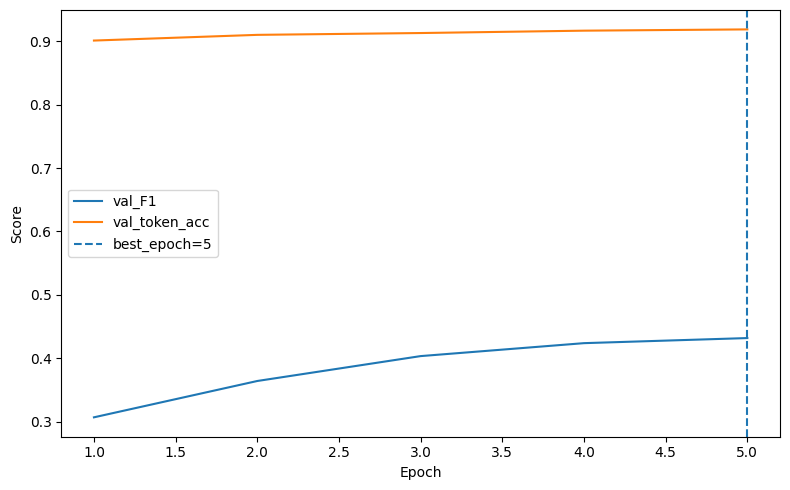

In [52]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmax(history["val_f1"])) + 1

# --- Loss curves ---
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# --- Validation metrics ---
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_f1"], label="val_F1")
plt.plot(epochs, history["val_token_acc"], label="val_token_acc")
plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


## Inspect Token-Level Predictions (TODO)
Numbers (F1/precision/recall) tell us *how good* a model is overall, but not *how it fails*. Here we inspect a few sequences by hand to see typical error patterns (boundary mistakes, type confusions, and “O”-dominance effects) before moving on to more complex architectures.


In [53]:
@torch.no_grad()
def predict_batch(model, batch):
    model.eval()

    input_ids = batch["input_ids"].to(device)
    lengths = batch["lengths"].to(device)
    labels = batch["labels"].to(device)
    tokens = batch.get("tokens", None)

    logits = model(input_ids, lengths)
    preds = logits.argmax(dim=-1)

    results = []

    B, T = labels.shape
    for i in range(B):
        seq = []
        for j in range(T):
            if labels[i, j].item() == cfg.ignore_index:
                break

            tok = tokens[i][j] if tokens is not None else str(input_ids[i, j].item())
            gold = label_names[labels[i, j].item()]
            pred = label_names[preds[i, j].item()]
            seq.append((tok, gold, pred))
        results.append(seq)

    return results


def pretty_print_ner(seqs, max_seqs=3, max_tokens=50):
    for i, seq in enumerate(seqs[:max_seqs]):
        print(f"\n--- Sequence {i+1} ---")
        print(f"{'TOKEN':20s} {'GOLD':15s} {'PRED':15s} {'OK?'}")
        print("-" * 60)

        for tok, gold, pred in seq[:max_tokens]:
            ok = "✓" if gold == pred else "✗"
            print(f"{tok:20s} {gold:15s} {pred:15s} {ok}")


batch = next(iter(valid_loader))
seqs = predict_batch(model, batch)
pretty_print_ner(seqs)



--- Sequence 1 ---
TOKEN                GOLD            PRED            OK?
------------------------------------------------------------
A                    O               O               ✓
Russian              B-NORP          B-PERSON        ✗
diver                O               I-PERSON        ✗
has                  O               O               ✓
found                O               O               ✓
the                  O               O               ✓
bodies               O               O               ✓
of                   O               O               ✓
three                B-CARDINAL      B-CARDINAL      ✓
of                   O               O               ✓
the                  O               O               ✓
118                  B-CARDINAL      B-NORP          ✗
sailors              O               O               ✓
who                  O               O               ✓
were                 O               O               ✓
killed               O               

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


## Test-Set Evaluation
Here we run a single final evaluation on the held-out test split and report loss, token accuracy, and entity-level precision/recall/F1. This is the number we will compare against later parts (under similar training and evaluation conditions).

In [54]:
# Final evaluation on the held-out test set
test_metrics = evaluate(model, test_loader)

print(
    f"TEST | loss={test_metrics['loss']:.4f} | "
    f"token_acc={test_metrics['token_acc']:.4f} | "
    f"P={test_metrics['precision']:.4f} | "
    f"R={test_metrics['recall']:.4f} | "
    f"F1={test_metrics['f1']:.4f}"
)

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


TEST | loss=0.2691 | token_acc=0.9211 | P=0.4440 | R=0.4421 | F1=0.4430


## Concept Checks (answer in Markdown, no code)

### Q1 — Why BiLSTM for NER?
What does bidirectionality buy us in NER specifically?  
Explain what information the forward LSTM and backward LSTM each contribute.

Bidirectionality allows the model to use both past and future context when labeling each token. The forward LSTM captures information from earlier words in the sentence, which helps understand how entities begin or relate to previous tokens. The backward LSTM captures information from later words, which helps confirm entity boundaries and types using upcoming context. Together, they provide richer contextual understanding, which is important because entity meaning often depends on surrounding words.

### Q2 — Padding and “ignore_index”
Why must we ignore padded positions when computing the loss?  
What would go wrong (in optimization and metrics) if we treated padding like a real label?

We ignore padded positions because padding does not represent real tokens and should not influence training. If padding were treated like real labels, the model would learn patterns from artificial data and try to predict padding correctly, which would distort optimization. It would also inflate evaluation metrics since the model could achieve high accuracy by correctly predicting padded tokens rather than meaningful labels.

### Q3 — Token accuracy vs. entity F1
We will print both token accuracy and entity-level F1.  
Give one concrete reason token accuracy can look “good” even when the model is poor at entities.

Token accuracy can appear high because most tokens in NER datasets are labeled “O” (not part of any entity). A model that predicts “O” frequently can achieve strong token accuracy while still failing to correctly identify complete entity spans or entity types. Entity-level F1 is stricter because it requires predicting the full entity correctly, including both boundaries and label type.

# Part 2 — Add Self-Attention on Top of the BiLSTM

In Part 1, we used a strong sequential baseline (BiLSTM) that naturally encodes left-to-right and right-to-left context.  
In this part, we keep that **sequence-aware backbone**, but we add a **single self-attention block** on top of the BiLSTM outputs.

The point of this design is very specific:

- The **BiLSTM** already injects order and local sequential structure.
- The **self-attention layer** then provides a direct mechanism for **global token-to-token mixing**.
- Because we did *not* remove the BiLSTM, we can test whether attention helps *beyond* what a strong sequential encoder already learns.

Conceptually, we compute queries, keys, and values from the BiLSTM features $X$, then build attention weights and mix values:

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

$$
A = \operatorname{softmax}\!\left(\frac{QK^{\mathsf T}}{\sqrt{d}} + M\right)
$$

$$
\text{out} = AV
$$

where $M$ is a masking term that prevents padding tokens from being attended to.

At the end, we still do token classification as before, and we evaluate with the **same exact metrics** (token accuracy + entity-level precision/recall/F1).  
That consistency makes Part 2 a clean ablation against Part 1.

### What we should pay attention to in this part

- **Does attention improve entity-level F1** compared to the BiLSTM baseline?
- **Does it help more for certain entity types** (longer spans, rarer types, or boundary-sensitive cases)?
- **How sensitive is it to masking and dropout**, since attention can exploit artifacts if masking is wrong?
- **What do the attention maps look like**, and do they show patterns that are at least plausibly meaningful?

## Single-Head Self-Attention (Core Mechanism)

In this cell, we implement **single-head self-attention**: each token computes a weighted mixture of all other tokens using the $QK^\top$ similarity matrix.  
The key detail is **padding-aware masking**: padded tokens must not be attended to, or the model will learn misleading interactions.

In [55]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        # x: [B, T, D]
        B, T, D = x.shape

        Q = self.Wq(x)  # [B, T, D]
        K = self.Wk(x)  # [B, T, D]
        V = self.Wv(x)  # [B, T, D]

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (D ** 0.5)  # [B, T, T]

        if attention_mask is not None:
            # attention_mask: [B, T] with 1=real, 0=pad
            key_mask = attention_mask.unsqueeze(1)  # [B, 1, T]
            scores = scores.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)  # [B, T, T]
        attn = self.dropout(attn)

        y = torch.matmul(attn, V)  # [B, T, D]
        y = self.Wo(y)             # [B, T, D]

        if return_attn:
            return y, attn
        return y


## Single-Head Transformer Block (Residual + LayerNorm + FFN)

We now wrap single-head self-attention into a **Transformer-style block** by adding:  
1) a residual path + normalization around attention, and  
2) a position-wise **feed-forward network (FFN)** with another residual + normalization.

This gives us the smallest “Transformer brick” we can plug into an NER model without introducing multi-head attention yet.

In [56]:
class SingleHeadTransformerBlock(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.2, ff_mult: int = 4):
        super().__init__()
        self.attn = SingleHeadSelfAttention(d_model=d_model, dropout=dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model),
        )

    def forward(self, x, attention_mask=None, return_attn=False):
        # Post-LN pattern:
        # 1) Attention sublayer
        if return_attn:
            attn_out, attn_w = self.attn(x, attention_mask=attention_mask, return_attn=True)
        else:
            attn_out = self.attn(x, attention_mask=attention_mask, return_attn=False)
            attn_w = None

        x = self.ln1(x + self.drop(attn_out))

        # 2) FFN sublayer
        ffn_out = self.ffn(x)
        x = self.ln2(x + self.drop(ffn_out))

        if return_attn:
            return x, attn_w
        return x


## Hybrid Tagger: BiLSTM Encoder + Single-Head Attention Block

In this section, we combine a **sequence-aware BiLSTM** (strong classical baseline) with a **single-head Transformer block** on top.

The goal is to isolate one idea:  
**What changes when we add a global mixing mechanism (self-attention) after a sequential encoder?**

We will keep the training/evaluation protocol consistent with Part 1, so any gains or failures can be attributed to this architectural change—not to changes in the experiment setup.

In [57]:
class BiLSTMTransformerTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        emb_dim: int = 128,
        lstm_hidden: int = 192,
        d_model: int = 192,
        lstm_layers: int = 1,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.emb_drop = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.proj = nn.Linear(2 * lstm_hidden, d_model)
        self.proj_drop = nn.Dropout(dropout)

        self.block = SingleHeadTransformerBlock(d_model=d_model, dropout=dropout)
        self.out_drop = nn.Dropout(dropout)

        self.classifier = nn.Linear(d_model, num_labels)

    def forward(self, input_ids, lengths, attention_mask=None, return_attn=False):
        x = self.embedding(input_ids)
        x = self.emb_drop(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        x, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=input_ids.size(1)
        )

        x = self.proj(x)
        x = self.proj_drop(x)

        if return_attn:
            x, attn = self.block(x, attention_mask=attention_mask, return_attn=True)
        else:
            x = self.block(x, attention_mask=attention_mask, return_attn=False)
            attn = None

        x = self.out_drop(x)
        logits = self.classifier(x)

        if return_attn:
            return logits, attn
        return logits


## Loss on Real Tokens Only (Mask-Aware)

In token classification, sequences are padded to a common length.  
Here we define the loss so that **padding does not contribute** (using `ignore_index`) and we can report loss **normalized by the number of real tokens**.

In [58]:
def loss_sum_and_tokens(logits: torch.Tensor, labels: torch.Tensor):
    """
    logits: [B, T, C], labels: [B, T]
    returns: (loss_sum over real tokens, num_real_tokens)
    """
    B, T, C = logits.shape
    loss_sum = F.cross_entropy(
        logits.view(B * T, C),
        labels.view(B * T),
        ignore_index=cfg.ignore_index,
        reduction="sum",
    )
    n_tokens = (labels != cfg.ignore_index).sum().item()
    return loss_sum, n_tokens


def loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
    return loss_sum / max(n_tokens, 1)

## Training & Evaluation Loops (Attention-Aware)

With this cell we can practice writing a clean training loop and a fair evaluation loop.  
The key requirement is **mask correctness**: padding must not affect loss or metrics, and attention must respect the `attention_mask`.

In [59]:
def train_one_epoch_attn(model, loader, optimizer, grad_clip: float = 1.0):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, lengths, attention_mask=attention_mask)
        loss = loss_mean(logits, labels)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        loss_sum, n_tokens = loss_sum_and_tokens(logits.detach(), labels)
        total_loss += loss_sum.item()
        total_tokens += n_tokens

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def evaluate_attn(model, loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    token_correct = 0
    token_total = 0

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, lengths, attention_mask=attention_mask)
        preds = logits.argmax(dim=-1)

        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss += loss_sum.item()
        total_tokens += n_tokens

        mask = labels != cfg.ignore_index
        token_correct += ((preds == labels) & mask).sum().item()
        token_total += mask.sum().item()

        y_true, y_pred = ids_to_tags(labels, preds)
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    return {
        "loss": total_loss / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }


## Initialize the Part 2 Model (BiLSTM + Single-Head Attention)

In this cell we define the **Part 2 model instance** and choose its main capacity knobs (embedding size, hidden size, attention dimension, dropout, etc.).  
We keep the **input/output interface** fixed so evaluation stays comparable, but we leave the architectural choices to you.

In [60]:
cfg.num_workers = 0

attn_model = BiLSTMTransformerTagger(
    vocab_size=len(stoi),
    num_labels=len(label_names),
    pad_id=stoi[cfg.pad_token],
    emb_dim=128,
    lstm_hidden=192,
    d_model=192,
    lstm_layers=1,
    dropout=0.4,
).to(device)

print(attn_model)


BiLSTMTransformerTagger(
  (embedding): Embedding(20603, 128, padding_idx=0)
  (emb_drop): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(128, 192, batch_first=True, bidirectional=True)
  (proj): Linear(in_features=384, out_features=192, bias=True)
  (proj_drop): Dropout(p=0.4, inplace=False)
  (block): SingleHeadTransformerBlock(
    (attn): SingleHeadSelfAttention(
      (Wq): Linear(in_features=192, out_features=192, bias=False)
      (Wk): Linear(in_features=192, out_features=192, bias=False)
      (Wv): Linear(in_features=192, out_features=192, bias=False)
      (Wo): Linear(in_features=192, out_features=192, bias=False)
      (dropout): Dropout(p=0.4, inplace=False)
    )
    (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.4, inplace=False)
    (ffn): Sequential(
      (0): Linear(in_features=192, out_features=768, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.4, inplace=Fals

## Train Part 2 and Early-Stop on Validation F1

In this cell we train the **BiLSTM + single-head attention** tagger under a controlled setup.  
We track both optimization signals (loss) and NER signals (entity-level precision/recall/F1), and we **keep the best model** according to validation performance (typically **entity-level F1**).

In [61]:
optimizer = torch.optim.AdamW(attn_model.parameters(), lr=2e-4)

EPOCHS = 8
patience = 2

best_f1 = -1.0
best_state = None
bad_epochs = 0

history_attn = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(attn_model, train_loader, optimizer)
    val_metrics = evaluate_attn(attn_model, valid_loader)

    history_attn["train_loss"].append(train_loss)
    history_attn["val_loss"].append(val_metrics["loss"])
    history_attn["val_token_acc"].append(val_metrics["token_acc"])
    history_attn["val_precision"].append(val_metrics["precision"])
    history_attn["val_recall"].append(val_metrics["recall"])
    history_attn["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_p={val_metrics['precision']:.4f} | "
        f"val_r={val_metrics['recall']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1 + 1e-6:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in attn_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

attn_model.load_state_dict(best_state)
print(f"Best validation F1: {best_f1:.4f}")


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Epoch 01 | train_loss=0.4542 | val_loss=0.3659 | val_token_acc=0.8953 | val_p=0.2908 | val_r=0.3618 | val_f1=0.3225
Epoch 02 | train_loss=0.3481 | val_loss=0.3398 | val_token_acc=0.9009 | val_p=0.3402 | val_r=0.4048 | val_f1=0.3697
Epoch 03 | train_loss=0.3199 | val_loss=0.3187 | val_token_acc=0.9066 | val_p=0.3642 | val_r=0.4301 | val_f1=0.3944
Epoch 04 | train_loss=0.3035 | val_loss=0.2972 | val_token_acc=0.9131 | val_p=0.3990 | val_r=0.4422 | val_f1=0.4195
Epoch 05 | train_loss=0.2915 | val_loss=0.2967 | val_token_acc=0.9122 | val_p=0.3933 | val_r=0.4505 | val_f1=0.4200
Epoch 06 | train_loss=0.2819 | val_loss=0.2871 | val_token_acc=0.9153 | val_p=0.4223 | val_r=0.4711 | val_f1=0.4453
Epoch 07 | train_loss=0.2744 | val_loss=0.2892 | val_token_acc=0.9150 | val_p=0.4246 | val_r=0.4709 | val_f1=0.4465
Epoch 08 | train_loss=0.2673 | val_loss=0.2791 | val_token_acc=0.9175 | val_p=0.4292 | val_r=0.4769 | val_f1=0.4518
Best validation F1: 0.4518


## Visualize Training Curves (Part 2)

We plot how the model evolves over epochs.  
Loss curves help diagnose optimization and overfitting, while **entity-level F1** is the key signal for NER quality (token accuracy is only a secondary diagnostic).

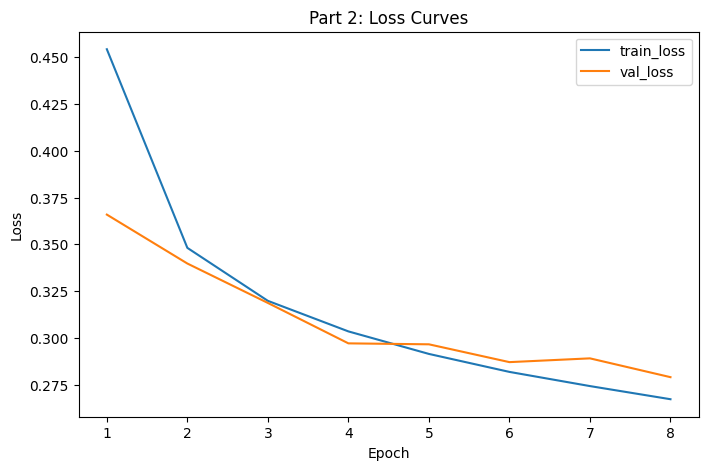

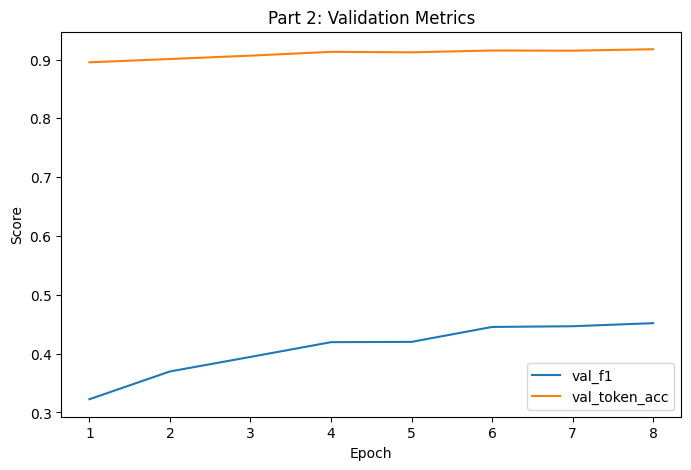

In [62]:
epochs = np.arange(1, len(history_attn["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_attn["train_loss"], label="train_loss")
plt.plot(epochs, history_attn["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 2: Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_attn["val_f1"], label="val_f1")
plt.plot(epochs, history_attn["val_token_acc"], label="val_token_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 2: Validation Metrics")
plt.legend()
plt.show()


## Test Evaluation and Quick Baseline Comparison (Part 2)

We evaluate the attention-augmented model on the **held-out test set** and report the full NER metric suite.  
If Part 1 results are available, we also print a short comparison—primarily focusing on **entity-level F1** to judge whether attention improves span-level predictions.

In [63]:
attn_test = evaluate_attn(attn_model, test_loader)

print(
    f"Part 2 (BiLSTM+Attn) TEST | "
    f"loss={attn_test['loss']:.4f} | "
    f"token_acc={attn_test['token_acc']:.4f} | "
    f"p={attn_test['precision']:.4f} | "
    f"r={attn_test['recall']:.4f} | "
    f"f1={attn_test['f1']:.4f}"
)

if "test_metrics" in globals():
    print(f"Part 1 (BiLSTM) TEST F1: {test_metrics['f1']:.4f}")
    print(f"Part 2 (BiLSTM+Attn) TEST F1: {attn_test['f1']:.4f}")
    print(f"ΔF1 (Part2 - Part1): {(attn_test['f1'] - test_metrics['f1']):.4f}")


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Part 2 (BiLSTM+Attn) TEST | loss=0.2716 | token_acc=0.9203 | p=0.4500 | r=0.4823 | f1=0.4656
Part 1 (BiLSTM) TEST F1: 0.4430
Part 2 (BiLSTM+Attn) TEST F1: 0.4656
ΔF1 (Part2 - Part1): 0.0225


## Attention Map Visualization on a Single Sentence (Part 2)

We take one validation sentence, run the attention-augmented model in a mode that returns **attention weights**, and visualize the resulting **token-to-token attention matrix**.  
This helps us inspect (qualitatively) which tokens attend to which others—while remembering that attention is not a guaranteed explanation, just a useful signal to explore.

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


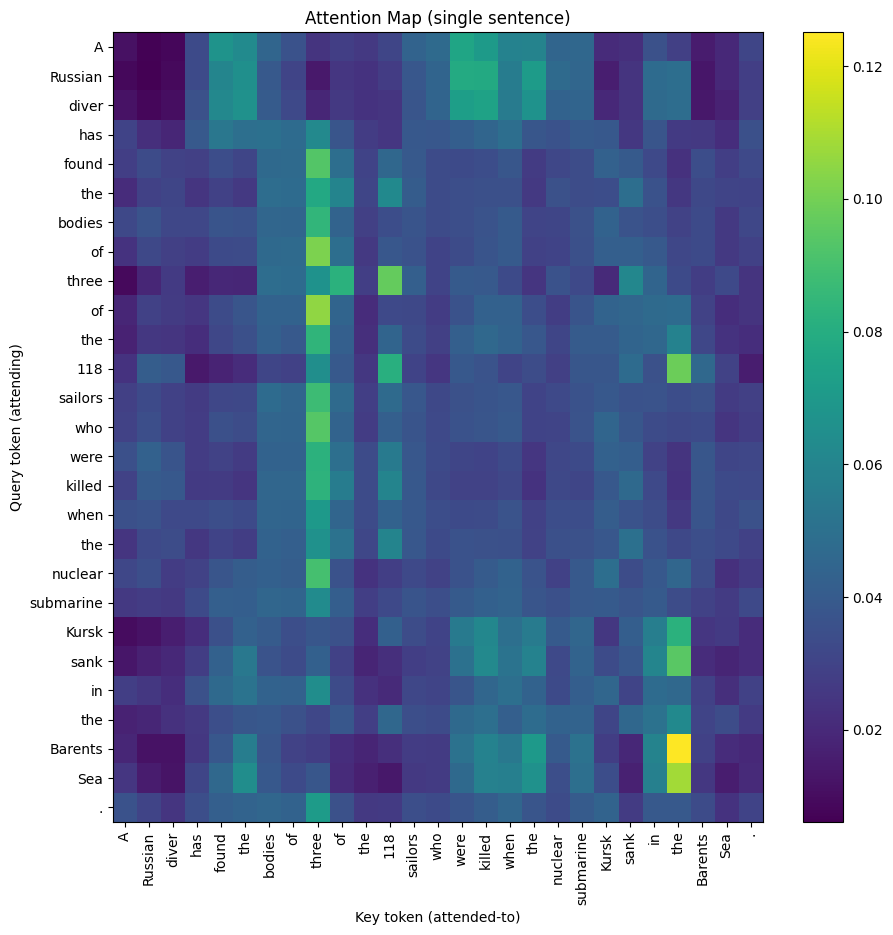

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# take one validation batch
batch = next(iter(valid_loader))

input_ids = batch["input_ids"].to(device)
lengths = batch["lengths"].to(device)
attention_mask = batch["attention_mask"].to(device)
tokens_batch = batch["tokens"]  # list of token lists (from your collate_fn)

# pick one sentence in the batch
i = 0
L = int(lengths[i].item())
tokens = tokens_batch[i][:L]

# run model and get attention
attn_model.eval()
with torch.no_grad():
    logits, attn = attn_model(input_ids, lengths, attention_mask=attention_mask, return_attn=True)

# attn: [B, T, T] -> select sentence i and crop to real length
A = attn[i, :L, :L].detach().cpu().numpy()

# plot attention heatmap
plt.figure(figsize=(max(6, 0.35 * L), max(6, 0.35 * L)))
plt.imshow(A, aspect="auto")
plt.title("Attention Map (single sentence)")
plt.xlabel("Key token (attended-to)")
plt.ylabel("Query token (attending)")
plt.xticks(np.arange(L), tokens, rotation=90)
plt.yticks(np.arange(L), tokens)
plt.colorbar()
plt.tight_layout()
plt.show()


## Concept Checks (answer in Markdown, no code)

1. **Why is “BiLSTM + attention” a cleaner experiment than “attention-only” at this stage?**  
   What capability does the BiLSTM provide that attention alone does not automatically guarantee?

The BiLSTM already provides strong sequential modeling by encoding left-to-right and right-to-left context. Attention alone does not automatically enforce sequential structure or locality. Using BiLSTM + attention isolates the effect of adding global token interactions on top of an already sequence-aware representation, making the comparison cleaner.

2. In the attention formula, we scale by $\sqrt{d}$.  
   **What numerical issue is this scaling trying to reduce?**  
   (Explain intuitively, not with a proof.)

Without scaling, dot products between high-dimensional vectors can become very large, causing the softmax to produce extremely peaked probabilities. This leads to unstable gradients. Dividing by √d keeps attention scores in a reasonable range and stabilizes training.

3. Self-attention produces a matrix $A \in \mathbb{R}^{T \times T}$ (per example).  
   **What do rows and columns represent in that matrix?**  
   If token $i$ strongly attends to token $j$, what does that mean operationally?

Each row corresponds to a query token 
𝑖
i, and each column corresponds to a key token 
𝑗
j. Entry 
𝐴
𝑖
,
𝑗
A
i,j
	​

 is how much token 
𝑖
i attends to token 
𝑗
j. If token 
𝑖
i strongly attends to token 
𝑗
j, it means token 
𝑖
i's representation will incorporate a large contribution from token 
𝑗
j's value vector.

4. Suppose Part 2 improves token accuracy but barely changes entity-level F1.  
   **Give one realistic reason this could happen in NER.**

Token accuracy is dominated by the “O” class. If attention helps predict non-entity tokens slightly better, accuracy increases, but entity-level F1 may not improve because correctly predicting full entity spans (boundaries and types) is much stricter.

# Part 3 — Attention-Only Tagger (No Positional Encoding)

In this part we intentionally **remove the sequential encoder** (BiLSTM) and try to solve NER using **self-attention only**.  
This is a controlled stress test: attention is excellent at mixing information across tokens, but **order is not “built in”** unless we explicitly provide it.

We keep the experimental setup as consistent as possible (same dataset, same evaluation metrics, same masking rules), and we focus on one central question:

> **What breaks when we remove sequence awareness, and why?**

We will:
- implement an attention-only encoder block (self-attention + feed-forward + layer norm + residuals),
- train it on NER,
- evaluate it with **entity-level precision/recall/F1** (not just token accuracy),
- and run interpretability/diagnostic checks that probe whether the model understands token order.

## Single-Head Self-Attention (Core Module)

In this cell we implement the fundamental attention mechanism used throughout the Transformer family.  
We will compute attention scores, apply optional scaling for stability, correctly mask padded tokens, and return either the transformed sequence or (optionally) the attention weight matrix for visualization.

In [73]:
class SingleHeadSelfAttention(nn.Module):
    """
    Single-head self-attention module.

    Expected behavior:
      - Input:  x             [B, T, D]
      - Mask:   attention_mask [B, T] with 1 for real tokens, 0 for padding
      - Output: y             [B, T, D]
      - Optional: return attention weights attn [B, T, T] if return_attn=True

    Notes:
      - "Masking keys" means padded token positions must NOT be attended to.
      - If use_scaling=True, scale attention scores by sqrt(D) for stability.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, use_scaling: bool = True):
        super().__init__()
        self.d_model = d_model
        self.use_scaling = use_scaling

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False,
    ):
        B, T, D = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = torch.matmul(Q, K.transpose(-2, -1))  # [B, T, T]

        if self.use_scaling:
            scores = scores / (D ** 0.5)

        if attention_mask is not None:
            key_mask = attention_mask.unsqueeze(1)  # [B, 1, T]
            scores = scores.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)  # [B, T, T]
        attn = self.dropout(attn)

        y = torch.matmul(attn, V)  # [B, T, D]
        y = self.out(y)            # [B, T, D]

        if return_attn:
            return y, attn
        return y


## Attention-Only Tagger Skeleton

In this cell we define an **attention-only** NER model: it must map token IDs to per-token label logits while handling padding correctly.  
We keep the design intentionally open-ended so we can later study how “attention without order information” behaves under different reasonable implementations.

In [74]:
class AttentionOnlyTagger(nn.Module):
    """
    Attention-only sequence tagger (no RNN/CNN).

    Required behavior:
      - Inputs:
          input_ids:       [B, T]
          attention_mask:  [B, T] with 1 for real tokens and 0 for padding (may be None)
      - Output:
          logits:          [B, T, num_labels]
      - Optional:
          if return_attn=True, also return attention weights with shape [B, T, T]
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 128,
        dropout: float = 0.2,
        use_scaling: bool = True,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.drop = nn.Dropout(dropout)
        self.attn = SingleHeadSelfAttention(d_model=d_model, dropout=dropout, use_scaling=use_scaling)
        self.ln = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_labels)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False,
    ):
        x = self.embedding(input_ids)      # [B, T, D]
        x = self.drop(x)

        if return_attn:
            y, attn = self.attn(x, attention_mask=attention_mask, return_attn=True)
        else:
            y = self.attn(x, attention_mask=attention_mask, return_attn=False)
            attn = None

        x = self.ln(x + self.drop(y))      # residual + norm
        logits = self.classifier(x)        # [B, T, num_labels]

        if return_attn:
            return logits, attn
        return logits


## Evaluation for Attention-Based Taggers

We define a dedicated evaluation function for attention-based NER models.  
The key requirement is **fairness**: we must compute **exactly the same metrics** as earlier parts (especially entity-level F1) while correctly ignoring padded tokens.

In [75]:
@torch.no_grad()
def evaluate_attn(model, loader):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    token_correct = 0
    token_total = 0

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask=attention_mask)
        preds = logits.argmax(dim=-1)

        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss += loss_sum.item()
        total_tokens += n_tokens

        mask = labels != cfg.ignore_index
        token_correct += (preds[mask] == labels[mask]).sum().item()
        token_total += mask.sum().item()

        y_true, y_pred = ids_to_tags(labels, preds)
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    return {
        "loss": total_loss / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }


## One-Epoch Training Loop for Attention Models

We implement a single-epoch training loop that mirrors earlier parts, but now passes an **attention mask** and enforces **padding-aware loss**.  
We keep the structure minimal so we can later compare different training choices without changing the rest of the notebook.

In [77]:
def train_one_epoch_attn(model, loader, optimizer, grad_clip: float = 1.0):
    model.train()

    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask=attention_mask)
        loss = loss_mean(logits, labels)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        loss_sum, n_tokens = loss_sum_and_tokens(logits.detach(), labels)
        total_loss += loss_sum.item()
        total_tokens += n_tokens

    return total_loss / max(total_tokens, 1)


## Part 3 Setup: Attention-Only Model + Optimizer

We instantiate our **attention-only** NER tagger and choose an optimizer configuration.  
We keep this cell flexible on purpose so we can later study how architecture and optimization choices affect performance.

In [78]:
pad_id = stoi[cfg.pad_token]

# ----- Model -----
attn_model = AttentionOnlyTagger(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=pad_id,
    d_model=128,
    dropout=0.2,
    use_scaling=True,
).to(device)

print(attn_model)

# ----- Optimizer -----
optimizer = torch.optim.AdamW(
    attn_model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)


AttentionOnlyTagger(
  (embedding): Embedding(20603, 128, padding_idx=0)
  (drop): Dropout(p=0.2, inplace=False)
  (attn): SingleHeadSelfAttention(
    (q): Linear(in_features=128, out_features=128, bias=True)
    (k): Linear(in_features=128, out_features=128, bias=True)
    (v): Linear(in_features=128, out_features=128, bias=True)
    (out): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=128, out_features=37, bias=True)
)


## Part 3 Training: Validation-Selected Checkpointing

We train the attention-only model and select checkpoints using **validation entity-level F1**.  
The goal is to keep the training protocol comparable across parts, while still allowing experimentation with stopping rules and optimization details.

In [79]:
EPOCHS = 8
patience = 2

best_f1 = -1.0
best_state = None
bad_epochs = 0

history3 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}


for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(attn_model, train_loader, optimizer)
    val_metrics = evaluate_attn(attn_model, valid_loader)

    history3["train_loss"].append(train_loss)
    history3["val_loss"].append(val_metrics["loss"])
    history3["val_token_acc"].append(val_metrics["token_acc"])
    history3["val_precision"].append(val_metrics["precision"])
    history3["val_recall"].append(val_metrics["recall"])
    history3["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_p={val_metrics['precision']:.4f} | "
        f"val_r={val_metrics['recall']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1 + 1e-6:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in attn_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

attn_model.load_state_dict(best_state)
print("Loaded best model with val_F1 =", best_f1)


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Epoch 01 | train_loss=0.4960 | val_loss=0.4362 | val_token_acc=0.8797 | val_p=0.2225 | val_r=0.1147 | val_f1=0.1514
Epoch 02 | train_loss=0.4222 | val_loss=0.4253 | val_token_acc=0.8798 | val_p=0.2483 | val_r=0.1270 | val_f1=0.1680
Epoch 03 | train_loss=0.3983 | val_loss=0.4255 | val_token_acc=0.8796 | val_p=0.2090 | val_r=0.1619 | val_f1=0.1825
Epoch 04 | train_loss=0.3803 | val_loss=0.4268 | val_token_acc=0.8806 | val_p=0.2174 | val_r=0.1583 | val_f1=0.1832
Epoch 05 | train_loss=0.3666 | val_loss=0.4380 | val_token_acc=0.8759 | val_p=0.1858 | val_r=0.1889 | val_f1=0.1873
Epoch 06 | train_loss=0.3574 | val_loss=0.4406 | val_token_acc=0.8747 | val_p=0.1816 | val_r=0.1945 | val_f1=0.1878
Epoch 07 | train_loss=0.3499 | val_loss=0.4477 | val_token_acc=0.8754 | val_p=0.1881 | val_r=0.2029 | val_f1=0.1952
Epoch 08 | train_loss=0.3440 | val_loss=0.4516 | val_token_acc=0.8748 | val_p=0.1812 | val_r=0.2039 | val_f1=0.1919
Loaded best model with val_F1 = 0.19518344635715526


## Training Curves for Part 3

We visualize optimization and generalization by plotting **loss** (train vs validation) and **validation metrics** (entity-level F1 vs token accuracy) across epochs.

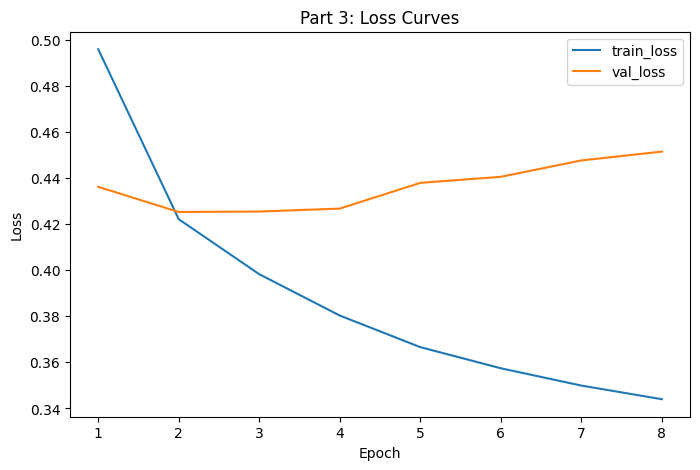

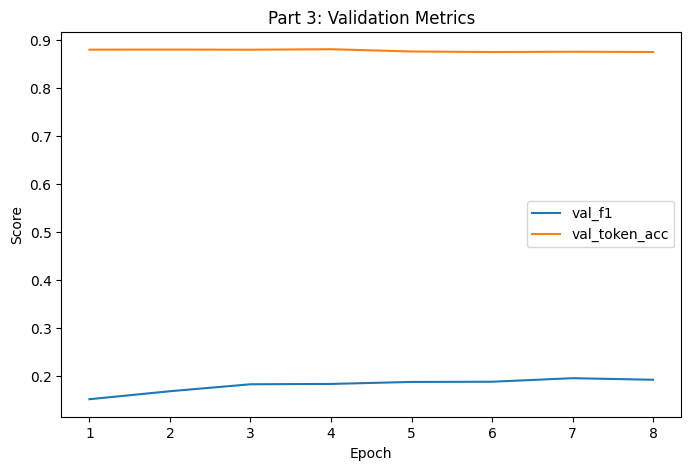

In [80]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history3["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history3["train_loss"], label="train_loss")
plt.plot(epochs, history3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Part 3: Loss Curves")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history3["val_f1"], label="val_f1")
plt.plot(epochs, history3["val_token_acc"], label="val_token_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Part 3: Validation Metrics")
plt.show()


## Final Evaluation on the Test Set (Part 3)

We run a **held-out test evaluation** using the same masked loss and NER span-level metrics as before, so we can compare Part 3 fairly against earlier architectures.


In [84]:
test3 = evaluate_attn(attn_model, test_loader)

print(
    f"Part 3 TEST | "
    f"loss={test3['loss']:.4f} | "
    f"token_acc={test3['token_acc']:.4f} | "
    f"precision={test3['precision']:.4f} | "
    f"recall={test3['recall']:.4f} | "
    f"f1={test3['f1']:.4f}"
)


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Part 3 TEST | loss=0.4411 | token_acc=0.8775 | precision=0.1940 | recall=0.2019 | f1=0.1979


## Attention Map Visualization (No Positional Encoding)

We visualize a **single-head self-attention heatmap** on a real validation sentence to qualitatively inspect what information the model is using when it has **no explicit positional encoding**.

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


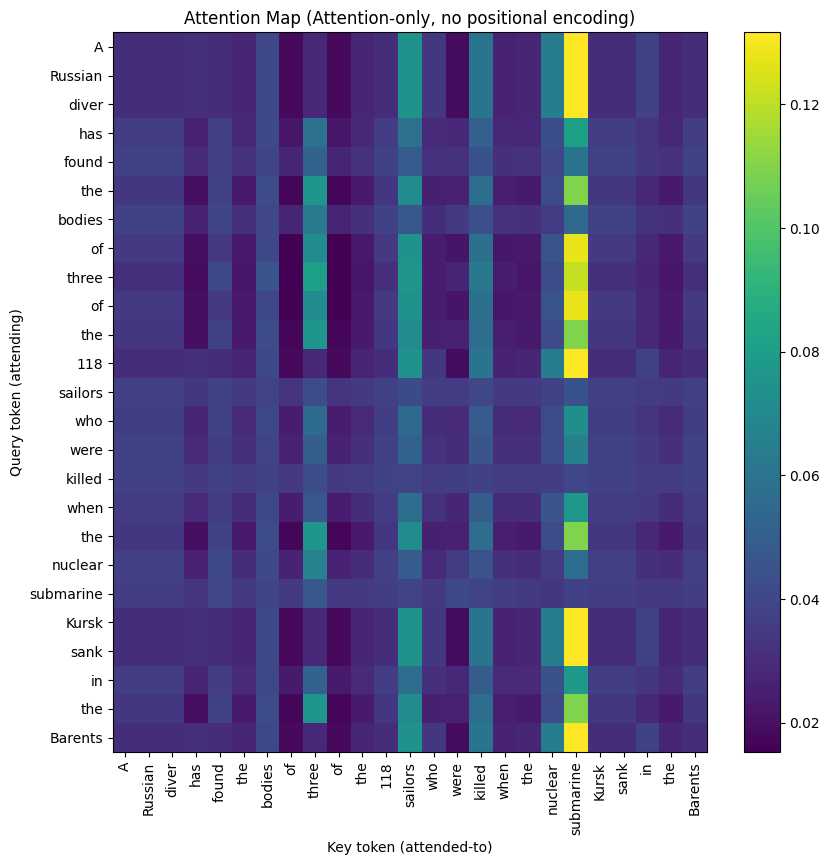

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import torch

max_tokens = 25

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
tokens_batch = batch["tokens"]

i = 0
L = int(attention_mask[i].sum().item())
L = min(L, max_tokens)
tokens = tokens_batch[i][:L]

attn_model.eval()
with torch.no_grad():
    logits, attn = attn_model(input_ids, attention_mask=attention_mask, return_attn=True)

A = attn[i, :L, :L].detach().cpu().numpy()

plt.figure(figsize=(max(6, 0.35 * L), max(6, 0.35 * L)))
plt.imshow(A, aspect="auto")
plt.title("Attention Map (Attention-only, no positional encoding)")
plt.xlabel("Key token (attended-to)")
plt.ylabel("Query token (attending)")
plt.xticks(np.arange(L), tokens, rotation=90)
plt.yticks(np.arange(L), tokens)
plt.colorbar()
plt.tight_layout()
plt.show()


## Permutation Sanity Check (Order Sensitivity)

We run a small diagnostic where we **shuffle token order** in a short window and compare the model’s behavior before vs. after shuffling. The purpose is to test whether, **without positional encoding**, the model can reliably represent *order-dependent* structure in NER.

In [93]:
import numpy as np
import torch

L = 15  # keep small/readable

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
tokens_batch = batch["tokens"]

i = 0
true_len = int(attention_mask[i].sum().item())
L = min(L, true_len)

orig_tokens = tokens_batch[i][:L]

attn_model.eval()
with torch.no_grad():
    orig_logits, orig_attn = attn_model(input_ids, attention_mask=attention_mask, return_attn=True)

orig_preds = orig_logits.argmax(dim=-1)[i, :L].detach().cpu().numpy()
orig_pred_tags = [label_names[p] for p in orig_preds]

perm = np.random.permutation(L)
perm_tokens = [orig_tokens[j] for j in perm]

perm_input_ids = input_ids.clone()
perm_input_ids[i, :L] = input_ids[i, perm]

perm_attention_mask = attention_mask.clone()
perm_attention_mask[i, :L] = attention_mask[i, perm]

with torch.no_grad():
    perm_logits, perm_attn = attn_model(perm_input_ids, attention_mask=perm_attention_mask, return_attn=True)

perm_preds = perm_logits.argmax(dim=-1)[i, :L].detach().cpu().numpy()
perm_pred_tags = [label_names[p] for p in perm_preds]

print("Permutation indices:", perm.tolist())
print("Original tokens:     ", orig_tokens)
print("Permuted tokens:     ", perm_tokens)
print()
print("Original pred tags:  ", orig_pred_tags)
print("Permuted pred tags:  ", perm_pred_tags)

orig_attn_L = orig_attn[i, :L, :L].detach().cpu().numpy()
perm_attn_L = perm_attn[i, :L, :L].detach().cpu().numpy()

inv_perm = np.argsort(perm)
perm_attn_reindexed = perm_attn_L[inv_perm][:, inv_perm]

diff_raw = np.mean(np.abs(orig_attn_L - perm_attn_L))
diff_reindexed = np.mean(np.abs(orig_attn_L - perm_attn_reindexed))

print()
print(f"Mean |attn(orig) - attn(perm)| (raw order): {diff_raw:.6f}")
print(f"Mean |attn(orig) - attn(perm reindexed)|:   {diff_reindexed:.6f}")


Permutation indices: [3, 11, 2, 12, 7, 10, 14, 9, 1, 13, 5, 0, 4, 6, 8]
Original tokens:      ['A', 'Russian', 'diver', 'has', 'found', 'the', 'bodies', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were']
Permuted tokens:      ['has', '118', 'diver', 'sailors', 'of', 'the', 'were', 'of', 'Russian', 'who', 'the', 'A', 'found', 'bodies', 'three']

Original pred tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CARDINAL', 'O', 'O', 'O', 'O', 'O', 'O']
Permuted pred tags:   ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CARDINAL']

Mean |attn(orig) - attn(perm)| (raw order): 0.012643
Mean |attn(orig) - attn(perm reindexed)|:   0.000000


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


## Concept Checks (answer in Markdown, no code)

1. **Why is this an important ablation?**  
   What specific capability do we lose by removing BiLSTM-style recurrence?

Removing the BiLSTM removes an explicit mechanism for modeling sequential order and directional context. A BiLSTM processes tokens left-to-right and right-to-left, which naturally captures word order and local dependencies. Without it, the model loses a strong inductive bias for sequence structure and must rely only on token similarity.

2. **Self-attention mixes tokens — so why might order still be missing?**  
   In plain language, explain why “mixing” is not the same as “knowing positions.”

Self-attention can combine information from all tokens, but without positional encoding it does not know where tokens occur in the sentence. It can see which tokens are present, but not their relative order, so it may treat shuffled sentences as similar.

3. **Interpretation caution:**  
   If we visualize a single-head attention map, why is it risky to conclude that the model “understands” syntax or entities from the heatmap alone?

Attention heatmaps show where the model focuses, not necessarily why it makes decisions. High attention between tokens does not guarantee the model understands syntax or entity structure, since predictions depend on multiple layers and interactions beyond the visible attention weights.

# Part 4 — Adding Positional Encoding (Fixing the Order Blindness)

In Part 3 we intentionally built an **attention-only** tagger *without* any explicit notion of token position.  
That setup is useful because it exposes a core limitation: **self-attention can mix information globally, but it does not inherently know token order** unless we give it some positional signal.

In this part we make **one minimal, controlled change**:

- We keep the attention-only architecture the same.
- We add **sinusoidal positional encoding** to the token embeddings before attention.

Everything else (data, masking, loss, optimizer style, evaluation metrics) should remain as consistent as possible so that we can interpret changes in performance as “the effect of position”.

By the end of Part 4, we should be able to answer a simple experimental question:

> Does injecting positional information recover performance and make attention behave more “structure-aware” on an order-sensitive task like NER?

## What we should pay attention to in this part

- **Fair comparison:** We should not change multiple knobs at once.  
- **Evaluation:** We still care most about **entity-level F1**, not token accuracy.
- **Interpretability (with caution):** Attention maps may look different with positional encoding, but we should treat them as *signals*, not proofs.

## Sinusoidal Positional Encoding

We add a **fixed sinusoidal positional signal** to token embeddings so the attention-only model can represent **token order**.  
In this cell, we implement a reusable module that precomputes a position table and adds the correct prefix for a given sequence length.

In [94]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        # Create position indices [max_len, 1]
        position = torch.arange(max_len).unsqueeze(1)  # [max_len, 1]

        # Create dimension indices [d_model]
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )  # [d_model/2]

        # Create positional encoding table
        pe = torch.zeros(max_len, d_model)

        # Even dimensions → sine
        pe[:, 0::2] = torch.sin(position * div_term)

        # Odd dimensions → cosine
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension → [1, max_len, d_model]
        pe = pe.unsqueeze(0)

        # Register buffer (moves with model but not trainable)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor):
        """
        x: [B, T, d_model]
        """
        T = x.size(1)

        # Add positional encoding slice
        return x + self.pe[:, :T]


## Attention-Only Tagger + Positional Encoding (Part 4)

We repeat the Part 3 attention-only tagger, but we inject **sinusoidal positional information** into the embeddings so the model can represent **token order**.  
This is an ablation-style step: we keep everything else as comparable as possible and test whether adding position restores NER performance.

In [95]:
class AttentionOnlyTaggerWithPE(nn.Module):
    """
    Same as Part 3 AttentionOnlyTagger, but adds sinusoidal positional encoding to embeddings.
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 128,
        dropout: float = 0.2,
        max_len: int = 512,
        use_scaling: bool = True,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)

        self.drop = nn.Dropout(dropout)

        self.attn = SingleHeadSelfAttention(d_model=d_model, dropout=dropout, use_scaling=use_scaling)
        self.ln1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.ln2 = nn.LayerNorm(d_model)

        self.classifier = nn.Linear(d_model, num_labels)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn: bool = False
    ):
        x = self.embedding(input_ids)          # [B, T, D]
        x = self.pos_enc(x)                   # add positional encoding
        x = self.drop(x)

        if return_attn:
            y, attn = self.attn(x, attention_mask=attention_mask, return_attn=True)
        else:
            y = self.attn(x, attention_mask=attention_mask, return_attn=False)
            attn = None

        x = self.ln1(x + self.drop(y))        # residual + norm

        f = self.ffn(x)
        x = self.ln2(x + self.drop(f))        # residual + norm

        logits = self.classifier(x)           # [B, T, num_labels]

        if return_attn:
            return logits, attn
        return logits


## Notice: We Reuse the Part 3 Training/Evaluation Code

**Do not re-implement `train_one_epoch_attn(...)` and `evaluate_attn(...)` in Part 4.**

In Part 4, we intentionally keep the **same training loop and the same evaluation harness** from Part 3.  
This is a controlled experiment: the *only* conceptual change we want to test is **adding positional encoding**.

## Initialize the Positional-Encoding Model

We fix the random seed again and instantiate the **attention-only tagger with sinusoidal positional encoding**.  
Keeping the initialization protocol consistent helps us attribute any performance changes to **positional information**, not to randomness or a different setup.

In [96]:
seed_everything(cfg.seed)

pe_model = AttentionOnlyTaggerWithPE(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=stoi[cfg.pad_token],
    d_model=128,      # keep consistent with Part 3 unless we explicitly ablate this
    dropout=0.2,
    max_len=512,
    use_scaling=True,
).to(device)

## Train the PE Model (Early Stopping on Entity F1)

We now train the **attention-only model with sinusoidal positional encoding** under the same evaluation protocol as Part 3.  
Your job is to implement a clean training loop, track the key metrics, and use **early stopping based on validation entity-level F1** so the comparison stays fair and meaningful.

In [97]:
# Optimizer and training configuration (you may tune these, but keep Part 3 vs Part 4 comparisons fair)
optimizer = torch.optim.AdamW(pe_model.parameters(), lr=5e-4, weight_decay=0.01)

EPOCHS = 7
patience = 2  # early stopping patience (based on validation entity-level F1)

# Track the best checkpoint (by validation F1)
best_f1_pe = -1.0
best_state_pe = None
bad_epochs = 0

# Keep a lightweight training history for plotting/diagnostics
history4 = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_f1": []}

# TODO:
# Train the positional-encoding model for up to `EPOCHS` epochs.
#
# Requirements:
# 1) Each epoch should:
#    - run one full training epoch (reuse the helper you used in Part 3)
#    - evaluate on the validation split (reuse the helper you used in Part 3)
#    - append metrics to `history4`
#    - print a concise progress line (epoch, train_loss, val_loss, val_token_acc, val_F1)
#
# 2) Early stopping:
#    - monitor validation entity-level F1 (NOT token accuracy)
#    - if F1 improves (with a small tolerance), save the model weights into `best_state_pe`
#    - otherwise increment `bad_epochs`
#    - stop when `bad_epochs >= patience`
#
# 3) After the loop:
#    - load `best_state_pe` back into `pe_model`
#    - print the best validation F1 you achieved
#
# Notes:
# - Keep the comparison fair: avoid changing multiple factors at once (e.g., EPOCHS + model size + optimizer).
# - If you change any training detail, document it briefly in a Markdown cell near the change.

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(pe_model, train_loader, optimizer)
    val_metrics = evaluate_attn(pe_model, valid_loader)

    history4["train_loss"].append(train_loss)
    history4["val_loss"].append(val_metrics["loss"])
    history4["val_token_acc"].append(val_metrics["token_acc"])
    history4["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1_pe + 1e-6:
        best_f1_pe = val_metrics["f1"]
        best_state_pe = {k: v.detach().cpu().clone() for k, v in pe_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

pe_model.load_state_dict(best_state_pe)
print("Best validation F1 you achieved:", best_f1_pe)


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Epoch 01 | train_loss=0.5411 | val_loss=0.4258 | val_token_acc=0.8761 | val_f1=0.2134
Epoch 02 | train_loss=0.4178 | val_loss=0.3807 | val_token_acc=0.8878 | val_f1=0.2646
Epoch 03 | train_loss=0.3848 | val_loss=0.3580 | val_token_acc=0.8948 | val_f1=0.2768
Epoch 04 | train_loss=0.3641 | val_loss=0.3466 | val_token_acc=0.8985 | val_f1=0.2946
Epoch 05 | train_loss=0.3490 | val_loss=0.3485 | val_token_acc=0.8949 | val_f1=0.3199
Epoch 06 | train_loss=0.3376 | val_loss=0.3334 | val_token_acc=0.9012 | val_f1=0.3181
Epoch 07 | train_loss=0.3287 | val_loss=0.3269 | val_token_acc=0.9028 | val_f1=0.3219
Best validation F1 you achieved: 0.3219008437932917


## Test Evaluation (Report Final Metrics)

We report **test-set** loss, token accuracy, and entity-level precision/recall/F1 for the positional-encoding model.  
This is the number we will later compare against Part 3 to see how much **positional information** changes performance.

In [98]:
test_metrics4 = evaluate_attn(pe_model, test_loader)

print(
    f"PART 4 TEST | "
    f"loss={test_metrics4['loss']:.4f} | "
    f"token_acc={test_metrics4['token_acc']:.4f} | "
    f"P={test_metrics4['precision']:.4f} | "
    f"R={test_metrics4['recall']:.4f} | "
    f"F1={test_metrics4['f1']:.4f}"
)

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


PART 4 TEST | loss=0.3251 | token_acc=0.9039 | P=0.3106 | R=0.3479 | F1=0.3282


## Plot Learning Curves (Diagnostics)

We visualize our Part 4 training dynamics to diagnose optimization and generalization:  
loss curves tell us whether training is stable, and score curves (especially entity-level F1) tell us whether improvements translate to better NER performance.

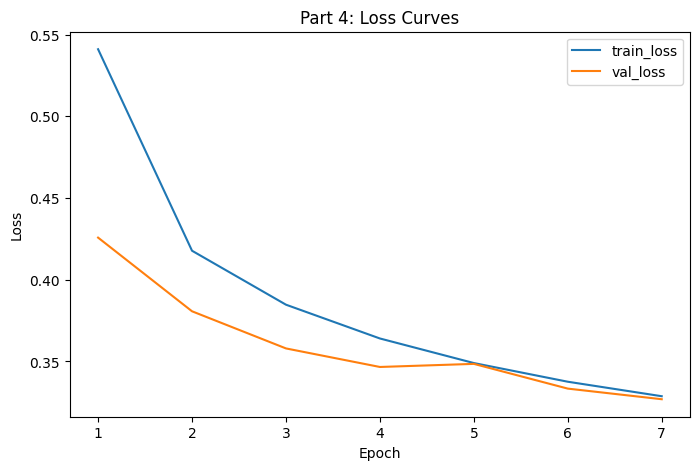

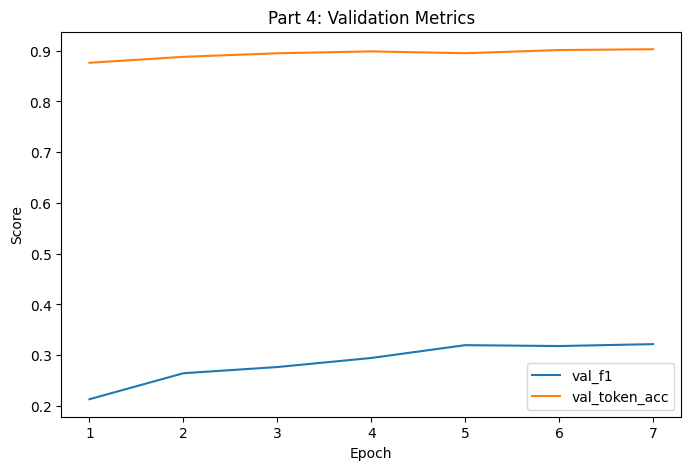

In [99]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history4["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history4["train_loss"], label="train_loss")
plt.plot(epochs, history4["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 4: Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history4["val_f1"], label="val_f1")
plt.plot(epochs, history4["val_token_acc"], label="val_token_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 4: Validation Metrics")
plt.legend()
plt.show()


## Compare With vs Without Positional Encoding

Here we make a *fair* visual comparison between Part 3 (attention-only **without** positional encoding) and Part 4 (the **same** model but **with** positional encoding).  
We compare validation curves (loss and at least one NER score such as entity-level F1) across epochs to see whether adding positional information improves learning dynamics and final tagging quality.


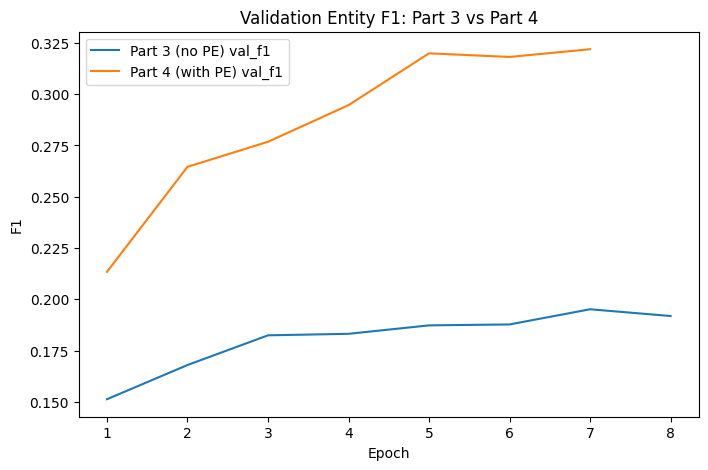

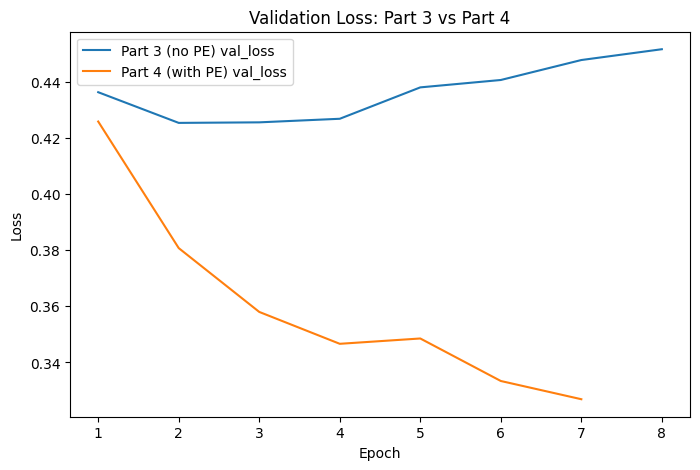

In [100]:
import numpy as np
import matplotlib.pyplot as plt

h_nope = history3
h_pe = history4

e_nope = np.arange(1, len(h_nope["val_f1"]) + 1)
e_pe = np.arange(1, len(h_pe["val_f1"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(e_nope, h_nope["val_f1"], label="Part 3 (no PE) val_f1")
plt.plot(e_pe, h_pe["val_f1"], label="Part 4 (with PE) val_f1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation Entity F1: Part 3 vs Part 4")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(e_nope, h_nope["val_loss"], label="Part 3 (no PE) val_loss")
plt.plot(e_pe, h_pe["val_loss"], label="Part 4 (with PE) val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss: Part 3 vs Part 4")
plt.legend()
plt.show()


## Attention Map Comparison: No PE vs With PE

In this cell we compare *interpretability signals* across two nearly identical models:  
the attention-only tagger **without** positional encoding (Part 3) and the same architecture **with** sinusoidal positional encoding (Part 4).

We visualize a single sentence’s attention matrix from each model (cropped to real token length) and compare patterns qualitatively.  
The goal is not to “prove” correctness from attention, but to develop intuition about how positional information can reshape attention structure.

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


attn_nope shape: (32, 59, 59)
attn_pe shape:   (32, 59, 59)


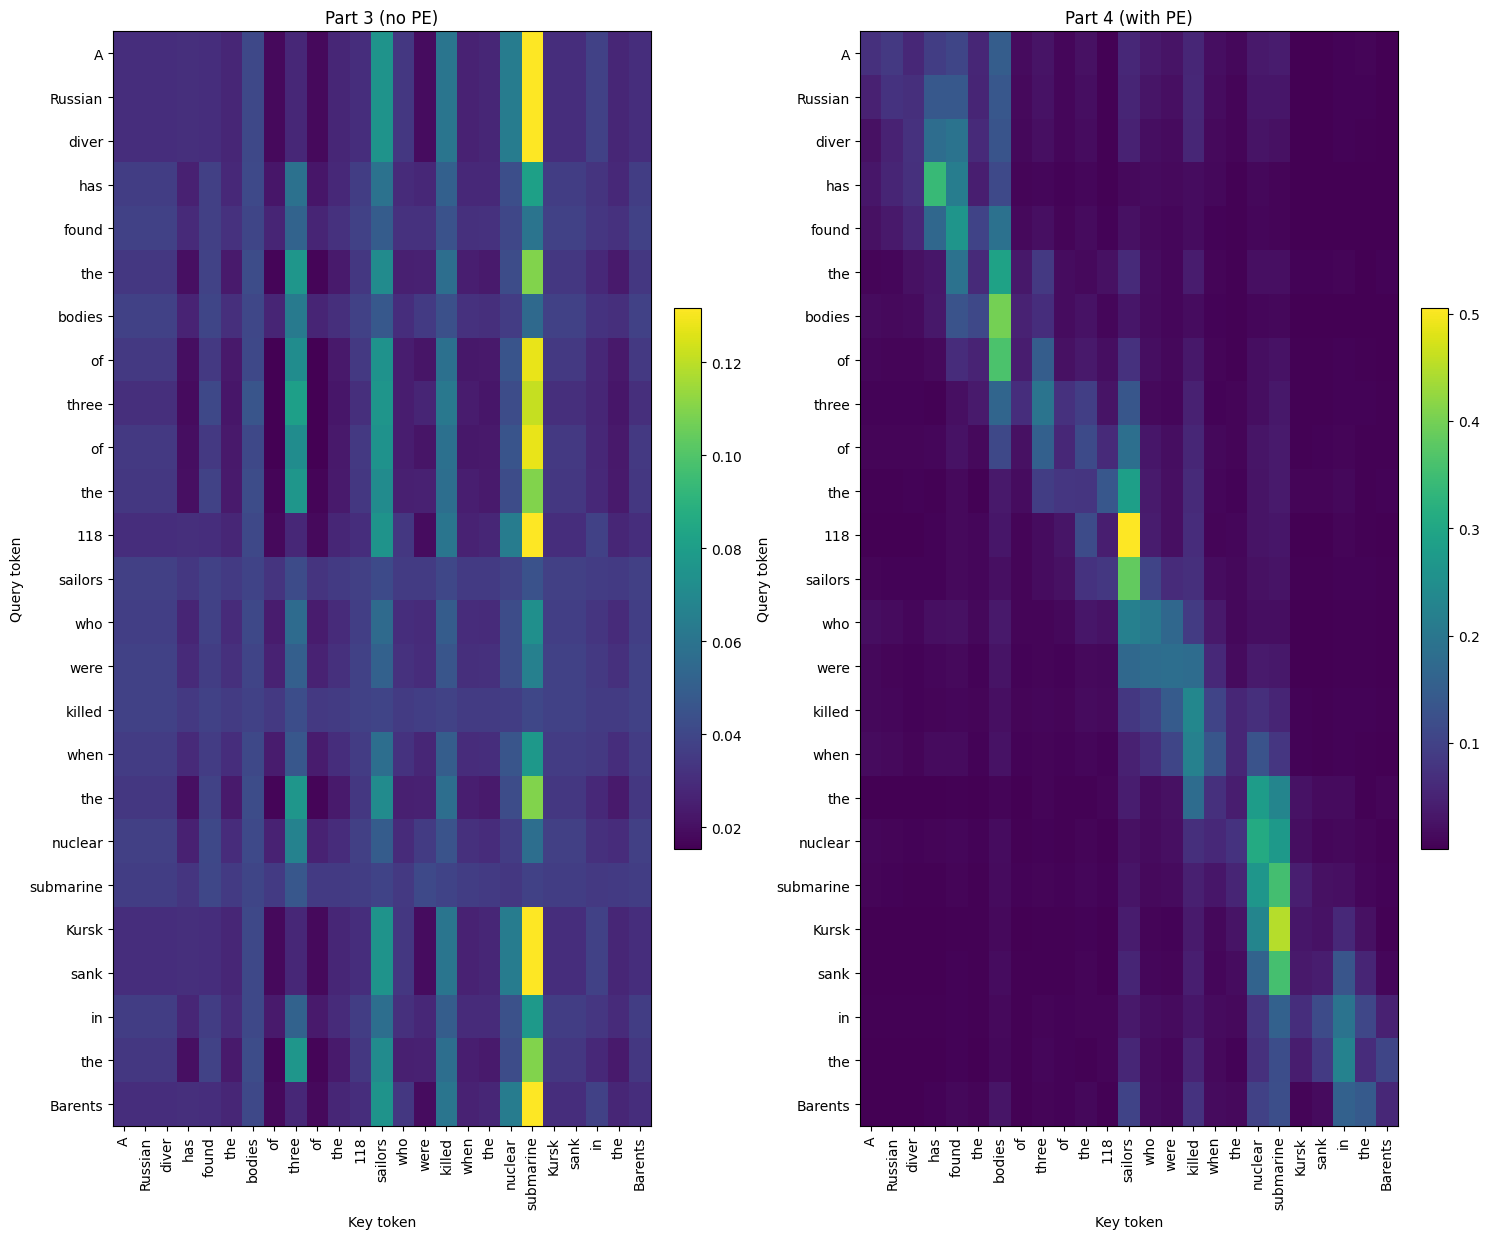

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import torch

max_tokens = 25

nope_model = attn_model          # Part 3 (no positional encoding)
withpe_model = pe_model              # Part 4 (with positional encoding)

batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
tokens_batch = batch["tokens"]

i = 0
L = int(attention_mask[i].sum().item())
L = min(L, max_tokens)
tokens = tokens_batch[i][:L]

nope_model.eval()
withpe_model.eval()

with torch.no_grad():
    _, attn_nope = nope_model(input_ids, attention_mask=attention_mask, return_attn=True)
    _, attn_pe = withpe_model(input_ids, attention_mask=attention_mask, return_attn=True)

print("attn_nope shape:", tuple(attn_nope.shape))
print("attn_pe shape:  ", tuple(attn_pe.shape))

A_nope = attn_nope[i, :L, :L].detach().cpu().numpy()
A_pe = attn_pe[i, :L, :L].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(max(10, 0.6 * L), max(6, 0.5 * L)))

im0 = axes[0].imshow(A_nope, aspect="auto")
axes[0].set_title("Part 3 (no PE)")
axes[0].set_xlabel("Key token")
axes[0].set_ylabel("Query token")
axes[0].set_xticks(np.arange(L))
axes[0].set_xticklabels(tokens, rotation=90)
axes[0].set_yticks(np.arange(L))
axes[0].set_yticklabels(tokens)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(A_pe, aspect="auto")
axes[1].set_title("Part 4 (with PE)")
axes[1].set_xlabel("Key token")
axes[1].set_ylabel("Query token")
axes[1].set_xticks(np.arange(L))
axes[1].set_xticklabels(tokens, rotation=90)
axes[1].set_yticks(np.arange(L))
axes[1].set_yticklabels(tokens)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Concept Checks (answer in Markdown, no code)

### Q1 — Why positional encoding is needed
Self-attention computes attention weights using content-based similarity.  
Why does this make the model *potentially invariant* to token order when we remove any positional signal?

Self-attention uses only content similarity between tokens. Without positional information, the model sees a sentence as an unordered set of tokens, so swapping token order can produce the same attention patterns and outputs. This makes the model largely invariant to word order, even though order is crucial for meaning and NER boundaries.

### Q2 — What sinusoidal positional encoding provides
Sinusoidal positional encoding is a deterministic function of position index.  
What property makes it reasonable for sequence models, and what kinds of information can it inject into embeddings?

Sinusoidal encoding gives each position a unique, continuous representation that the model can use to infer relative and absolute order. Because nearby positions have related encodings and distances can be computed from them, the model can learn sequence structure such as token order, boundaries, and relative distances between words.

### Q3 — Controlled ablation logic
If we keep everything the same except positional encoding, what conclusions are we allowed to draw from:
- a large improvement in entity F1?
- a small/no improvement?
- a drop in performance?

Large improvement in F1: positional information is important for capturing entity boundaries and sequence structure.

Small/no improvement: the model already captures enough order indirectly (e.g., from context or data patterns), or order is less critical.

Drop in performance: the added positional signal may introduce noise or the model may not be using it effectively, possibly due to insufficient training or capacity.

### Q4 — Attention-map comparison interpretation
When we compare attention maps between Part 3 and Part 4:
- What qualitative patterns would we *expect* to change if positional information is being used?
- Why is it still risky to claim “the model learned X” based purely on attention heatmaps?

Expected qualitative changes with positional encoding:
With positional encoding, attention maps should become more structured and order-aware. We may see stronger focus on nearby tokens, clearer directional patterns (e.g., attending to previous words in an entity), and more consistent attention around entity boundaries. Without positional encoding, attention often looks more symmetric or content-based, ignoring token order.

Why it’s risky to claim “the model learned X” from attention maps:
Attention heatmaps only show where the model focuses, not why or how decisions are made. High attention does not necessarily mean importance for prediction, and useful computations can happen outside visible attention weights. Therefore, attention patterns are suggestive but not definitive proof that the model learned specific linguistic structures.

# Part 5 — Multi-Head Attention

In Parts 3–4 we saw that **self-attention can mix global context**, but it also needs **positional information** to work well on order-sensitive tasks like NER.  
Now we take the next step toward real Transformer encoders: **multi-head self-attention**.

The key idea is simple:

- Instead of learning *one* attention pattern, we learn **multiple attention heads in parallel**.
- Each head can focus on different relationships (local neighborhoods, long-range dependencies, boundary cues, etc.).
- We then **combine** those heads to form a richer representation.

In this part we will:
- implement **multi-head self-attention** (single layer first),
- wrap it into a standard **encoder-layer block** (attention + feed-forward + residuals + layer norm),
- stack multiple layers,
- train and compare against our earlier attention models,
- and finally **inspect attention heads** to build intuition about what different heads might be doing.


## Multi-Head Self-Attention (TODO)

In this cell we implement **multi-head self-attention**: multiple attention heads run in parallel on different learned subspaces, then their outputs are concatenated and projected back to \(d_{\text{model}}\). The key technical requirements are correct **tensor shapes**, correct **scaled dot-product attention**, and correct **padding masking** so pad tokens do not receive attention.

In [105]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        B, T, D = x.shape
        H = self.num_heads
        d_head = self.d_head

        # Project to Q, K, V: [B, T, D]
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Reshape to heads: [B, H, T, d_head]
        Q = Q.view(B, T, H, d_head).transpose(1, 2)
        K = K.view(B, T, H, d_head).transpose(1, 2)
        V = V.view(B, T, H, d_head).transpose(1, 2)

        # Scaled dot-product attention scores: [B, H, T, T]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_head ** 0.5)

        # Mask padded KEYS (columns)
        if attention_mask is not None:
            key_mask = attention_mask[:, None, None, :]  # [B, 1, 1, T]
            scores = scores.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)            # [B, H, T, T]
        attn = self.attn_dropout(attn)

        # Weighted sum: [B, H, T, d_head]
        y = torch.matmul(attn, V)

        # Combine heads back: [B, T, D]
        y = y.transpose(1, 2).contiguous().view(B, T, D)
        y = self.out_proj(y)
        y = self.out_dropout(y)

        if return_attn:
            return y, attn
        return y


## Transformer Encoder Layer (MHA + FFN) (TODO)

In this cell we build a **Transformer encoder layer**: multi-head self-attention followed by a position-wise feed-forward network, each wrapped with **residual connections**, **dropout**, and **layer normalization**. This layer becomes the reusable “brick” we will stack to form deeper Transformer encoders.

In [111]:
class TransformerEncoderLayerMHA(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.2, ff_mult: int = 4):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)

        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model),
        )

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        # Pre-LN attention block
        x_norm = self.ln1(x)
        if return_attn:
            attn_out, attn = self.mha(x_norm, attention_mask=attention_mask, return_attn=True)
        else:
            attn_out = self.mha(x_norm, attention_mask=attention_mask, return_attn=False)
            attn = None

        x = x + self.dropout1(attn_out)

        # Pre-LN FFN block
        x_norm = self.ln2(x)
        ffn_out = self.ffn(x_norm)
        x = x + self.dropout2(ffn_out)

        if return_attn:
            return x, attn
        return x


## Multi-Head Attention-Only Tagger (Stacked Encoder) (TODO)

In this cell we assemble the **Part 5 model**: token embeddings, optional positional encoding, a **stack of Transformer encoder layers with multi-head self-attention**, and a final per-token classifier for NER. We also add a hook to optionally return attention maps from a chosen layer for interpretability experiments later in the section.

In [114]:
class MultiHeadAttentionOnlyTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 512,
        use_positional_encoding: bool = True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.emb_dropout = nn.Dropout(dropout)

        if use_positional_encoding:
            self.pos_enc = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)
        else:
            self.pos_enc = None

        self.layers = nn.ModuleList(
            [
                TransformerEncoderLayerMHA(
                    d_model=d_model,
                    num_heads=num_heads,
                    dropout=dropout,
                    ff_mult=4,
                )
                for _ in range(num_layers)
            ]
        )

        self.out_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.embedding(input_ids)  # [B, T, D]
        x = self.emb_dropout(x)

        if self.pos_enc is not None:
            x = self.pos_enc(x)

        attn_to_return = None

        for i, layer in enumerate(self.layers):
            if return_attn_layer == i:
                x, attn = layer(x, attention_mask=attention_mask, return_attn=True)
                attn_to_return = attn
            else:
                x = layer(x, attention_mask=attention_mask, return_attn=False)

        logits = self.classifier(self.out_dropout(x))  # [B, T, num_labels]

        if return_attn_layer >= 0:
            return logits, attn_to_return
        return logits


## Train the Multi-Head Attention Model (TODO)

In this cell we run the full **training + validation** loop for our multi-head encoder, track **loss and NER metrics**, and apply **early stopping** based on **validation entity-level F1**. At the end, we reload the best checkpoint so evaluation and visualization always reflect the best-performing model from this run.

In [115]:
def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


pad_id = stoi[cfg.pad_token]

mha_model = MultiHeadAttentionOnlyTagger(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=pad_id,
    d_model=192,
    num_heads=4,
    num_layers=2,
    dropout=0.2,
    max_len=512,
    use_positional_encoding=True,
).to(device)

print("Trainable params:", f"{count_params(mha_model):,}")

optimizer = torch.optim.AdamW(mha_model.parameters(), lr=5e-4, weight_decay=0.01)

EPOCHS = 8
patience = 2

best_f1 = -1.0
best_state = None
bad_epochs = 0

history5 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_attn(mha_model, train_loader, optimizer)
    val_metrics = evaluate_attn(mha_model, valid_loader)

    history5["train_loss"].append(train_loss)
    history5["val_loss"].append(val_metrics["loss"])
    history5["val_token_acc"].append(val_metrics["token_acc"])
    history5["val_precision"].append(val_metrics["precision"])
    history5["val_recall"].append(val_metrics["recall"])
    history5["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_p={val_metrics['precision']:.4f} | "
        f"val_r={val_metrics['recall']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1 + 1e-6:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in mha_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

mha_model.load_state_dict(best_state)
print("Loaded best MHA model with val_F1 =", best_f1)


Trainable params: 4,852,645


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Epoch 01 | train_loss=0.4535 | val_loss=0.3837 | val_token_acc=0.8912 | val_p=0.2508 | val_r=0.2736 | val_f1=0.2617
Epoch 02 | train_loss=0.3681 | val_loss=0.3349 | val_token_acc=0.9017 | val_p=0.3105 | val_r=0.3098 | val_f1=0.3101
Epoch 03 | train_loss=0.3384 | val_loss=0.3237 | val_token_acc=0.9048 | val_p=0.3272 | val_r=0.3837 | val_f1=0.3532
Epoch 04 | train_loss=0.3178 | val_loss=0.3139 | val_token_acc=0.9075 | val_p=0.3630 | val_r=0.4037 | val_f1=0.3822
Epoch 05 | train_loss=0.3024 | val_loss=0.3115 | val_token_acc=0.9069 | val_p=0.3672 | val_r=0.4007 | val_f1=0.3832
Epoch 06 | train_loss=0.2898 | val_loss=0.2919 | val_token_acc=0.9134 | val_p=0.3918 | val_r=0.4092 | val_f1=0.4003
Epoch 07 | train_loss=0.2797 | val_loss=0.2883 | val_token_acc=0.9141 | val_p=0.4026 | val_r=0.4499 | val_f1=0.4249
Epoch 08 | train_loss=0.2699 | val_loss=0.2802 | val_token_acc=0.9174 | val_p=0.4281 | val_r=0.4380 | val_f1=0.4330
Loaded best MHA model with val_F1 = 0.43301916290704423


## Plot Curves and Test Evaluation (TODO)

In this cell we visualize the **training dynamics** (loss and validation metrics), then evaluate the best multi-head model on the **test set** using the same NER metric pipeline as earlier parts. Finally, we optionally print side-by-side comparisons against previous baselines to make the ablation story clear.

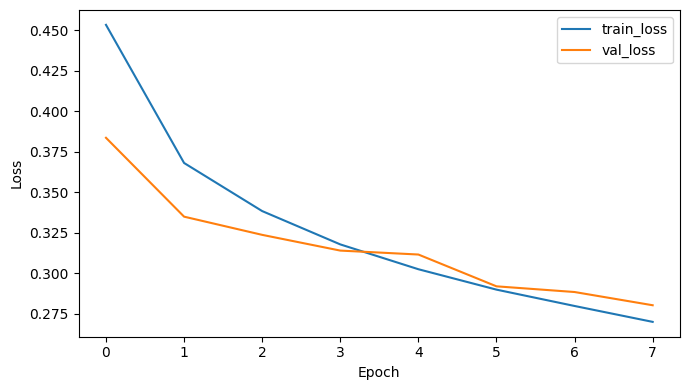

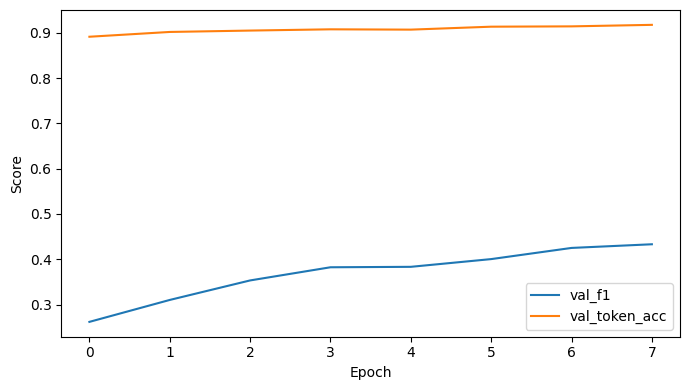

/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


Part 5 TEST | loss=0.2771 | token_acc=0.9197 | precision=0.4432 | recall=0.4419 | f1=0.4425
Compare F1 | Part 3=0.1979 | Part 5=0.4425 | delta=0.2446


In [116]:
import matplotlib.pyplot as plt

history = history5

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_f1"], label="val_f1")
plt.plot(history["val_token_acc"], label="val_token_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

mha_test = evaluate_attn(mha_model, test_loader)
print(
    f"Part 5 TEST | "
    f"loss={mha_test['loss']:.4f} | "
    f"token_acc={mha_test['token_acc']:.4f} | "
    f"precision={mha_test['precision']:.4f} | "
    f"recall={mha_test['recall']:.4f} | "
    f"f1={mha_test['f1']:.4f}"
)

if "test3" in globals():
    print(
        f"Compare F1 | "
        f"Part 3={test3['f1']:.4f} | "
        f"Part 5={mha_test['f1']:.4f} | "
        f"delta={(mha_test['f1'] - test3['f1']):.4f}"
    )

if "pe_test" in globals():
    print(
        f"Compare F1 | "
        f"Part 4={pe_test['f1']:.4f} | "
        f"Part 5={mha_test['f1']:.4f} | "
        f"delta={(mha_test['f1'] - pe_test['f1']):.4f}"
    )


## Multi-Head Attention Maps (Interpretability) — TODO

In this cell we visualize **multi-head self-attention** on a single sentence to see whether different heads appear to specialize (e.g., local context vs. long-range links). We treat the plots as **diagnostics**, not as final explanations: we focus on correct token alignment, masking/cropping padded positions, and careful interpretation.


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


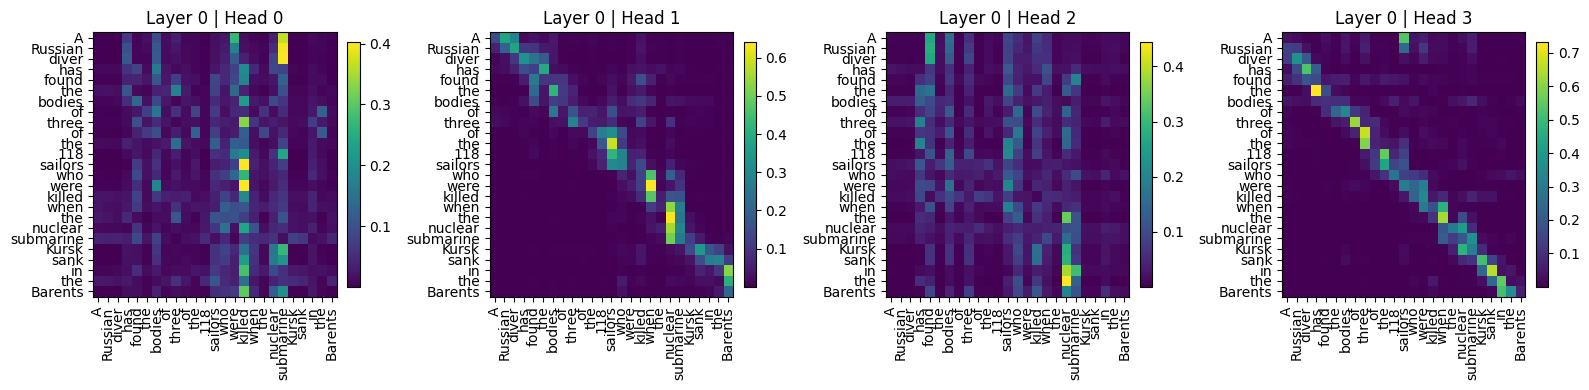

A	B-ORG
Russian	B-PERSON
diver	I-PERSON
has	O
found	O
the	O
bodies	O
of	O
three	B-CARDINAL
of	O
the	O
118	B-NORP
sailors	O
who	O
were	O
killed	O
when	O
the	O
nuclear	O
submarine	O
Kursk	O
sank	I-PERSON
in	O
the	B-GPE
Barents	I-LOC


In [117]:
import torch
import matplotlib.pyplot as plt

mha_model.eval()

# pick one batch + one example
batch = next(iter(valid_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

ex_idx = 0
L = int(attention_mask[ex_idx].sum().item())
max_tokens = 25
L = min(L, max_tokens)

# get attention from one chosen layer (use layer 0 by default)
layer_idx = 0
with torch.no_grad():
    logits, attn = mha_model(input_ids, attention_mask=attention_mask, return_attn_layer=layer_idx)
    preds = logits.argmax(dim=-1)

# tokens for labeling (assumes your collate returns tokens; if not, fall back to ids)
if "tokens" in batch:
    tokens = batch["tokens"][ex_idx][:L]
else:
    tokens = [itos[int(t.item())] for t in input_ids[ex_idx, :L].cpu()]

attn_ex = attn[ex_idx].detach().cpu()  # [H, T, T] (expected)
attn_ex = attn_ex[:, :L, :L]
H = attn_ex.shape[0]

# plot a few heads
heads_to_show = min(H, 4)
fig, axes = plt.subplots(1, heads_to_show, figsize=(4 * heads_to_show, 4))
if heads_to_show == 1:
    axes = [axes]

for i in range(heads_to_show):
    ax = axes[i]
    im = ax.imshow(attn_ex[i], aspect="auto")
    ax.set_title(f"Layer {layer_idx} | Head {i}")
    ax.set_xticks(range(L))
    ax.set_yticks(range(L))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# optional: token + predicted tag view
pred_tags = [label_names[int(p.item())] for p in preds[ex_idx, :L].cpu()]
for t, pt in zip(tokens, pred_tags):
    print(f"{t}\t{pt}")


## Concept Checks (answer in Markdown, no code)

1. In multi-head attention, we typically split the representation into subspaces of size:
   $$
   d_{\mathrm{head}} = \frac{d_{\mathrm{model}}}{H}.
   $$
   What is the intuition behind using smaller per-head dimensions instead of keeping one full-size attention?

Splitting into smaller per-head dimensions lets each head focus on different types of relationships (e.g., local context, long-range dependencies). Multiple small attentions can learn diverse patterns in parallel, giving richer representations than one large attention operating in a single subspace.

2. Multi-head attention increases modeling capacity, but it also changes compute/memory usage.  
   **Which part of attention has the dominant cost in sequence length $T$**, and why?

The dominant cost is computing the attention matrix 
𝑄
𝐾
𝑇
QK
T
, which is 
𝑂
(
𝑇
2
)
O(T
2
). This creates a 
𝑇
×
𝑇
T×T matrix per head, so both compute and memory grow quadratically with sequence length, making it the main bottleneck.

3. When we visualize attention heads, we might see different patterns per head.  
   Give **two plausible reasons** why heads can look different (even within the same layer).

Each head learns different projections of Q/K/V, so it can specialize in different linguistic patterns (e.g., syntax vs. entity boundaries).

Random initialization and training dynamics lead heads to converge to different useful behaviors even within the same layer.

# Part 6 — Going Deeper: A Tiny Transformer Encoder + Depth Ablation

In Parts 4–5, we saw that **positional information** makes attention usable for order-sensitive tagging, and that **multi-head attention** can represent multiple interaction patterns in parallel.

In this part we push one more core “Transformer/BERT idea”:

- instead of *one* encoder layer, we stack **multiple encoder blocks** (attention + feed-forward + residual + layer norm),
- and we treat the notebook like a small empirical study: **how does depth change NER performance?**

We will run a **depth ablation**: train several models that differ only in the **number of encoder layers**, while keeping the rest of the setup as controlled as possible (data, tokenizer/vocab, metric computation, optimization budget, etc.).

### What we should keep fixed (to make the ablation meaningful)

To interpret results correctly, we should try to change **one variable at a time**:

- keep the same dataset splits and evaluation function,
- keep the same embedding size and number of heads,
- keep positional encoding **on** (because Part 4 established it as necessary),
- keep the training recipe comparable (optimizer family, early stopping logic, etc.).

If we decide to change any of these, we should document it briefly (and explain why).

## Encoder Block (BERT-style): Attention + FFN + Residual + LayerNorm

In this cell we implement the **basic building block** of a Transformer encoder.  
The block has two sublayers—**multi-head self-attention** and a **position-wise feedforward network**—each wrapped with a **residual connection** and **LayerNorm**.

**Guiding questions:**
- What must stay shape-preserving so we can stack many layers cleanly?
- Where exactly do we apply masking so padding tokens do not affect attention?

In [123]:
class BertStyleEncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1, ff_mult: int = 4):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)

        self.dropout_attn = nn.Dropout(dropout)
        self.ln_attn = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model),
        )
        self.dropout_ffn = nn.Dropout(dropout)
        self.ln_ffn = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None, return_attn: bool = False):
        if return_attn:
            attn_out, attn = self.mha(x, attention_mask=attention_mask, return_attn=True)
        else:
            attn_out = self.mha(x, attention_mask=attention_mask, return_attn=False)
            attn = None

        x = self.ln_attn(x + self.dropout_attn(attn_out))

        ffn_out = self.ffn(x)
        x = self.ln_ffn(x + self.dropout_ffn(ffn_out))

        if return_attn:
            return x, attn
        return x


## Tiny Transformer Encoder for NER (BERT-style stack)

In this cell we define a **small Transformer encoder** for token classification.  
We stack multiple encoder blocks, optionally add **positional encoding**, and attach a **per-token classifier**.

**Guiding questions:**
- What tensor shapes must remain unchanged so the blocks can be stacked safely?
- Where should positional information be injected, and why *before* the blocks?
- What is the purpose of returning attention from a single selected layer instead of all layers?

In [126]:
class TinyEncoderForNER(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
        use_positional_encoding: bool = True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding

        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.emb_dropout = nn.Dropout(dropout)

        self.pos_enc = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len) if use_positional_encoding else None

        self.layers = nn.ModuleList(
            [BertStyleEncoderBlock(d_model=d_model, num_heads=num_heads, dropout=dropout) for _ in range(num_layers)]
        )

        self.out_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)

        nn.init.xavier_uniform_(self.classifier.weight)
        if self.classifier.bias is not None:
            nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.tok_emb(input_ids) * (self.d_model ** 0.5)
        x = self.emb_dropout(x)

        if self.pos_enc is not None:
            x = self.pos_enc(x)

        attn_out = None
        for i, layer in enumerate(self.layers):
            if i == return_attn_layer:
                x, attn_out = layer(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = layer(x, attention_mask=attention_mask, return_attn=False)

        x = self.out_dropout(x)
        logits = self.classifier(x)

        if return_attn_layer >= 0:
            return logits, attn_out
        return logits


## Depth Ablation Runner (Fair Comparison Across Encoder Depths)

This cell defines a **single reusable training routine** used to compare models of different depth under the **same protocol** (same data, same metrics, same stopping rule).

In [128]:
def train_mha_depth(
    num_layers: int,
    num_heads: int = 4,
    d_model: int = 192,
    lr: float = 5e-4,
    weight_decay: float = 0.02,
    max_epochs: int = 12,
    patience: int = 3,
):
    seed_everything(cfg.seed)

    pad_id = stoi[cfg.pad_token]
    model = TinyEncoderForNER(
        vocab_size=len(stoi),
        num_labels=num_labels,
        pad_id=pad_id,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=0.1,
        max_len=512,
        use_positional_encoding=True,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = -1.0
    best_state = None
    bad = 0

    hist = {"train_loss": [], "val_loss": [], "val_f1": [], "val_token_acc": []}

    for ep in range(1, max_epochs + 1):
        train_loss = train_one_epoch_attn(model, train_loader, optimizer)
        val_metrics = evaluate_attn(model, valid_loader)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_metrics["loss"])
        hist["val_f1"].append(val_metrics["f1"])
        hist["val_token_acc"].append(val_metrics["token_acc"])

        if val_metrics["f1"] > best_f1 + 1e-6:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)

    test_metrics = evaluate_attn(model, test_loader)

    return model, hist, best_f1, test_metrics


## Run the Depth Sweep (Ablation Driver)

In this cell we run the **depth ablation**: the same encoder design trained multiple times while varying **only** the number of stacked layers.

In [129]:
depths = [1, 2, 4, 6]
max_epochs = 12
patience = 3

results = {}

for d in depths:
    model, hist, best_val_f1, test_metrics = train_mha_depth(
        num_layers=d,
        num_heads=4,
        d_model=192,
        lr=5e-4,
        weight_decay=0.02,
        max_epochs=max_epochs,
        patience=patience,
    )
    results[d] = {
        "history": hist,
        "best_val_f1": best_val_f1,
        "test_metrics": test_metrics,
    }
    print(
        f"depth={d} | best_val_f1={best_val_f1:.4f} | "
        f"test_f1={test_metrics['f1']:.4f} | test_token_acc={test_metrics['token_acc']:.4f}"
    )


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


depth=1 | best_val_f1=0.1510 | test_f1=0.1467 | test_token_acc=0.8777
depth=2 | best_val_f1=0.2425 | test_f1=0.2578 | test_token_acc=0.8924
depth=4 | best_val_f1=0.2529 | test_f1=0.2664 | test_token_acc=0.8926
depth=6 | best_val_f1=0.2446 | test_f1=0.2593 | test_token_acc=0.8934


## Plot Curves Across Depths (Train/Val Loss + Val F1)

In this cell we compare **training dynamics** across different encoder depths by plotting learning curves.  
We are not trying to “win” with one model yet — we are trying to understand *how depth changes behavior*.

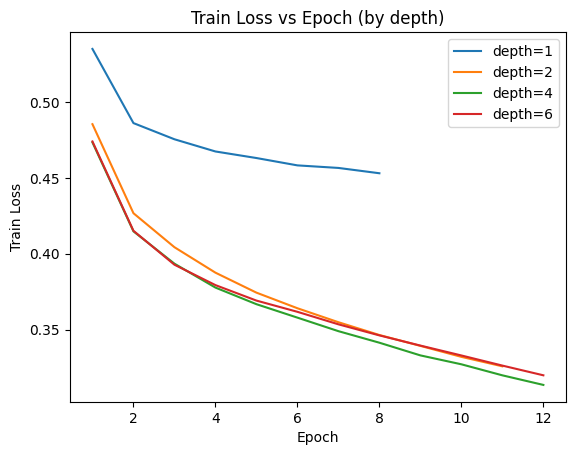

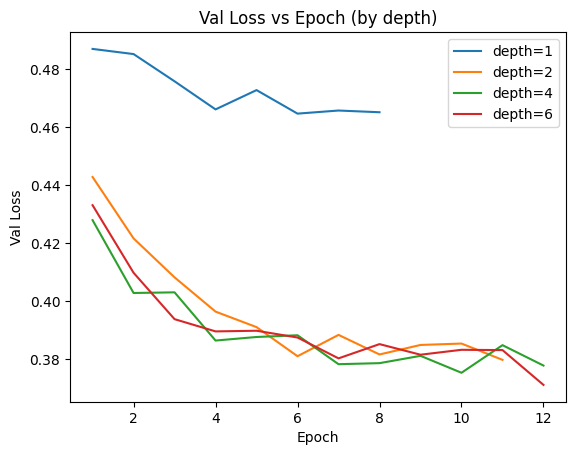

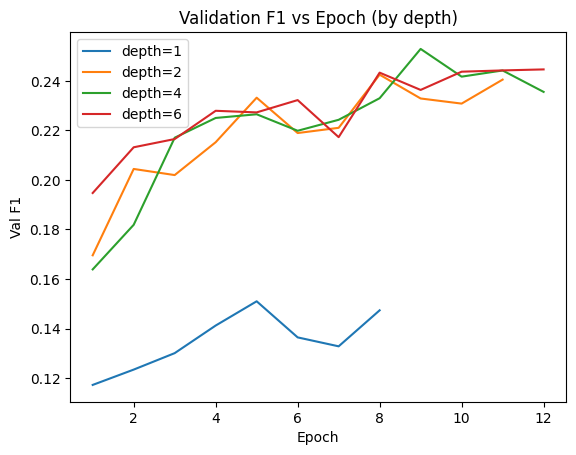

In [130]:
import matplotlib.pyplot as plt

# assumes `results` is a dict like: results[depth]["history"] with keys
# "train_loss", "val_loss", "val_f1"

plt.figure()
for d in sorted(results.keys()):
    h = results[d]["history"]
    xs = range(1, len(h["train_loss"]) + 1)
    plt.plot(xs, h["train_loss"], label=f"depth={d}")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss vs Epoch (by depth)")
plt.legend()
plt.show()

plt.figure()
for d in sorted(results.keys()):
    h = results[d]["history"]
    xs = range(1, len(h["val_loss"]) + 1)
    plt.plot(xs, h["val_loss"], label=f"depth={d}")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Val Loss vs Epoch (by depth)")
plt.legend()
plt.show()

plt.figure()
for d in sorted(results.keys()):
    h = results[d]["history"]
    xs = range(1, len(h["val_f1"]) + 1)
    plt.plot(xs, h["val_f1"], label=f"depth={d}")
plt.xlabel("Epoch")
plt.ylabel("Val F1")
plt.title("Validation F1 vs Epoch (by depth)")
plt.legend()
plt.show()


## Depth Ablation Summary Table

In this cell we summarize the depth experiment in a **single table** so we can compare depths without scanning logs.  
The point is to connect *capacity* (depth/parameters) with *generalization* (validation/test entity-level F1).

In [132]:
import pandas as pd

# Assumes you stored depth runs in something like:
# results[depth] = {
#   "best_val_f1": float,
#   "test_metrics": {"f1": float, "loss": float, ...},
#   "param_count": int (optional),
#   "history": {...} (optional)
# }

rows = []
for depth, run in results.items():
    test = run.get("test_metrics", {}) or {}
    rows.append({
        "depth": depth,
        "best_val_f1": run.get("best_val_f1", None),
        "test_f1": test.get("f1", None),
        "test_loss": test.get("loss", None),
        "params": run.get("param_count", None),
    })

df_depth = pd.DataFrame(rows).sort_values("depth").reset_index(drop=True)

# (optional) nicer formatting
if "params" in df_depth:
    df_depth["params"] = df_depth["params"].map(lambda x: f"{int(x):,}" if pd.notna(x) else x)

df_depth


,depth,best_val_f1,test_f1,test_loss,params
0,1,0.150990,0.146667,0.468966,None
1,2,0.242482,0.257785,0.374575,None
2,4,0.252885,0.266362,0.371385,None
3,6,0.244612,0.259333,0.365566,None


## Visualizing the Depth Ablation

In this cell we visualize the most important ablation trend: how **test entity-level F1** changes as we increase the **number of encoder layers**.

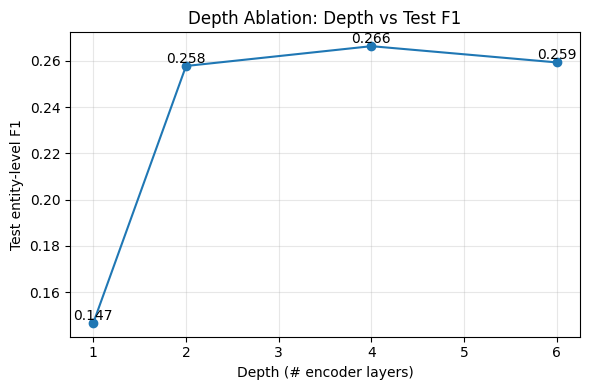

In [134]:
import matplotlib.pyplot as plt
import numpy as np

# Use your summary table from the previous cell
df = df_depth.copy()

# Keep only rows that have test F1
df = df.dropna(subset=["test_f1"]).sort_values("depth")

x = df["depth"].to_numpy()
y = df["test_f1"].to_numpy()

plt.figure(figsize=(6, 4))
plt.plot(x, y, marker="o")
plt.xlabel("Depth (# encoder layers)")
plt.ylabel("Test entity-level F1")
plt.title("Depth Ablation: Depth vs Test F1")
plt.grid(True, alpha=0.3)

# annotate each point with its value
for xi, yi in zip(x, y):
    plt.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Choosing the Best Depth and Inspecting What the Model Learned

Now that we have trained multiple Transformer depths, we do two “research-lab” steps:

1) **Model selection:** we pick the depth that performs best on **test entity-level F1** (with a clear tie-break if needed).  
2) **Qualitative inspection:** we look at one validation sentence, compare predicted tags to tokens, and visualize attention maps if our model exposes them.

In [135]:
best_L = None
best_model = None
best_test_f1 = -1.0

for depth, run in results.items():
    f1 = run["test_metrics"]["f1"]

    if f1 > best_test_f1:
        best_test_f1 = f1
        best_L = depth

print("Best depth based on TEST F1:", best_L)
print("Best test F1:", best_test_f1)

# rebuild best model
best_model, _, _, _ = train_mha_depth(num_layers=best_L)


Best depth based on TEST F1: 4
Best test F1: 0.26636174636174637


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


/tmp/ipykernel_55/2340211572.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
/tmp/ipykernel_55/2340211572.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels[i, :L] = torch.tensor(y, dtype=torch.long)


TOK | GOLD | PRED
------------------------------------------------------------
<unk>           | O            | B-CARDINAL    
<unk>           | B-NORP       | B-NORP       ✓
<unk>           | O            | B-NORP        
has             | O            | O            ✓
found           | O            | O            ✓
the             | O            | O            ✓
bodies          | O            | O            ✓
of              | O            | O            ✓
three           | B-CARDINAL   | B-CARDINAL   ✓
of              | O            | O            ✓
the             | O            | O            ✓
<unk>           | B-CARDINAL   | B-GPE         
sailors         | O            | O            ✓
who             | O            | O            ✓
were            | O            | O            ✓
killed          | O            | O            ✓
when            | O            | O            ✓
the             | O            | O            ✓
nuclear         | O            | O            ✓
submarine

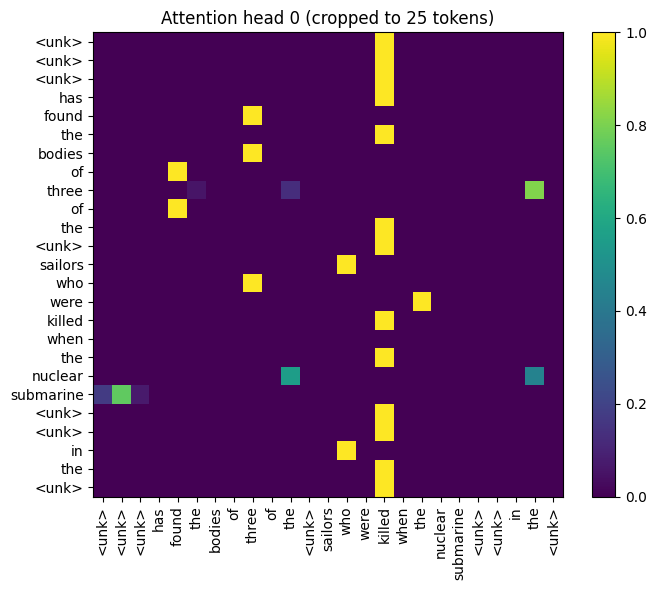

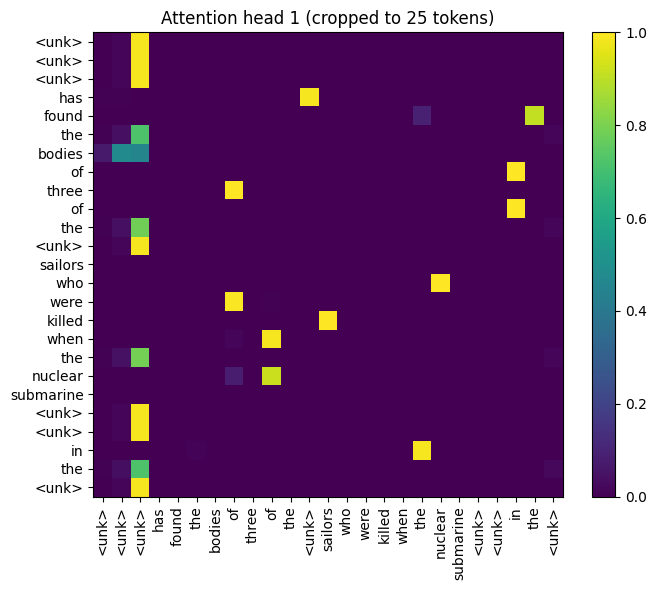

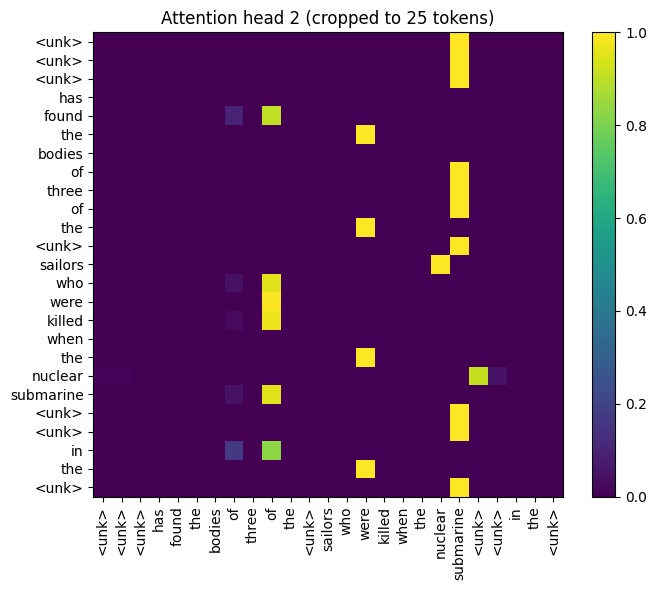

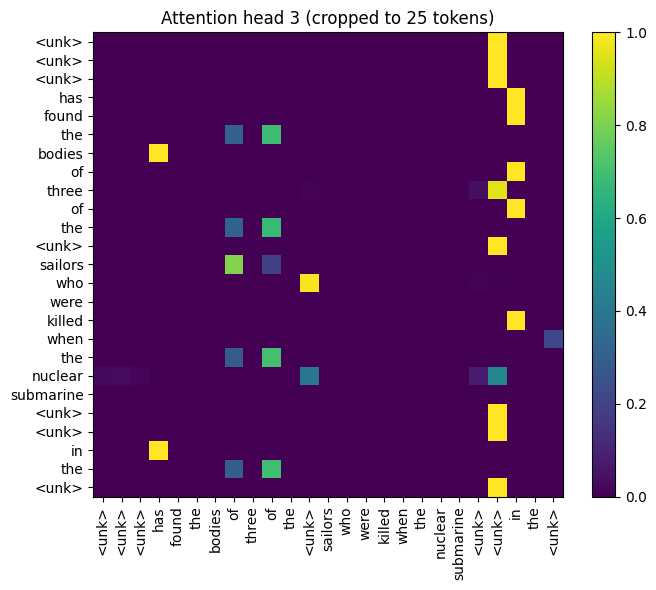

In [137]:
import torch
import matplotlib.pyplot as plt

best_model.eval()

# ---------- helper: id -> token ----------
# If you already have `itos`, use it. Otherwise build it from stoi.
if "itos" not in globals():
    itos = [None] * len(stoi)
    for tok, idx in stoi.items():
        itos[idx] = tok

# ---------- 1) get ONE example from valid_loader ----------
batch = next(iter(valid_loader))
idx = 0  # pick first example in batch

input_ids = batch["input_ids"][idx:idx+1].to(device)           # [1, T]
attention_mask = batch.get("attention_mask", None)
if attention_mask is not None:
    attention_mask = attention_mask[idx:idx+1].to(device)      # [1, T]

labels = batch.get("labels", None)
if labels is not None:
    labels = labels[idx:idx+1].to(device)                      # [1, T]

# true (unpadded) length L
if attention_mask is not None:
    L = int(attention_mask.sum().item())
elif labels is not None:
    L = int((labels != cfg.ignore_index).sum().item())
else:
    L = input_ids.size(1)

max_tokens = 25
L = min(L, max_tokens)

tokens = [itos[i] for i in input_ids[0, :L].tolist()]

# ---------- 2) run model (try to also get attention if supported) ----------
attn = None
with torch.no_grad():
    try:
        # works for models that implement return_attn_layer (Part 5/6 style)
        logits, attn = best_model(input_ids, attention_mask=attention_mask, return_attn_layer=0)
    except TypeError:
        try:
            # works for models that implement return_attn=True (Part 3/4/5 style)
            logits, attn = best_model(input_ids, attention_mask=attention_mask, return_attn=True)
        except TypeError:
            # logits-only fallback
            logits = best_model(input_ids, attention_mask=attention_mask)

pred_ids = logits.argmax(dim=-1)  # [1, T]

# ---------- 3) decode tags + print compact preview ----------
# If you already have ids_to_tags(...) use it (recommended, consistent with your metrics).
if "ids_to_tags" in globals():
    # ids_to_tags expects [B,T], and will ignore padding using ignore_index
    if labels is not None:
        y_true, y_pred = ids_to_tags(labels, pred_ids)
        pred_tags = y_pred[0][:L]
        true_tags = y_true[0][:L]
    else:
        # no gold labels available: just decode preds via label_names if you have it
        pred_tags = [label_names[i] for i in pred_ids[0, :L].tolist()]
        true_tags = None
else:
    pred_tags = [label_names[i] for i in pred_ids[0, :L].tolist()]
    true_tags = [label_names[i] for i in labels[0, :L].tolist()] if labels is not None else None

print("TOK | GOLD | PRED")
print("-" * 60)
for i in range(L):
    tok = tokens[i]
    pred = pred_tags[i]
    gold = true_tags[i] if true_tags is not None else "-"
    mark = "✓" if true_tags is not None and gold == pred else " "
    print(f"{tok:15s} | {gold:12s} | {pred:12s} {mark}")

# ---------- 4) (optional) visualize attention if available ----------
if attn is None:
    print("\n(No attention returned by this model — skipping heatmap.)")
else:
    # normalize attn shape to [H, T, T] for this single example
    # common shapes: [B,H,T,T] or [H,T,T] or [B,T,T]
    if attn.dim() == 4:
        attn_ex = attn[0]          # [H, T, T]
    elif attn.dim() == 3:
        # could be [B,T,T] or [H,T,T]; assume first dim is batch if it matches input
        attn_ex = attn[0] if attn.size(0) == 1 else attn
    else:
        print("\n(Attention had an unexpected shape — skipping heatmap.)")
        attn_ex = None

    if attn_ex is not None:
        attn_ex = attn_ex[:, :L, :L]  # crop padding
        H = attn_ex.size(0)
        heads_to_show = min(H, 4)

        for h in range(heads_to_show):
            plt.figure(figsize=(7, 6))
            plt.imshow(attn_ex[h].detach().cpu().numpy(), aspect="auto")
            plt.title(f"Attention head {h} (cropped to {L} tokens)")
            plt.xticks(range(L), tokens, rotation=90)
            plt.yticks(range(L), tokens)
            plt.colorbar()
            plt.tight_layout()
            plt.show()


## Concept Checks (answer in Markdown, no code)

1) **Depth vs. capacity:**  
   What changes when we increase the number of encoder layers? Is it only “more parameters,” or also “more computation steps for composition”?

Increasing encoder layers adds both more parameters and more computation steps.

More parameters → higher representational capacity.

More layers → more sequential context mixing/composition, allowing the model to combine information across tokens multiple times and build richer representations (not just bigger, but deeper reasoning over the sequence).

2) **Qualitative inspection:**  
   When we inspect one sentence, what kinds of NER errors should we categorize?  
   Which error types are most likely to be improved by “more context mixing” across layers?

Common NER error types:

Boundary errors (entity spans too long/short)

Wrong entity type (ORG vs LOC)

Missed entities (false negatives)

Spurious entities (false positives)

Errors most improved by deeper context mixing:

Boundary errors and wrong-type errors, because deeper layers integrate wider context and long-range dependencies that clarify entity roles and span limits.

# Part 7 — A Tiny BERT-Like Encoder

In Parts 3–6 we explored attention-only models and the effect of positional information.  
In this part, we move one step closer to **BERT-style inputs and embeddings**:

- We extend our **word-level vocabulary** with special tokens: `[CLS]`, `[SEP]`, `[MASK]`.
- We build a dataset and collate function that produce the typical BERT inputs:
  - `input_ids`
  - `token_type_ids` (segment IDs)
  - `position_ids`
  - `attention_mask`
  - `labels` aligned with the tokens (and ignored on special tokens)
- We implement a **TinyBERT-like** encoder:
  - token + position + segment embeddings
  - stacked Transformer encoder blocks
  - token-level classifier head for NER

The goal is not to reproduce pretrained BERT performance, but to understand **the full input pipeline and architectural ingredients** that make BERT “BERT”.

## Add BERT Special Tokens to the Vocabulary

We ensure `[CLS]`, `[SEP]`, and `[MASK]` exist in our word-level vocabulary so later “BERT-style” dataset and model code can reference them reliably.

In [139]:
BERT_CLS = "[CLS]"
BERT_SEP = "[SEP]"
BERT_MASK = "[MASK]"


def add_special_tokens_to_vocab(
    stoi: Dict[str, int],
    special_tokens: List[str],
) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    Ensure required special tokens exist in the word-level vocabulary.

    Args:
        stoi: token -> id mapping (will be updated in-place)
        special_tokens: list of tokens to add if missing

    Returns:
        (stoi, itos) where itos is id -> token mapping
    """
    for tok in special_tokens:
        if tok not in stoi:
            stoi[tok] = len(stoi)

    itos = {i: s for s, i in stoi.items()}
    return stoi, itos


stoi, itos = add_special_tokens_to_vocab(stoi, [BERT_CLS, BERT_SEP, BERT_MASK])

print("Vocab size:", len(stoi))
print(
    "IDs:",
    {t: stoi[t] for t in [cfg.pad_token, cfg.unk_token, BERT_CLS, BERT_SEP, BERT_MASK]},
)

Vocab size: 20606
IDs: {'<pad>': 0, '<unk>': 1, '[CLS]': 20603, '[SEP]': 20604, '[MASK]': 20605}


## Build a BERT-Style NER Dataset

We wrap the raw NER data into a BERT-like input format by inserting `[CLS]`/`[SEP]`, truncating to a maximum length, converting tokens to ids, and aligning labels so that special tokens use `ignore_index`.

In [142]:
class NERBertInputDataset(Dataset):
    """
    A dataset that converts word-level NER examples into a BERT-style format:

      tokens  -> [CLS] tokens ... [SEP]
      labels  -> ignore_index for special tokens, original labels for real tokens
      ids     -> token ids from `stoi`
      token_type_ids -> all zeros for single-sequence inputs
    """

    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len  # includes [CLS] and [SEP]

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        # --- read raw example ---
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        # --- truncate to leave room for [CLS] and [SEP] ---
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]
        labels = labels[:max_tokens]

        # --- add special tokens ---
        bert_tokens = [BERT_CLS] + tokens + [BERT_SEP]

        # --- map tokens to ids (UNK fallback) ---
        unk_id = self.stoi[cfg.unk_token]
        input_ids = [self.stoi.get(tok, unk_id) for tok in bert_tokens]

        # --- align labels (ignore specials) ---
        bert_labels = [cfg.ignore_index] + labels + [cfg.ignore_index]

        # --- single segment ---
        token_type_ids = [0] * len(input_ids)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "labels": torch.tensor(bert_labels, dtype=torch.long),
            "tokens": bert_tokens,  # keep for debugging/inspection
        }


## BERT-Style Collation for NER (Padding, Masks, Positions)

We implement a custom `collate_fn` that pads variable-length BERT-formatted sequences, builds an `attention_mask`, generates `position_ids`, and pads labels using `ignore_index` so loss is computed only on real tokens.

In [151]:
def bert_ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    # lengths (unpadded)
    lengths = torch.tensor([ex["input_ids"].shape[0] for ex in batch], dtype=torch.long)
    B = len(batch)
    T = int(lengths.max().item())

    pad_id = stoi[cfg.pad_token]

    # allocate padded tensors
    input_ids = torch.full((B, T), pad_id, dtype=torch.long)
    token_type_ids = torch.zeros((B, T), dtype=torch.long)
    labels = torch.full((B, T), cfg.ignore_index, dtype=torch.long)
    attention_mask = torch.zeros((B, T), dtype=torch.long)

    tokens_out = []

    for i, ex in enumerate(batch):
        L = ex["input_ids"].shape[0]
        input_ids[i, :L] = ex["input_ids"]
        token_type_ids[i, :L] = ex["token_type_ids"]
        labels[i, :L] = ex["labels"]
        attention_mask[i, :L] = 1

        tokens_out.append(ex.get("tokens", None))

    # positions 0..T-1 for each row
    position_ids = torch.arange(T, dtype=torch.long).unsqueeze(0).expand(B, T)

    out = {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "attention_mask": attention_mask,
        "position_ids": position_ids,
        "labels": labels,
        "lengths": lengths,
    }

    # optional but useful for debugging
    if any(t is not None for t in tokens_out):
        out["tokens"] = tokens_out

    return out


## BERT-Style Embeddings (Token + Position + Segment)

We implement the embedding layer used in BERT-like encoders by combining token embeddings with positional and segment/type embeddings, then applying normalization and dropout before passing representations to the encoder blocks.

In [162]:
class BertEmbeddings(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        pad_id: int,
        max_len: int = 512,
        type_vocab_size: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        self.token_embeddings = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_embeddings = nn.Embedding(max_len, d_model)
        self.segment_embeddings = nn.Embedding(type_vocab_size, d_model)

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # (Optional but common) BERT-like init
        nn.init.normal_(self.token_embeddings.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.position_embeddings.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.segment_embeddings.weight, mean=0.0, std=0.02)

        # padding row can drift with normal init; zero it back out
        if pad_id is not None:
            with torch.no_grad():
                self.token_embeddings.weight[pad_id].fill_(0.0)

    def forward(
        self,
        input_ids: torch.Tensor,
        token_type_ids: torch.Tensor = None,
        position_ids: torch.Tensor = None,
    ) -> torch.Tensor:
        B, T = input_ids.shape

        if token_type_ids is None:
            token_type_ids = torch.zeros((B, T), dtype=torch.long, device=input_ids.device)

        if position_ids is None:
            position_ids = torch.arange(T, dtype=torch.long, device=input_ids.device).unsqueeze(0).expand(B, T)

        tok = self.token_embeddings(input_ids)              # [B, T, D]
        pos = self.position_embeddings(position_ids)        # [B, T, D]
        seg = self.segment_embeddings(token_type_ids)       # [B, T, D]

        x = tok + pos + seg
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


## Tiny BERT-Like Encoder for NER

We define a small BERT-style model for token classification: BERT-like embeddings, a stack of Transformer encoder blocks, and a token-level classifier head. The forward pass may optionally return an attention matrix from a chosen layer for interpretability.

In [164]:
class TinyBertLikeForNER(nn.Module):
    """
    Tiny BERT-like encoder for NER:
      - BertEmbeddings (token + position + segment)
      - stack of BertStyleEncoderBlock
      - token-level classifier
    """
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.emb = BertEmbeddings(
            vocab_size=vocab_size,
            d_model=d_model,
            pad_id=pad_id,
            max_len=max_len,
            type_vocab_size=2,
            dropout=dropout,
        )

        self.blocks = nn.ModuleList(
            [
                BertStyleEncoderBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    dropout=dropout,
                    ff_mult=4,
                )
                for _ in range(num_layers)
            ]
        )

        self.out_drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)

        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        token_type_ids: torch.Tensor = None,
        position_ids: torch.Tensor = None,
        return_attn_layer: int = -1,
    ):
        x = self.emb(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)

        attn_to_return = None
        for i, blk in enumerate(self.blocks):
            if i == return_attn_layer:
                x, attn_to_return = blk(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = blk(x, attention_mask=attention_mask, return_attn=False)

        x = self.out_drop(x)
        logits = self.classifier(x)  # [B, T, num_labels]

        if return_attn_layer >= 0:
            return logits, attn_to_return
        return logits


## Inspect a BERT-Style Batch Example

We print one example from `train_bert_loader` to confirm that tokens, labels, attention masks, token-type ids, and position ids are aligned correctly—especially around `[CLS]`, `[SEP]`, padding, and `ignore_index`.

In [175]:
MAX_LEN_BERT = 256  

train_bert_ds = NERBertInputDataset(ds["train"], stoi=stoi, max_len=MAX_LEN_BERT)
valid_bert_ds = NERBertInputDataset(ds["validation"], stoi=stoi, max_len=MAX_LEN_BERT)
test_bert_ds  = NERBertInputDataset(ds["test"], stoi=stoi, max_len=MAX_LEN_BERT)

train_bert_loader = DataLoader(
    train_bert_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

valid_bert_loader = DataLoader(
    valid_bert_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

test_bert_loader = DataLoader(
    test_bert_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

batch = next(iter(train_bert_loader))

bs = len(batch["tokens"])
idx = 1 if bs > 1 else 0
print(f"BATCH SIZE: {bs} | showing example index: {idx}")

tokens = batch["tokens"][idx]
labels = batch["labels"][idx].tolist()
token_type_ids = batch["token_type_ids"][idx].tolist()
position_ids = batch["position_ids"][idx].tolist()
attention_mask = batch["attention_mask"][idx].tolist()

L = int(sum(attention_mask))  # number of real (non-pad) tokens
print("TOKENS         :", tokens[:L])
print("TOKEN_TYPE_IDS :", token_type_ids[:L])
print("POSITION_IDS   :", position_ids[:L])
print("LABELS         :", labels[:L], f"(ignore_index = {cfg.ignore_index})")

BATCH SIZE: 32 | showing example index: 1
TOKENS         : ['[CLS]', 'Stock', 'funds', ',', 'like', 'the', 'market', 'as', 'a', 'whole', ',', 'generally', 'dropped', 'more', 'than', '2', '%', 'in', 'the', 'week', 'through', 'last', 'Thursday', ',', 'according', 'to', 'figures', 'compiled', 'by', 'Lipper', 'Analytical', 'Services', 'Inc', '.', '[SEP]']
TOKEN_TYPE_IDS : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
POSITION_IDS   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
LABELS         : [-100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 14, 14, 14, 0, 2, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 11, 12, 12, 12, 0, -100] (ignore_index = -100)


## Sanity Check: Forward Pass Shapes

We instantiate the tiny BERT-like model and run one batch through it to confirm tensor shapes and device placement. This helps catch silent bugs early (especially with padding masks and sequence length handling).

In [176]:
# ---- Instantiate TinyBertLikeForNER + sanity-check shapes ----
tiny_bert = TinyBertLikeForNER(
    vocab_size=len(stoi),
    num_labels=num_labels,
    pad_id=stoi[cfg.pad_token],
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=MAX_LEN_BERT,
).to(device)

# `batch` is assumed to come from train_bert_loader in a previous cell
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
token_type_ids = batch["token_type_ids"].to(device)
position_ids = batch["position_ids"].to(device)

logits = tiny_bert(
    input_ids,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids,
    position_ids=position_ids,
)

print("input_ids:", input_ids.shape)
print("logits   :", logits.shape, "(expected [B, T, num_labels])")

input_ids: torch.Size([32, 52])
logits   : torch.Size([32, 52, 37]) (expected [B, T, num_labels])


## Training and Evaluation Loops for the TinyBERT-like Model

We implement the core learning logic: a training loop (forward → loss → backward → update) and an evaluation loop that reports masked loss, token accuracy, and entity-level NER metrics (precision/recall/F1). These functions must correctly ignore padding and special-token positions using `cfg.ignore_index`.

In [177]:
def train_one_epoch_bert(model, loader, optimizer, grad_clip: float = 1.0):
    model.train()

    total_loss_sum = 0.0
    total_tokens = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            return_attn_layer=-1,
        )  # [B, T, C]

        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)  # sums over real tokens
        loss = loss_sum / max(n_tokens, 1)

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        total_loss_sum += loss_sum.item()
        total_tokens += n_tokens

    return total_loss_sum / max(total_tokens, 1)


@torch.no_grad()
def evaluate_bert(model, loader):
    model.eval()

    total_loss_sum = 0.0
    total_tokens = 0

    token_correct = 0
    token_total = 0

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            return_attn_layer=-1,
        )  # [B, T, C]

        preds = logits.argmax(dim=-1)

        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss_sum += loss_sum.item()
        total_tokens += n_tokens

        mask = labels != cfg.ignore_index
        token_correct += ((preds == labels) & mask).sum().item()
        token_total += mask.sum().item()

        y_true, y_pred = ids_to_tags(labels, preds)  # should ignore cfg.ignore_index internally
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    return {
        "loss": total_loss_sum / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }


## Training Loop with Early Stopping and Checkpointing

We set up an optimizer and run multi-epoch training for the TinyBERT-like model. During training, we record learning curves (loss, token accuracy, and NER F1) and implement early stopping on a validation metric (typically F1) by saving and reloading the best model checkpoint.


In [178]:
# --- Optimizer ---
optimizer = torch.optim.AdamW(tiny_bert.parameters(), lr=5e-4, weight_decay=0.01)

# --- Training hyperparameters ---
EPOCHS = 10
patience = 3

# --- Early stopping bookkeeping ---
best_metric = -1.0          # we early-stop on val F1
best_state = None
bad_epochs = 0

hist7 = {
    "train_loss": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_f1": [],
}

# --- Training loop ---
for ep in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_bert(tiny_bert, train_bert_loader, optimizer)
    val_metrics = evaluate_bert(tiny_bert, valid_bert_loader)

    hist7["train_loss"].append(train_loss)
    hist7["val_loss"].append(val_metrics["loss"])
    hist7["val_token_acc"].append(val_metrics["token_acc"])
    hist7["val_f1"].append(val_metrics["f1"])

    print(
        f"Epoch {ep:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_token_acc={val_metrics['token_acc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    # early stopping on validation F1
    if val_metrics["f1"] > best_metric + 1e-6:
        best_metric = val_metrics["f1"]
        best_state = {k: v.detach().cpu().clone() for k, v in tiny_bert.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping triggered.")
            break

# --- Restore best checkpoint ---
if best_state is not None:
    tiny_bert.load_state_dict(best_state)
print(f"Loaded best TinyBERT-like model with val_F1 = {best_metric:.4f}")


Epoch 01 | train_loss=0.3753 | val_loss=0.2940 | val_token_acc=0.9135 | val_f1=0.4109
Epoch 02 | train_loss=0.2620 | val_loss=0.2803 | val_token_acc=0.9167 | val_f1=0.4355
Epoch 03 | train_loss=0.2205 | val_loss=0.2707 | val_token_acc=0.9197 | val_f1=0.4577
Epoch 04 | train_loss=0.1920 | val_loss=0.2778 | val_token_acc=0.9194 | val_f1=0.4626
Epoch 05 | train_loss=0.1699 | val_loss=0.2823 | val_token_acc=0.9212 | val_f1=0.4744
Epoch 06 | train_loss=0.1539 | val_loss=0.2870 | val_token_acc=0.9205 | val_f1=0.4730
Epoch 07 | train_loss=0.1405 | val_loss=0.2976 | val_token_acc=0.9207 | val_f1=0.4702
Epoch 08 | train_loss=0.1301 | val_loss=0.3076 | val_token_acc=0.9187 | val_f1=0.4735
Early stopping triggered.
Loaded best TinyBERT-like model with val_F1 = 0.4744


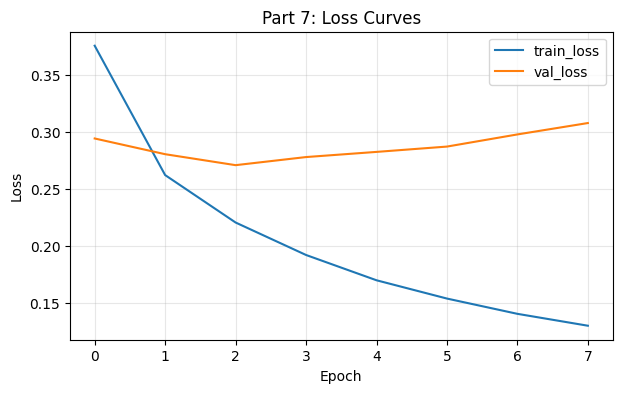

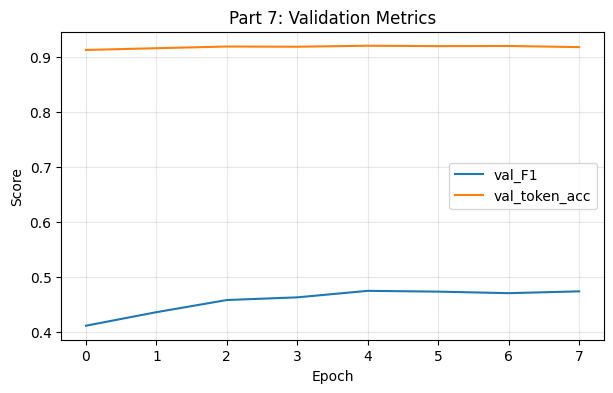

In [179]:
import matplotlib.pyplot as plt

# --- Loss curves ---
plt.figure(figsize=(7, 4))
plt.plot(hist7["train_loss"], label="train_loss")
plt.plot(hist7["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 7: Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Score curves (optional but recommended) ---
plt.figure(figsize=(7, 4))
if "val_f1" in hist7:
    plt.plot(hist7["val_f1"], label="val_F1")
if "val_token_acc" in hist7:
    plt.plot(hist7["val_token_acc"], label="val_token_acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Part 7: Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Final Test Evaluation

We run the finalized TinyBERT-like model on the **test set** and report the core metrics (loss, token accuracy, and entity-level F1). This is the main quantitative summary of how well our model generalizes to unseen data.

In [180]:
test7 = evaluate_bert(tiny_bert, test_bert_loader)

print(
    f"Part 7 TEST | "
    f"loss={test7['loss']:.4f} | "
    f"token_acc={test7['token_acc']:.4f} | "
    f"precision={test7['precision']:.4f} | "
    f"recall={test7['recall']:.4f} | "
    f"f1={test7['f1']:.4f}"
)


Part 7 TEST | loss=0.2742 | token_acc=0.9229 | precision=0.4594 | recall=0.4957 | f1=0.4769


## Concept Checks (answer in Markdown, no code)

1. **Special tokens & supervision**
   - Why do we set labels for `[CLS]` and `[SEP]` to `ignore_index`?
   - What would go wrong if we trained on those positions?

We set labels for [CLS] and [SEP] to ignore_index because they are not real words and have no NER tags.

If we trained on them, the model would learn meaningless label predictions for special tokens and this would add noise to the loss and hurt NER performance.

2. **Truncation effects**
   - We truncate tokens to `max_len - 2`. Why exactly “minus 2”?
   - What is the trade-off between a larger `max_len` and training speed/memory?

We use max_len - 2 because we must reserve space for the two special tokens: [CLS] at the start and [SEP] at the end.

Larger max_len allows more context and potentially better predictions, but increases memory usage and slows training since attention cost grows with sequence length.

3. **Architecture reflection**
   - Compare TinyBERT-like (this part) to the “attention-only with PE” model (Part 4):
     - What is the same?
     - What is different?

What is the same:

Both use attention-based encoders with positional information and token-level classifiers.

Both rely on masked loss and similar training/evaluation logic.

What is different:

TinyBERT adds segment embeddings and special tokens ([CLS], [SEP]) like real BERT input format.

It uses BERT-style embeddings (token + position + segment) and a deeper stacked encoder design closer to real Transformer/BERT architecture.

## Masked Language Modeling (MLM): Pretraining Objective

In this part we switch from **supervised NER** to a **self-supervised pretraining task**: **Masked Language Modeling (MLM)** (the core objective used in BERT-style models).  
Instead of predicting entity tags, the model sees sentences where some tokens are hidden and must **predict the original tokens** using context from both sides.

By the end of this part, you will:
- Build an MLM dataset and dynamic masking pipeline (the classic **80/10/10** masking rule).
- Train a small BERT-like encoder + MLM head using only masked positions for the loss.
- Evaluate the model using MLM loss (and optionally top-k masked accuracy).
- Visualize attention maps inside the encoder to see what patterns it learns during pretraining.

## Sanity Check
* This cell is a **sanity check**: it ensures all special tokens were added earlier and have valid IDs.
* If any key is missing, it means the notebook skipped the “add special tokens” step.

In [181]:
STOI = stoi
ITOS = itos

CLS_ID  = STOI[BERT_CLS]
SEP_ID  = STOI[BERT_SEP]
MASK_ID = STOI[BERT_MASK]
PAD_ID  = STOI[cfg.pad_token]
UNK_ID  = STOI[cfg.unk_token]

print("Shared vocab size:", len(STOI))
print({t: STOI[t] for t in [cfg.pad_token, cfg.unk_token, BERT_CLS, BERT_SEP, BERT_MASK]})

Shared vocab size: 20606
{'<pad>': 0, '<unk>': 1, '[CLS]': 20603, '[SEP]': 20604, '[MASK]': 20605}


## MLM Dataset (Sentence → BERT-style Input)

In this step, we build a dataset that wraps each sentence as **[CLS] tokens [SEP]** and returns `input_ids` + `token_type_ids`; **masking is NOT done here** (it will be applied later inside the `collate_fn` for dynamic MLM masking).

In [190]:
class MLMSentenceDataset(Dataset):
    """
    Dataset for MLM pretraining:
    returns a single sentence wrapped with [CLS] ... [SEP].
    (Masking + MLM labels will be created later in the collate_fn.)
    """
    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len  # includes [CLS] and [SEP]

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        ex = self.split[idx]
        tokens = ex["tokens"]

        # truncate to leave room for [CLS] and [SEP]
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]

        # add special tokens
        bert_tokens = [BERT_CLS] + tokens + [BERT_SEP]

        # map tokens -> ids (fallback to UNK)
        unk_id = self.stoi[cfg.unk_token]
        input_ids = [self.stoi.get(tok, unk_id) for tok in bert_tokens]

        # single-sentence => all zeros
        token_type_ids = [0] * len(input_ids)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "tokens": bert_tokens,
        }


## Dynamic MLM Masking + Collate Function

In this step, we implement **BERT-style dynamic masking (15% with 80/10/10 rule)** inside the `collate_fn`, so each epoch sees *different masked positions* without changing the stored dataset.

In [196]:
def mask_tokens_bert_style(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    mlm_prob: float = 0.15,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    BERT-style dynamic masking (done on-the-fly).

    input_ids:      [B, T]
    attention_mask: [B, T]  1 for real tokens, 0 for padding

    returns:
      masked_input_ids: [B, T]
      mlm_labels:       [B, T] with original ids at masked positions, cfg.ignore_index elsewhere
    """
    device = input_ids.device
    B, T = input_ids.shape

    # labels are ignore_index everywhere by default
    mlm_labels = torch.full_like(input_ids, fill_value=cfg.ignore_index)

    # candidate positions: real tokens and not special tokens
    special_ids = torch.tensor([PAD_ID, CLS_ID, SEP_ID], device=device)
    is_special = (input_ids.unsqueeze(-1) == special_ids).any(dim=-1)  # [B, T]

    candidate = (attention_mask == 1) & (~is_special)  # [B, T]

    # sample mask positions
    mask_positions = (torch.rand((B, T), device=device) < mlm_prob) & candidate

    # set MLM labels only at masked positions (original token ids)
    mlm_labels[mask_positions] = input_ids[mask_positions]

    # nothing to mask? return early
    if mask_positions.sum().item() == 0:
        return input_ids, mlm_labels

    masked_input_ids = input_ids.clone()

    # 80/10/10 split for replacement among the masked positions
    # draw a uniform random value per position; only used where mask_positions=True
    r = torch.rand((B, T), device=device)

    replace_with_mask = mask_positions & (r < 0.80)
    replace_with_rand = mask_positions & (r >= 0.80) & (r < 0.90)
    # keep unchanged = remaining 10% (r >= 0.90)

    # 80% -> [MASK]
    masked_input_ids[replace_with_mask] = MASK_ID

    # 10% -> random token (exclude specials)
    # build allowed token ids: [0..|V|-1] excluding special ids
    vocab_size = len(STOI)
    all_ids = torch.arange(vocab_size, device=device)
    disallowed = torch.tensor([PAD_ID, CLS_ID, SEP_ID, MASK_ID], device=device)
    allowed_ids = all_ids[~(all_ids.unsqueeze(-1) == disallowed).any(dim=-1)]

    n_rand = int(replace_with_rand.sum().item())
    if n_rand > 0:
        rand_idxs = torch.randint(low=0, high=len(allowed_ids), size=(n_rand,), device=device)
        rand_token_ids = allowed_ids[rand_idxs]
        masked_input_ids[replace_with_rand] = rand_token_ids

    return masked_input_ids, mlm_labels


In [199]:
MAX_LEN_BERT = 256   

mlm_train_ds = MLMSentenceDataset(ds["train"], STOI, max_len=MAX_LEN_BERT)
mlm_valid_ds = MLMSentenceDataset(ds["validation"], STOI, max_len=MAX_LEN_BERT)

print("MLM train size:", len(mlm_train_ds))
print("MLM valid size:", len(mlm_valid_ds))
print("Example tokens:", mlm_train_ds[0]["tokens"][:15])

def mlm_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    lengths = [ex["input_ids"].shape[0] if torch.is_tensor(ex["input_ids"]) else len(ex["input_ids"])
               for ex in batch]
    max_len = max(lengths)
    B = len(batch)

    input_ids = torch.full((B, max_len), fill_value=PAD_ID, dtype=torch.long)
    token_type_ids = torch.zeros((B, max_len), dtype=torch.long)
    attention_mask = torch.zeros((B, max_len), dtype=torch.long)

    tokens_list = []
    for i, ex in enumerate(batch):
        ids = ex["input_ids"]
        ttypes = ex["token_type_ids"]
        L = ids.shape[0] if torch.is_tensor(ids) else len(ids)

        input_ids[i, :L] = ids
        token_type_ids[i, :L] = ttypes
        attention_mask[i, :L] = 1
        tokens_list.append(ex.get("tokens", None))

    # Position ids: [0..T-1] for each row
    position_ids = torch.arange(max_len, dtype=torch.long).unsqueeze(0).repeat(B, 1)

    masked_input_ids, mlm_labels = mask_tokens_bert_style(
        input_ids=input_ids,
        attention_mask=attention_mask,
        mlm_prob=0.15,
    )

    return {
        "input_ids": masked_input_ids,
        "labels": mlm_labels,
        "token_type_ids": token_type_ids,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "tokens": tokens_list,
        "lengths": torch.tensor(lengths, dtype=torch.long),
    }


mlm_train_loader = DataLoader(
    mlm_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=mlm_collate_fn,
)
mlm_valid_loader = DataLoader(
    mlm_valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=mlm_collate_fn,
)

b = next(iter(mlm_train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in b.items()}


MLM train size: 59924
MLM valid size: 8528
Example tokens: ['[CLS]', 'People', 'start', 'their', 'own', 'businesses', 'for', 'many', 'reasons', '.', '[SEP]']


{'input_ids': torch.Size([32, 53]),
 'labels': torch.Size([32, 53]),
 'token_type_ids': torch.Size([32, 53]),
 'position_ids': torch.Size([32, 53]),
 'attention_mask': torch.Size([32, 53]),
 'tokens': list,
 'lengths': torch.Size([32])}

## TinyBERT Encoder + MLM Head (with Weight Tying)

Here we build a small BERT-like encoder and an MLM prediction head, including **weight tying** between the input token embeddings and the output decoder matrix.

In [203]:
class TinyBertEncoder(nn.Module):
    """
    A tiny BERT-style encoder: embeddings + a stack of encoder blocks.
    Returns contextual token representations h in R^{B×T×D}.
    """
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.emb = BertEmbeddings(vocab_size, d_model, pad_id=pad_id, max_len=max_len, dropout=dropout)

        # Stack of Transformer encoder blocks (BERT-style)
        self.blocks = nn.ModuleList([
            BertStyleEncoderBlock(d_model=d_model, num_heads=num_heads, dropout=dropout, ff_mult=4)
            for _ in range(num_layers)
        ])

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        x = self.emb(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
        for blk in self.blocks:
            x = blk(x, attention_mask=attention_mask, return_attn=False)
        return x  # [B, T, D]


class MLMHead(nn.Module):
    """
    BERT-style MLM head:
      - linear -> GELU -> LayerNorm -> vocabulary projection
    Optionally ties decoder weights to the input embedding matrix.
    """
    def __init__(self, d_model: int, vocab_size: int, tie_weights: nn.Embedding = None):
        super().__init__()
        self.dense = nn.Linear(d_model, d_model)
        self.act = nn.GELU()
        self.ln = nn.LayerNorm(d_model)

        # Decoder (no bias; BERT keeps bias as a separate parameter)
        self.decoder = nn.Linear(d_model, vocab_size, bias=False)
        self.bias = nn.Parameter(torch.zeros(vocab_size))

        # TODO (concept): weight tying helps reduce parameters and often improves MLM training
        # If tying is enabled, make decoder weights share storage with token embedding weights.
        if tie_weights is not None:
            self.decoder.weight = tie_weights.weight  # weight tying

    def forward(self, x):
        x = self.dense(x)
        x = self.act(x)
        x = self.ln(x)
        logits = self.decoder(x) + self.bias
        return logits  # [B, T, V]


class TinyBertForMLM(nn.Module):
    """
    Full MLM model: Encoder + MLMHead.
    """
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.encoder = TinyBertEncoder(vocab_size, pad_id, d_model, num_heads, num_layers, dropout, max_len)

        # TODO: tie MLM decoder weights to token embedding matrix (like BERT)
        tied = self.encoder.emb.token_embeddings
        self.mlm_head = MLMHead(d_model=d_model, vocab_size=vocab_size, tie_weights=tied)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )
        logits = self.mlm_head(h)
        return logits  # [B, T, V]

## MLM Loss (masked positions only)

We compute the MLM loss **only over masked tokens** (labels ≠ ignore_index), using summed cross-entropy divided by the number of masked tokens.

In [206]:
import torch.nn.functional as F

def mlm_loss_mean(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """
    logits: [B, T, V]
    labels: [B, T] with cfg.ignore_index on non-masked positions

    Return: mean loss over MASKED positions only.
    """
    B, T, V = logits.shape

    logits_flat = logits.view(B * T, V)
    labels_flat = labels.view(B * T)

    loss_sum = F.cross_entropy(
        logits_flat,
        labels_flat,
        ignore_index=cfg.ignore_index,
        reduction="sum",
    )

    n_masked = (labels_flat != cfg.ignore_index).sum().item()

    return loss_sum / max(n_masked, 1)


## MLM Evaluation Loop

Evaluate the MLM model by averaging the **summed masked loss** across a limited number of batches (to keep evaluation fast).

In [208]:
import torch.nn.functional as F

@torch.no_grad()
def evaluate_mlm(model, loader, max_batches: int = None):
    """
    Returns average loss over masked tokens only.
    """
    model.eval()

    total_loss_sum = 0.0
    total_masked = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        logits = model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )

        B, T, V = logits.shape
        logits_flat = logits.view(B * T, V)
        labels_flat = labels.view(B * T)

        loss_sum = F.cross_entropy(
            logits_flat,
            labels_flat,
            ignore_index=cfg.ignore_index,
            reduction="sum",
        )

        n_masked = (labels_flat != cfg.ignore_index).sum().item()

        total_loss_sum += loss_sum.item()
        total_masked += n_masked

    return total_loss_sum / max(total_masked, 1)


## MLM Training Loop (dynamic masking)

Train the MLM model with AdamW, log training loss every `log_every` steps, and periodically evaluate on validation batches to track progress.

In [211]:
import math
from tqdm import tqdm

def train_mlm(
    model,
    train_loader,
    valid_loader,
    epochs: int = 1,
    lr: float = 5e-4,
    weight_decay: float = 0.02,
    max_steps: int = 3000,
    log_every: int = 50,
    eval_batches: int = 50,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {"step": [], "train_loss": [], "valid_loss": []}
    global_step = 0

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for batch in tqdm(train_loader, desc=f"MLM Train (epoch {ep})", leave=False):
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            position_ids = batch["position_ids"].to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(
                input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                position_ids=position_ids,
            )

            loss = mlm_loss_mean(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running += loss.item()
            seen += 1
            global_step += 1

            if global_step % log_every == 0:
                train_loss_avg = running / max(seen, 1)
                val_loss = evaluate_mlm(model, valid_loader, max_batches=eval_batches)

                hist["step"].append(global_step)
                hist["train_loss"].append(train_loss_avg)
                hist["valid_loss"].append(val_loss)

                print(
                    f"step={global_step} | "
                    f"train_loss={train_loss_avg:.4f} | "
                    f"valid_loss={val_loss:.4f} | "
                    f"valid_ppl≈{math.exp(min(val_loss, 20)):.1f}"
                )

                running = 0.0
                seen = 0

            if global_step >= max_steps:
                break

        if global_step >= max_steps:
            break

    return model, hist


## Train TinyBERT for MLM (dynamic masking)

We initialize the MLM model, measure an initial validation loss, then train for a small number of steps/epochs and re-evaluate to confirm learning progress.

In [213]:
seed_everything(cfg.seed)

# 1) Build the MLM model
mlm_model = TinyBertForMLM(
    vocab_size=len(STOI),
    pad_id=PAD_ID,
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=MAX_LEN_BERT,
).to(device)

# 2) Sanity check: initial validation loss (masked tokens only)
print("Initial valid MLM loss:", evaluate_mlm(mlm_model, mlm_valid_loader, max_batches=50))

# 3) Train (reasonable small-budget settings)
mlm_model, mlm_hist = train_mlm(
    mlm_model,
    mlm_train_loader,
    mlm_valid_loader,
    epochs=2,          # enough to see learning
    lr=5e-4,
    weight_decay=0.02,
    max_steps=1500,    # increase if you want better MLM
    log_every=50,
    eval_batches=50,
)

# 4) Final validation loss (after training)
print("Final valid MLM loss:", evaluate_mlm(mlm_model, mlm_valid_loader, max_batches=50))


Initial valid MLM loss: 10.056797871874684


MLM Train (epoch 1):   3%|▎         | 55/1873 [00:03<02:44, 11.03it/s]

step=50 | train_loss=7.6152 | valid_loss=6.1219 | valid_ppl≈455.7


MLM Train (epoch 1):   6%|▌         | 104/1873 [00:05<02:32, 11.62it/s]

step=100 | train_loss=6.2864 | valid_loss=5.9324 | valid_ppl≈377.1


...

step=1400 | train_loss=5.2958 | valid_loss=5.1035 | valid_ppl≈164.6


MLM Train (epoch 1):  78%|███████▊  | 1456/1873 [01:18<00:33, 12.34it/s]

step=1450 | train_loss=5.2067 | valid_loss=5.0296 | valid_ppl≈152.9


step=1500 | train_loss=5.2471 | valid_loss=5.0550 | valid_ppl≈156.8


Final valid MLM loss: 4.989714663615644


## Visualize MLM training

Plot the training loss (running average) and validation loss over steps, and convert validation loss to an approximate perplexity via `exp(loss)` (clipped for numerical safety).

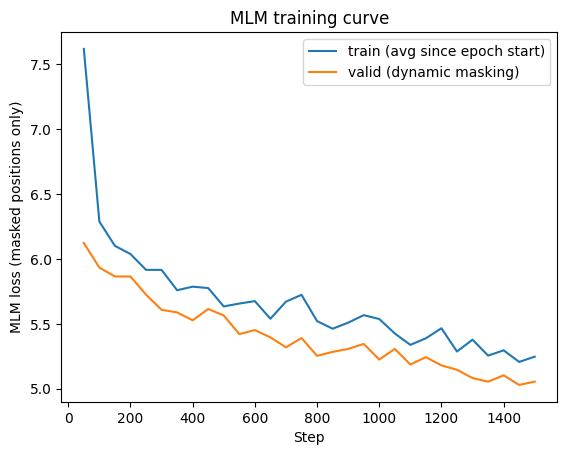

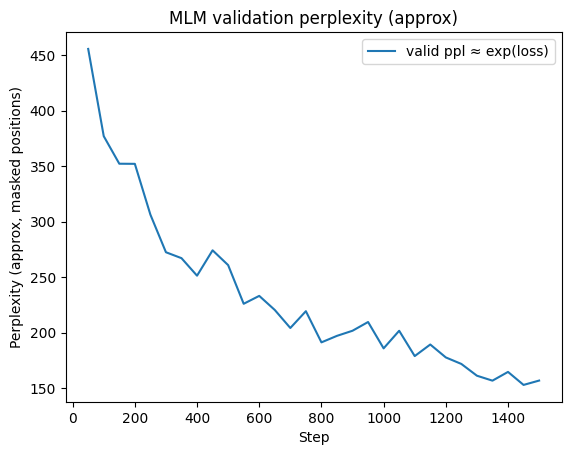

In [214]:
# Plot MLM curves only if you have already run training and produced `mlm_hist`.
# TODO: Run the training cell above to create `mlm_hist`, then re-run this cell.

df_mlm = pd.DataFrame(mlm_hist)

plt.figure()
plt.plot(df_mlm["step"], df_mlm["train_loss"], label="train (avg since epoch start)")
plt.plot(df_mlm["step"], df_mlm["valid_loss"], label="valid (dynamic masking)")
plt.xlabel("Step")
plt.ylabel("MLM loss (masked positions only)")
plt.title("MLM training curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(
    df_mlm["step"],
    [math.exp(min(x, 20)) for x in df_mlm["valid_loss"]],
    label="valid ppl ≈ exp(loss)"
)
plt.xlabel("Step")
plt.ylabel("Perplexity (approx, masked positions)")
plt.title("MLM validation perplexity (approx)")
plt.legend()
plt.show()

## TODO: Evaluate MLM Top-k Accuracy (masked positions only)

Compute masked-token Top-1 and Top-5 accuracy on the validation set to quantify how often the true token appears in the model’s top predictions.

In [215]:
@torch.no_grad()
def mlm_topk_acc(model, loader, k: int = 1, max_batches: int = 50):
    model.eval()

    correct = 0
    total = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        # move to device
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        # forward: [B, T, V]
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )

        # masked positions only
        mask = labels != cfg.ignore_index  # [B, T]
        if mask.sum().item() == 0:
            continue

        # top-k ids at each position: [B, T, k]
        topk_ids = logits.topk(k, dim=-1).indices

        # true labels expanded to compare against top-k: [B, T, 1]
        true = labels.unsqueeze(-1)

        # hits per position: [B, T]
        hit = (topk_ids == true).any(dim=-1)

        # count only masked positions
        correct += (hit & mask).sum().item()
        total += mask.sum().item()

    return correct / max(total, 1)


# compute and print Top-1 and Top-5 accuracy
top1 = mlm_topk_acc(mlm_model, mlm_valid_loader, k=1, max_batches=50)
top5 = mlm_topk_acc(mlm_model, mlm_valid_loader, k=5, max_batches=50)
print(f"Valid MLM masked top-1 acc: {top1:.4f}")
print(f"Valid MLM masked top-5 acc: {top5:.4f}")


Valid MLM masked top-1 acc: 0.2781
Valid MLM masked top-5 acc: 0.4427


## TODO: Visualize MLM Encoder Attention (single layer/head)

Extract and plot one attention head from a chosen encoder layer to inspect what tokens the model attends to during MLM pretraining.


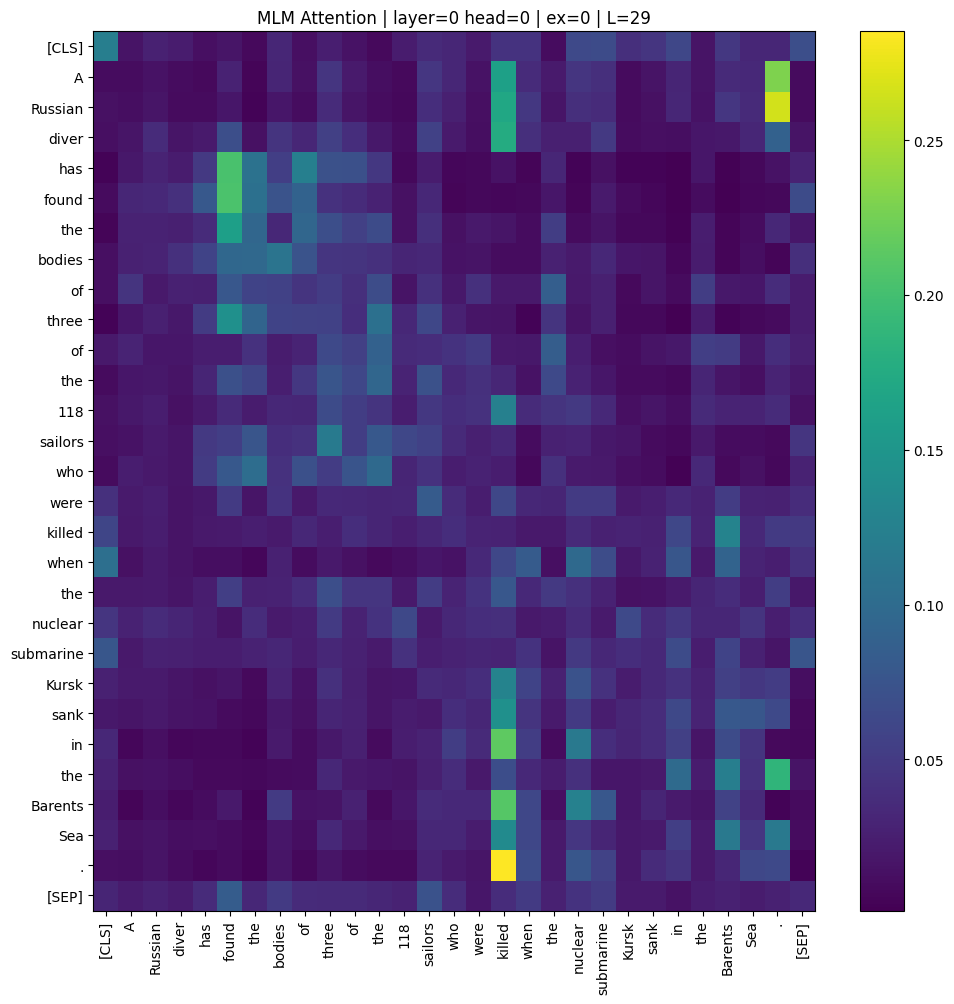

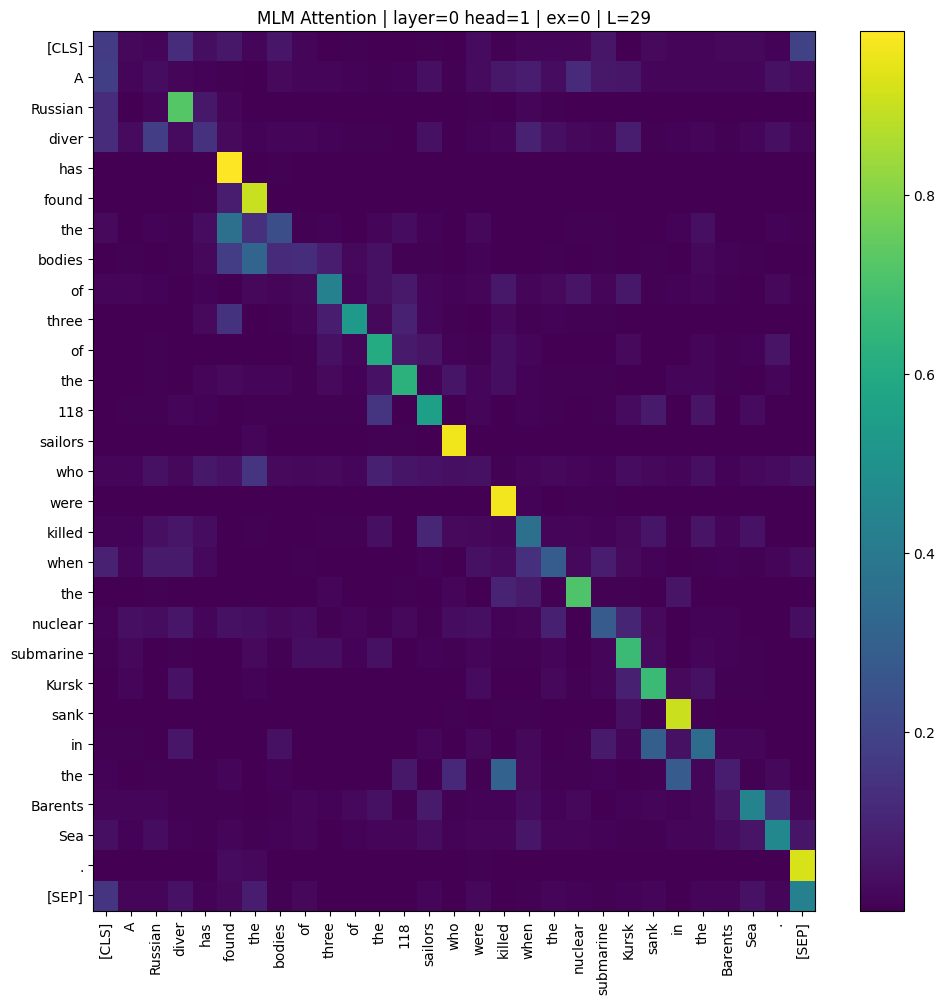

In [216]:
import matplotlib.pyplot as plt

@torch.no_grad()
def encoder_attention_map(
    model,
    loader,
    layer_to_show: int = 0,
    head_to_show: int = 0,
    ex_idx: int = 0,
    max_tokens: int = 40,
):
    model.eval()

    # 1) get one batch
    batch = next(iter(loader))

    # 2) move tensors to device
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    token_type_ids = batch.get("token_type_ids", None)
    position_ids = batch.get("position_ids", None)
    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(device)
    if position_ids is not None:
        position_ids = position_ids.to(device)

    # 3) choose example + real length (exclude padding)
    B = input_ids.size(0)
    ex_idx = int(ex_idx)
    if ex_idx < 0 or ex_idx >= B:
        ex_idx = 0

    L = int(attention_mask[ex_idx].sum().item())
    L = min(L, max_tokens)

    # 4) decode tokens for labels
    # Prefer the stored "tokens" list (it is already aligned to input_ids)
    tokens_list = batch.get("tokens", None)
    if tokens_list is not None and tokens_list[ex_idx] is not None:
        tok_labels = tokens_list[ex_idx][:L]
    else:
        # fallback: decode via itos
        ids = input_ids[ex_idx, :L].tolist()
        tok_labels = [ITOS.get(i, "<unk>") for i in ids]

    # 5) run model requesting attention from chosen layer
    # We support two common patterns:
    #   A) model.encoder.blocks[layer](..., return_attn=True)  (needs embeddings)
    #   B) model.encoder(..., return_attn_layer=layer) or model(..., return_attn_layer=layer)
    attn = None

    # Try: model.encoder forward that returns (h, attn) or just attn via return_attn_layer
    if hasattr(model, "encoder"):
        try:
            out = model.encoder(
                input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                position_ids=position_ids,
                return_attn_layer=layer_to_show,  # if your encoder supports it
            )
            # out could be (h, attn) or just h
            if isinstance(out, (tuple, list)) and len(out) == 2:
                _, attn = out
        except TypeError:
            # encoder might not support return_attn_layer; fall through
            pass

    # Try: full model forward with return_attn_layer
    if attn is None:
        try:
            out = model(
                input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                position_ids=position_ids,
                return_attn_layer=layer_to_show,
            )
            if isinstance(out, (tuple, list)) and len(out) == 2:
                _, attn = out
        except TypeError:
            pass

    # Last resort: manually run encoder blocks if they exist
    if attn is None and hasattr(model, "encoder") and hasattr(model.encoder, "emb") and hasattr(model.encoder, "blocks"):
        x = model.encoder.emb(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
        for li, blk in enumerate(model.encoder.blocks):
            if li == layer_to_show:
                x, attn = blk(x, attention_mask=attention_mask, return_attn=True)
            else:
                x = blk(x, attention_mask=attention_mask, return_attn=False)

    if attn is None:
        raise RuntimeError(
            "Could not extract attention. Your encoder/blocks must support returning attention "
            "(e.g., return_attn=True in a block or return_attn_layer in the model/encoder)."
        )

    # 6) normalize attention shape to [B, H, T, T]
    if attn.dim() == 3:          # [B, T, T] (single-head)
        attn = attn.unsqueeze(1) # [B, 1, T, T]
    elif attn.dim() != 4:
        raise RuntimeError(f"Unexpected attention shape: {tuple(attn.shape)}")

    # 7) select head + crop to [L, L]
    A = attn[ex_idx, head_to_show, :L, :L].detach().cpu().numpy()

    # 8) plot heatmap
    plt.figure(figsize=(max(6, 0.35 * L), max(5, 0.35 * L)))
    plt.imshow(A, aspect="auto")
    plt.colorbar()
    plt.xticks(range(L), tok_labels, rotation=90)
    plt.yticks(range(L), tok_labels)
    plt.title(f"MLM Attention | layer={layer_to_show} head={head_to_show} | ex={ex_idx} | L={L}")
    plt.tight_layout()
    plt.show()


# Example calls (same example/layer, two different heads)
encoder_attention_map(mlm_model, mlm_valid_loader, layer_to_show=0, head_to_show=0, ex_idx=0, max_tokens=30)
encoder_attention_map(mlm_model, mlm_valid_loader, layer_to_show=0, head_to_show=1, ex_idx=0, max_tokens=30)


## Concept Checks (answer in Markdown, no code)

1) **What is MLM actually optimizing?**  
Explain in words what the model is asked to predict, and why this is a self-supervised objective.

Masked Language Modeling trains the model to predict the original token at positions that were masked in the input, using context from surrounding tokens on both sides. It is self-supervised because the training targets (the true tokens) come directly from the raw text itself — no manual labels are needed.

2) **Dynamic masking vs. static masking:**  
What is dynamic masking, and why can it help training compared to precomputing a fixed masked dataset?


Dynamic masking means masked positions are randomly chosen each epoch/batch instead of being fixed beforehand. This helps training because the model sees many different masking patterns over time, improving generalization and preventing overfitting to one specific masked version of the dataset.

## Part 9 — Pretraining Objective #2: Next Sentence Prediction (NSP)

So far we trained a **masked language model (MLM)** that learns to recover missing tokens from context.  
In this part we add a second classic pretraining signal from the original BERT recipe: **Next Sentence Prediction (NSP)**.

### What we build
We will construct **sentence pairs**:
- **Sentence A** = a real sentence from the dataset
- **Sentence B** = either the *true next* sentence (**IsNext = 1**) or a *random* sentence from elsewhere (**NotNext = 0**)

Then we train a single encoder to solve **two tasks at once**:
1. **MLM**: predict masked tokens (token-level classification over the vocabulary)
2. **NSP**: predict whether B follows A (binary classification from the `[CLS]` representation)

### Why this matters
- MLM encourages **local, token-level semantic understanding**.
- NSP encourages the model to capture **sentence-to-sentence coherence** and discourse-level signals.
- Multi-task training forces the encoder to learn representations useful at different granularity levels.

## Build NSP sentence pairs
We create positive (next-sentence) and negative (random-sentence) pairs for the NSP objective.

In [217]:
class NSPPairDataset(Dataset):
    def __init__(self, hf_split, stoi: Dict[str, int], max_len: int = 256, p_is_next: float = 0.5):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len
        self.p_is_next = p_is_next
        self.n = len(hf_split)

    def _truncate_pair(self, a_tokens, b_tokens):
        # total length must fit: [CLS] A [SEP] B [SEP]
        max_pair = self.max_len - 3

        a = list(a_tokens)
        b = list(b_tokens)

        # Deterministic truncation: trim from the longer sequence until it fits
        while len(a) + len(b) > max_pair:
            if len(a) >= len(b):
                a.pop()
            else:
                b.pop()

        return a, b

    def __len__(self):
        return self.n - 1  # need idx+1 to exist for a true "next" example

    def __getitem__(self, idx):
        tokens_a = self.split[idx]["tokens"]

        # Decide whether this is a true-next pair
        if random.random() < self.p_is_next:
            tokens_b = self.split[idx + 1]["tokens"]
            is_next = 1
        else:
            # pick a random j not equal to idx or idx+1
            j = random.randrange(0, self.n)
            while j == idx or j == idx + 1:
                j = random.randrange(0, self.n)
            tokens_b = self.split[j]["tokens"]
            is_next = 0

        a, b = self._truncate_pair(tokens_a, tokens_b)

        return {
            "tokens_a": a,
            "tokens_b": b,
            "is_next": torch.tensor(is_next, dtype=torch.long),
        }



nsp_train_ds = NSPPairDataset(ds["train"], STOI, max_len=MAX_LEN_BERT, p_is_next=0.5)
nsp_valid_ds = NSPPairDataset(ds["validation"], STOI, max_len=MAX_LEN_BERT, p_is_next=0.5)

print("NSP train/valid:", len(nsp_train_ds), len(nsp_valid_ds))
ex0 = nsp_train_ds[0]
print("Example A:", ex0["tokens_a"][:10])
print("Example B:", ex0["tokens_b"][:10])
print("Label is_next:", int(ex0["is_next"].item()))

NSP train/valid: 59923 8527
Example A: ['People', 'start', 'their', 'own', 'businesses', 'for', 'many', 'reasons', '.']
Example B: ['However', 'we', "'re", 'the', 'first', 'to', 'admit', 'we', "'re", 'not']
Label is_next: 0


## Collate NSP pairs for MLM + NSP
Pack sentence pairs into one BERT-style sequence and prepare tensors needed for joint pretraining.

In [228]:
def nsp_mlm_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    # Build unpadded sequences first
    input_ids_list = []
    token_type_list = []
    is_next_list = []
    tokens_debug = []
    lengths = []

    for ex in batch:
        a = ex["tokens_a"]
        b = ex["tokens_b"]

        # NSP label (0/1)
        is_next_list.append(int(ex["is_next"]) if not torch.is_tensor(ex["is_next"]) else int(ex["is_next"].item()))

        # ---- build combined sequence: [CLS] A [SEP] B [SEP]
        toks = [BERT_CLS] + list(a) + [BERT_SEP] + list(b) + [BERT_SEP]
        tokens_debug.append(toks)

        # ---- map tokens -> ids (UNK fallback)
        ids = [STOI.get(t, UNK_ID) for t in toks]
        input_ids_list.append(ids)

        # ---- token_type_ids: 0 for [CLS] + A + [SEP], 1 for B + [SEP]
        # boundary index where segment B starts (the [SEP] after A is included in segment 0)
        b_start = 1 + len(a) + 1
        tt = [0] * b_start + [1] * (len(toks) - b_start)
        token_type_list.append(tt)

        lengths.append(len(ids))

    # ---- pad to max_len in this batch
    B = len(batch)
    max_len = max(lengths)

    input_ids = torch.full((B, max_len), PAD_ID, dtype=torch.long)
    token_type_ids = torch.zeros((B, max_len), dtype=torch.long)
    attention_mask = torch.zeros((B, max_len), dtype=torch.long)

    for i, (ids, tt, L) in enumerate(zip(input_ids_list, token_type_list, lengths)):
        input_ids[i, :L] = torch.tensor(ids, dtype=torch.long)
        token_type_ids[i, :L] = torch.tensor(tt, dtype=torch.long)
        attention_mask[i, :L] = 1

    # ---- position ids: 0..T-1 for each row
    position_ids = torch.arange(max_len, dtype=torch.long).unsqueeze(0).repeat(B, 1)

    # ---- apply MLM masking on-the-fly
    masked_input_ids, mlm_labels = mask_tokens_bert_style(
        input_ids=input_ids,
        attention_mask=attention_mask,
        mlm_prob=0.15,
    )

    return {
        "input_ids": masked_input_ids,                         # [B, T]
        "mlm_labels": mlm_labels,                              # [B, T]
        "nsp_labels": torch.tensor(is_next_list, dtype=torch.long),  # [B]
        "token_type_ids": token_type_ids,                      # [B, T]
        "position_ids": position_ids,                          # [B, T]
        "attention_mask": attention_mask,                      # [B, T]
        "tokens": tokens_debug,                                # list[list[str]]
        "lengths": torch.tensor(lengths, dtype=torch.long),     # [B]
    }


## Add an NSP head for joint MLM + NSP pretraining
Extend the MLM encoder with a small classifier on the `[CLS]` representation to predict whether sentence B follows sentence A.

In [229]:
# Note: You can modify this part if you need

class NSPHead(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.dense = nn.Linear(d_model, d_model)
        self.act = nn.Tanh()
        self.classifier = nn.Linear(d_model, 2)  # 0 = NotNext, 1 = IsNext
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, cls_hidden: torch.Tensor):
        x = self.act(self.dense(cls_hidden))
        return self.classifier(x)

class TinyBertForPretraining(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        d_model: int = 192,
        num_heads: int = 4,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.encoder = TinyBertEncoder(vocab_size, pad_id, d_model, num_heads, num_layers, dropout, max_len)

        tied = self.encoder.emb.token_embeddings
        self.mlm_head = MLMHead(d_model=d_model, vocab_size=vocab_size, tie_weights=tied)

        self.nsp_head = NSPHead(d_model=d_model)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )
        mlm_logits = self.mlm_head(h)
        cls_hidden = h[:, 0, :]
        nsp_logits = self.nsp_head(cls_hidden)
        return mlm_logits, nsp_logits

## Initialize the joint pretraining model (optional warm start)
Create the MLM+NSP model and (optionally) reuse the encoder/MLM weights learned in Part 8.

In [230]:
seed_everything(cfg.seed)

pretrain_model = TinyBertForPretraining(
    vocab_size=len(STOI),
    pad_id=PAD_ID,
    d_model=192,
    num_heads=4,
    num_layers=4,
    dropout=0.1,
    max_len=MAX_LEN_BERT,
).to(device)

if "mlm_model" in globals():
    print("Loading weights from Part 8 MLM model...")
    pretrain_model.encoder.load_state_dict(mlm_model.encoder.state_dict())
    pretrain_model.mlm_head.load_state_dict(mlm_model.mlm_head.state_dict(), strict=False)

print("Ready.")

Loading weights from Part 8 MLM model...
Ready.


## Joint Pretraining: Evaluation + Training Loop (MLM + NSP)
Implement the evaluation and training routines for the combined MLM+NSP objective, then track validation metrics during training.

In [237]:
@torch.no_grad()
def eval_pretrain(model, loader, max_batches: int = 100):
    """
    Evaluate a joint-pretraining model (MLM + NSP) on up to `max_batches`.

    Return a dict with:
      - "mlm_loss": average MLM loss over masked positions only
      - "nsp_loss": average NSP loss over examples
      - "nsp_acc" : NSP accuracy over examples
    """
    model.eval()

    total_mlm_loss_sum = 0.0
    total_mlm_masked = 0

    total_nsp_loss_sum = 0.0
    total_nsp_examples = 0
    nsp_correct = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        # move tensors to device
        input_ids = batch["input_ids"].to(device)
        mlm_labels = batch.get("mlm_labels", batch.get("labels")).to(device)  # support either key
        nsp_labels = batch.get("nsp_labels").to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        # forward pass (expects (mlm_logits, nsp_logits))
        mlm_logits, nsp_logits = model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )

        # MLM loss: sum over masked positions only (ignore_index elsewhere)
        B, T, V = mlm_logits.shape
        mlm_logits_flat = mlm_logits.view(B * T, V)
        mlm_labels_flat = mlm_labels.view(B * T)
        mlm_loss_sum = F.cross_entropy(
            mlm_logits_flat,
            mlm_labels_flat,
            ignore_index=cfg.ignore_index,
            reduction="sum",
        )
        n_masked = (mlm_labels_flat != cfg.ignore_index).sum().item()

        total_mlm_loss_sum += mlm_loss_sum.item()
        total_mlm_masked += n_masked

        # NSP loss: sum over examples
        nsp_loss_sum = F.cross_entropy(nsp_logits, nsp_labels, reduction="sum")
        total_nsp_loss_sum += nsp_loss_sum.item()
        total_nsp_examples += nsp_labels.numel()

        # NSP accuracy
        nsp_pred = nsp_logits.argmax(dim=-1)
        nsp_correct += (nsp_pred == nsp_labels).sum().item()

    return {
        "mlm_loss": total_mlm_loss_sum / max(total_mlm_masked, 1),
        "nsp_loss": total_nsp_loss_sum / max(total_nsp_examples, 1),
        "nsp_acc": nsp_correct / max(total_nsp_examples, 1),
    }


In [239]:
def train_pretrain(
    model, train_loader, valid_loader,
    lr: float = 5e-4, weight_decay: float = 0.02,
    max_steps: int = 300, log_every: int = 50,
    grad_clip: float = 1.0, valid_batches: int = 100
):
    """
    Train joint-pretraining model with loss = MLM_loss + NSP_loss.

    Track:
      - training running averages (mlm, nsp)
      - validation metrics via eval_pretrain()
      - optional: validation MLM perplexity ~ exp(mlm_loss)
    """
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "step": [],
        "train_mlm": [],
        "train_nsp": [],
        "valid_mlm": [],
        "valid_nsp": [],
        "valid_nsp_acc": [],
        "valid_mlm_ppl": [],
    }

    # running accumulators
    running_mlm = 0.0
    running_nsp = 0.0
    running_n = 0
    step = 0

    model.train()

    for batch in train_loader:
        if step >= max_steps:
            break

        # move tensors to device
        input_ids = batch["input_ids"].to(device)
        mlm_labels = batch.get("mlm_labels", batch.get("labels")).to(device)  # support either key
        nsp_labels = batch["nsp_labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        # zero grads
        opt.zero_grad(set_to_none=True)

        # forward
        mlm_logits, nsp_logits = model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )

        # losses
        mlm_loss = mlm_loss_mean(mlm_logits, mlm_labels)  # mean over masked positions only
        nsp_loss = F.cross_entropy(nsp_logits, nsp_labels)  # mean over batch
        total_loss = mlm_loss + nsp_loss

        # backward + clip + step
        total_loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        # update running
        running_mlm += float(mlm_loss.item())
        running_nsp += float(nsp_loss.item())
        running_n += 1
        step += 1

        # logging + validation
        if step % log_every == 0:
            train_mlm_avg = running_mlm / max(running_n, 1)
            train_nsp_avg = running_nsp / max(running_n, 1)

            val = eval_pretrain(model, valid_loader, max_batches=valid_batches)
            val_mlm = float(val["mlm_loss"])
            val_nsp = float(val["nsp_loss"])
            val_acc = float(val["nsp_acc"])
            val_ppl = math.exp(min(val_mlm, 20.0))

            history["step"].append(step)
            history["train_mlm"].append(train_mlm_avg)
            history["train_nsp"].append(train_nsp_avg)
            history["valid_mlm"].append(val_mlm)
            history["valid_nsp"].append(val_nsp)
            history["valid_nsp_acc"].append(val_acc)
            history["valid_mlm_ppl"].append(val_ppl)

            print(
                f"step={step:>5d} | "
                f"train_mlm={train_mlm_avg:.4f} train_nsp={train_nsp_avg:.4f} | "
                f"val_mlm={val_mlm:.4f} val_ppl≈{val_ppl:.1f} | "
                f"val_nsp={val_nsp:.4f} val_nsp_acc={val_acc:.3f}"
            )

            # reset running accumulators
            running_mlm = 0.0
            running_nsp = 0.0
            running_n = 0

    return model, history


In [241]:
# NSP + MLM joint loaders

nsp_train_loader = DataLoader(
    nsp_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=nsp_mlm_collate_fn,
)

nsp_valid_loader = DataLoader(
    nsp_valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=nsp_mlm_collate_fn,
)

# quick sanity check
b = next(iter(nsp_train_loader))
{k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in b.items()}

# Evaluate before training

print("Initial valid metrics:", eval_pretrain(pretrain_model, nsp_valid_loader, max_batches=100))

# Train for ~1 epoch worth of steps (or as configured)
pretrain_model, hist9 = train_pretrain(
    pretrain_model,
    nsp_train_loader,
    nsp_valid_loader,
    max_steps=len(nsp_train_loader) + 1,
    log_every=50,
)

# Evaluate after training
print("Final valid metrics:", eval_pretrain(pretrain_model, nsp_valid_loader, max_batches=100))

Initial valid metrics: {'mlm_loss': 5.39809927225263, 'nsp_loss': 0.7405358338356018, 'nsp_acc': 0.5059375}
step=   50 | train_mlm=5.3985 train_nsp=0.7103 | val_mlm=5.1866 val_ppl≈178.9 | val_nsp=0.6690 val_nsp_acc=0.579
step=  100 | train_mlm=5.1859 train_nsp=0.6801 | val_mlm=5.1110 val_ppl≈165.8 | val_nsp=0.6786 val_nsp_acc=0.500
step=  150 | train_mlm=5.1281 train_nsp=0.6499 | val_mlm=5.0764 val_ppl≈160.2 | val_nsp=0.7063 val_nsp_acc=0.557
step=  200 | train_mlm=5.0918 train_nsp=0.6131 | val_mlm=5.0179 val_ppl≈151.1 | val_nsp=0.6653 val_nsp_acc=0.564
step=  250 | train_mlm=4.9809 train_nsp=0.6653 | val_mlm=4.9776 val_ppl≈145.1 | val_nsp=0.6785 val_nsp_acc=0.487
step=  300 | train_mlm=4.9778 train_nsp=0.6327 | val_mlm=4.9355 val_ppl≈139.1 | val_nsp=0.6699 val_nsp_acc=0.511
step=  350 | train_mlm=4.9300 train_nsp=0.6160 | val_mlm=4.8808 val_ppl≈131.7 | val_nsp=0.6518 val_nsp_acc=0.581
step=  400 | train_mlm=4.9353 train_nsp=0.6189 | val_mlm=4.8256 val_ppl≈124.7 | val_nsp=0.6290 val_ns

## Visualize MLM + NSP Pretraining Curves
Plot the logged training/validation MLM loss, NSP loss/accuracy, and MLM perplexity as a function of update steps.

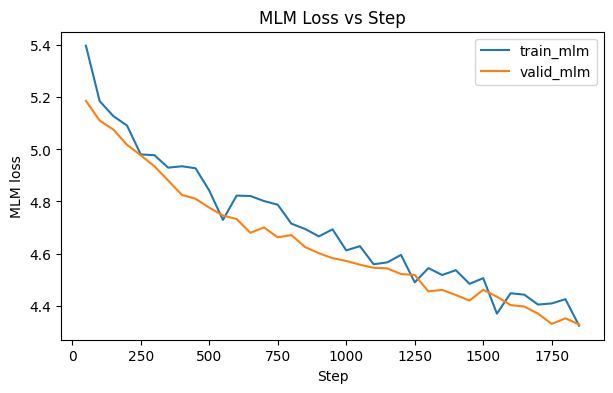

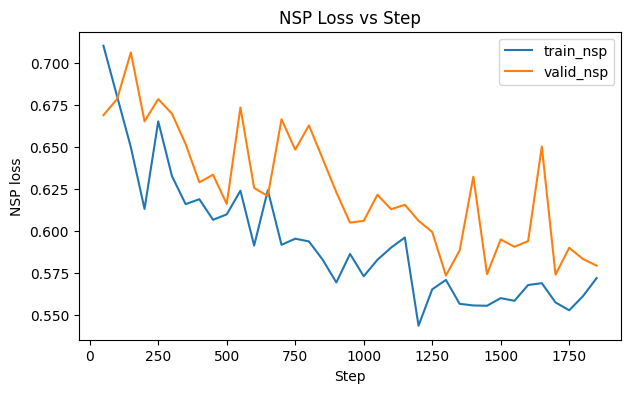

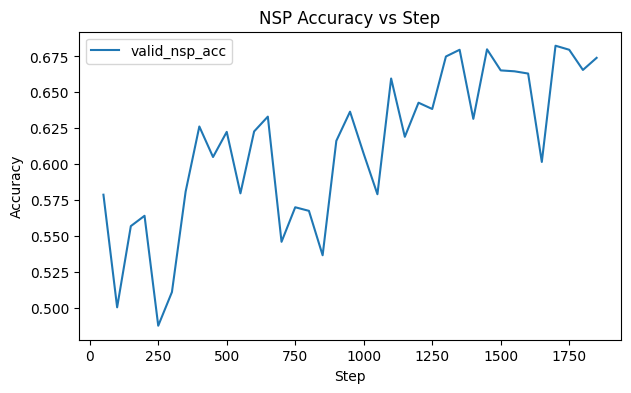

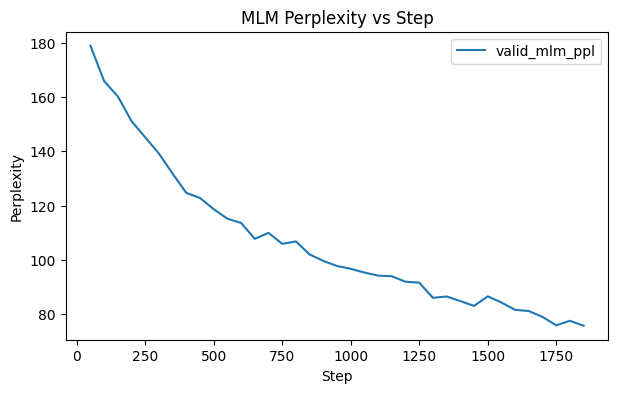

In [242]:
import matplotlib.pyplot as plt

# pick your history dict name
history = hist9

steps = history["step"]

# --- MLM loss (train vs valid) ---
plt.figure(figsize=(7,4))
plt.plot(steps, history["train_mlm"], label="train_mlm")
plt.plot(steps, history["valid_mlm"], label="valid_mlm")
plt.xlabel("Step")
plt.ylabel("MLM loss")
plt.title("MLM Loss vs Step")
plt.legend()
plt.show()

# --- NSP loss (train vs valid) ---
plt.figure(figsize=(7,4))
plt.plot(steps, history["train_nsp"], label="train_nsp")
plt.plot(steps, history["valid_nsp"], label="valid_nsp")
plt.xlabel("Step")
plt.ylabel("NSP loss")
plt.title("NSP Loss vs Step")
plt.legend()
plt.show()

# --- NSP accuracy (valid) ---
plt.figure(figsize=(7,4))
plt.plot(steps, history["valid_nsp_acc"], label="valid_nsp_acc")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("NSP Accuracy vs Step")
plt.legend()
plt.show()

# --- MLM perplexity (valid) ---
plt.figure(figsize=(7,4))
plt.plot(steps, history["valid_mlm_ppl"], label="valid_mlm_ppl")
plt.xlabel("Step")
plt.ylabel("Perplexity")
plt.title("MLM Perplexity vs Step")
plt.legend()
plt.show()


## Inspect One NSP Pair (Qualitative Check)
Take one batch from the NSP validation loader, split it into sentence A/B using `[SEP]`, and print the NSP label + tokens.

In [243]:
# TODO: Pull one batch from nsp_valid_loader
batch = next(iter(nsp_valid_loader))

# TODO: Pick an example index inside the batch (e.g., 0)
idx = 0

# TODO: Extract tokens, token_type_ids, attention_mask, and the NSP label
tokens = batch["tokens"][idx]
token_type_ids = batch["token_type_ids"][idx].tolist()
attention_mask = batch["attention_mask"][idx].tolist()
nsp_label = int(batch["nsp_labels"][idx].item())  # 1 = isNext, 0 = notNext

# TODO: Compute the real length L from attention_mask and truncate everything to L
L = int(sum(attention_mask))
tokens = tokens[:L]
token_type_ids = token_type_ids[:L]

# TODO: Split tokens into sentence A and B (use the first [SEP] as the separator)
try:
    sep_i = tokens.index(BERT_SEP)  # first [SEP]
except ValueError:
    sep_i = None

if sep_i is None:
    sent_a = tokens
    sent_b = []
else:
    # sequence is: [CLS] A [SEP] B [SEP]
    sent_a = tokens[1:sep_i]                 # drop [CLS], stop before first [SEP]
    sent_b = tokens[sep_i + 1 : -1] if tokens[-1] == BERT_SEP else tokens[sep_i + 1 :]

# TODO: Print the label and the (truncated) sentences
print("NSP label:", nsp_label, "(1=isNext, 0=notNext)")
print("Sentence A:", sent_a)
print("Sentence B:", sent_b)


NSP label: 0 (1=isNext, 0=notNext)
Sentence A: ['A', 'Russian', 'diver', 'has', 'found', 'the', 'bodies', 'of', 'three', 'of', 'the', '118', 'sailors', 'who', 'were', 'killed', 'when', 'the', 'nuclear', 'submarine', 'Kursk', 'sank', 'in', 'the', 'Barents', 'Sea', '.']
Sentence B: ['On', 'the', '20th', 'he', 'flew', 'across', 'the', 'Atlantic', 'Ocean', 'to', 'Gambia', 'to', 'meet', 'with', 'Gambian', 'President', 'Yahya', 'Jameh', 'before', 'heading', 'on', 'to', 'Burkina', 'Faso', 'and', 'a', 'dinner', 'with', 'President', 'Blaise', 'Compaore', '.']


## Concept Checks (answer in Markdown, no code)

1. **Data construction:**  
   In our NSP dataset, how are positive pairs (IsNext) and negative pairs (NotNext) created?  
   What role does `p_is_next` play?

Positive pairs (IsNext=1): Sentence B is the actual next sentence following sentence A in the dataset (index i+1).

Negative pairs (NotNext=0): Sentence B is a random sentence sampled from elsewhere in the dataset (not the true next one).

Role of p_is_next: It controls the probability of creating a positive pair.

With probability p_is_next → choose true next sentence (label = 1).

Otherwise → choose random sentence (label = 0).
This keeps the dataset balanced between positive and negative examples

2. **Loss design:**  
   We train with a combined loss:

   $$
   \mathcal{L} = \mathcal{L}_{\mathrm{MLM}} + \mathcal{L}_{\mathrm{NSP}}.
   $$

   What does each term supervise, and which model outputs are used to compute them?

MLM loss (L_MLM):

Supervises prediction of masked tokens.

Uses MLM logits [B,T,V] (vocab predictions per token).

Computed only on masked positions using cross-entropy vs true token IDs.

NSP loss (L_NSP):

Supervises whether sentence B follows sentence A.

Uses NSP logits [B,2] from the [CLS] representation.

Computed with binary cross-entropy (IsNext vs NotNext).

# Part 10 — Fine-tuning Results

In Parts 8–9 we trained the same tiny BERT-style encoder with self-supervised objectives (MLM, then MLM+NSP).  
In this part we **fine-tune for NER** and compare three initializations:

- **Scratch:** encoder starts from random weights.
- **MLM-init:** encoder starts from the Part 8 MLM-pretrained weights.
- **MLM+NSP-init:** encoder starts from the Part 9 MLM+NSP-pretrained weights.

We will evaluate each run with the same NER metrics (loss, token accuracy, and entity-level precision/recall/F1) and then do a small qualitative check by printing token-level predictions for one validation example.

## Select a Compatible Vocabulary for Fine-Tuning  
We must ensure the fine-tuning vocabulary size matches the encoder’s token embedding table to avoid shape-mismatch errors.


In [244]:
def pick_vocab_for_encoder():
    """
    Returns (FT_STOI, FT_ITOS) such that len(FT_STOI) matches the encoder vocab size.
    Priority:
      1) If pretrain_model exists -> match its encoder embedding size
      2) elif mlm_model exists -> match its encoder embedding size
      3) else fallback to (stoi, itos)
    """
    # candidates we might have
    candidates = []
    if "mlm_stoi" in globals() and "mlm_itos" in globals():
        candidates.append(("mlm", mlm_stoi, mlm_itos))
    if "stoi" in globals() and "itos" in globals():
        candidates.append(("ner", stoi, itos))

    # determine target vocab size
    target = None
    if "pretrain_model" in globals():
        target = pretrain_model.encoder.emb.token_embeddings.num_embeddings
        src = "pretrain_model"
    elif "mlm_model" in globals():
        target = mlm_model.encoder.emb.token_embeddings.num_embeddings
        src = "mlm_model"
    else:
        target = None
        src = "none"

    if target is None:
        print("No pretrained encoder found; using (stoi, itos).")
        return stoi, itos

    for name, S, I in candidates:
        if len(S) == target:
            print(f"Using vocab '{name}' because it matches encoder vocab_size={target} (source={src}).")
            return S, I

    # If none match, fail loudly with a helpful message
    raise ValueError(
        f"No available vocab matches encoder vocab size={target}. "
        f"Available sizes: {[ (name, len(S)) for name,S,_ in candidates ]}. "
        f"Fix by using the same vocab in Parts 8–10."
    )

FT_STOI, FT_ITOS = pick_vocab_for_encoder()

FT_PAD_ID  = FT_STOI[cfg.pad_token]
FT_UNK_ID  = FT_STOI[cfg.unk_token]
FT_CLS_ID  = FT_STOI[BERT_CLS]
FT_SEP_ID  = FT_STOI[BERT_SEP]

Using vocab 'ner' because it matches encoder vocab_size=20606 (source=pretrain_model).


## NER Dataset with BERT-Style Special Tokens  
Wrap each sentence as `[CLS] tokens [SEP]` and align labels by ignoring the special-token positions.

In [256]:
class NERBertInputDataset(Dataset):
    def __init__(self, hf_split, stoi: Dict[str,int], max_len: int = 256):
        self.split = hf_split
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.split)

    def __getitem__(self, idx):
        ex = self.split[idx]
        tokens = ex["tokens"]
        labels = ex["ner_tags"]

        # Fit: [CLS] + tokens + [SEP]
        max_tokens = self.max_len - 2
        tokens = tokens[:max_tokens]
        labels = labels[:max_tokens]

        bert_tokens = [BERT_CLS] + tokens + [BERT_SEP]
        input_ids = [self.stoi.get(t, self.stoi[cfg.unk_token]) for t in bert_tokens]

        # Labels: ignore CLS and SEP positions
        bert_labels = [cfg.ignore_index] + labels + [cfg.ignore_index]

        token_type_ids = [0] * len(input_ids)  # single segment

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
            "labels": torch.tensor(bert_labels, dtype=torch.long),
            "tokens": bert_tokens,
        }

## Collate Function + Fine-tuning DataLoaders  
Implement padding + attention masks (and position ids) to build BERT-style batches for NER fine-tuning.

In [260]:
from typing import List, Dict
import torch
from torch.utils.data import DataLoader


ft_train_ds = NERBertInputDataset(ds["train"], FT_STOI, max_len=MAX_LEN_BERT)
ft_valid_ds = NERBertInputDataset(ds["validation"], FT_STOI, max_len=MAX_LEN_BERT)
ft_test_ds  = NERBertInputDataset(ds["test"], FT_STOI, max_len=MAX_LEN_BERT)

def bert_ner_collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    # Original lengths (before padding)
    lengths = [ex["input_ids"].shape[0] for ex in batch]
    max_len = max(lengths)
    B = len(batch)

    # Allocate padded tensors
    input_ids = torch.full((B, max_len), fill_value=FT_PAD_ID, dtype=torch.long)
    token_type_ids = torch.zeros((B, max_len), dtype=torch.long)
    attention_mask = torch.zeros((B, max_len), dtype=torch.long)
    labels = torch.full((B, max_len), fill_value=cfg.ignore_index, dtype=torch.long)

    tokens_list = []
    for i, ex in enumerate(batch):
        L = ex["input_ids"].shape[0]
        input_ids[i, :L] = ex["input_ids"]
        token_type_ids[i, :L] = ex["token_type_ids"]
        attention_mask[i, :L] = 1
        labels[i, :L] = ex["labels"]
        tokens_list.append(ex.get("tokens", None))

    # position ids: 0..T-1 for each example
    position_ids = torch.arange(max_len, dtype=torch.long).unsqueeze(0).repeat(B, 1)

    return {
        "input_ids": input_ids,
        "token_type_ids": token_type_ids,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "tokens": tokens_list,
        "lengths": torch.tensor(lengths, dtype=torch.long),
    }


# ---- Build loaders for fine-tuning ----
ft_train_loader = DataLoader(
    ft_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

ft_valid_loader = DataLoader(
    ft_valid_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

ft_test_loader = DataLoader(
    ft_test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=bert_ner_collate_fn,
)

# ---- Sanity check ----
b = next(iter(ft_train_loader))
print({k: (v.shape if torch.is_tensor(v) else type(v)) for k, v in b.items()})
print("lengths:", b["lengths"][:5].tolist())
print("attention sums:", b["attention_mask"].sum(dim=1)[:5].tolist())


{'input_ids': torch.Size([32, 42]), 'token_type_ids': torch.Size([32, 42]), 'position_ids': torch.Size([32, 42]), 'attention_mask': torch.Size([32, 42]), 'labels': torch.Size([32, 42]), 'tokens': <class 'list'>, 'lengths': torch.Size([32])}
lengths: [3, 8, 33, 15, 30]
attention sums: [3, 8, 33, 15, 30]


## Token Classification Head  
Wrap an encoder with a dropout + linear layer to predict a NER label for every token.

In [267]:
class TinyBertForTokenClassification(nn.Module):
    def __init__(self, encoder: nn.Module, d_model: int, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, position_ids=None):
        h = self.encoder(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )
        logits = self.classifier(self.drop(h))
        return logits  # [B,T,C]

## Fine-tuning Loops (Train + Evaluate)  
Implement the training and evaluation routines for token-level classification during fine-tuning.

In [268]:
@torch.no_grad()
def evaluate_ner_ft(model, loader):
    model.eval()

    total_loss_sum = 0.0
    total_tokens = 0

    token_correct = 0
    token_total = 0

    y_true_all = []
    y_pred_all = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        logits = model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )  # [B,T,C]
        preds = logits.argmax(dim=-1)  # [B,T]

        # token-weighted loss accumulation (ignores cfg.ignore_index inside helper)
        loss_sum, n_tokens = loss_sum_and_tokens(logits, labels)
        total_loss_sum += float(loss_sum.item())
        total_tokens += int(n_tokens)

        # token accuracy on non-ignored labels
        mask = labels != cfg.ignore_index
        token_correct += ((preds == labels) & mask).sum().item()
        token_total += mask.sum().item()

        # seqeval entity-level metrics
        y_true, y_pred = ids_to_tags(labels, preds)
        y_true_all.extend(y_true)
        y_pred_all.extend(y_pred)

    return {
        "loss": total_loss_sum / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }


def train_one_epoch_ner_ft(model, loader, optimizer, grad_clip=1.0):
    model.train()

    total_loss_sum = 0.0
    total_tokens = 0

    for batch in tqdm(loader, desc="FT Train", leave=False):
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        position_ids = batch["position_ids"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
        )

        loss = loss_mean(logits, labels)  # mean over real (non-ignore_index) tokens
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        # token-weighted loss tracking (so epoch avg is per real token)
        loss_sum, n_tokens = loss_sum_and_tokens(logits.detach(), labels)
        total_loss_sum += float(loss_sum.item())
        total_tokens += int(n_tokens)

    return total_loss_sum / max(total_tokens, 1)


## Infer Encoder Hyperparameters from Pretraining  
Automatically detect the encoder’s shape (dimension/length/depth) so fine-tuning matches the pretrained weights.

In [270]:
# Infer encoder config (d_model, heads, layers, max_len) from pretrained if possible
ENC_D_MODEL = 192
ENC_HEADS = 4
ENC_LAYERS = 4
ENC_MAXLEN = MAX_LEN_BERT

if "pretrain_model" in globals():
    ENC_D_MODEL = pretrain_model.encoder.emb.token_embeddings.embedding_dim
    ENC_MAXLEN  = pretrain_model.encoder.emb.position_embeddings.num_embeddings
    ENC_LAYERS  = len(pretrain_model.encoder.blocks)
elif "mlm_model" in globals():
    ENC_D_MODEL = mlm_model.encoder.emb.token_embeddings.embedding_dim
    ENC_MAXLEN  = mlm_model.encoder.emb.position_embeddings.num_embeddings
    ENC_LAYERS  = len(mlm_model.encoder.blocks)

## Fine-tuning Experiment Helper Function  
Implement one end-to-end fine-tuning run (init → train/early-stop → test) so we can compare scratch vs. pretrained encoders fairly.

In [276]:
import copy

def finetune_experiment(
    init_name: str,
    encoder_init: str,
    d_model: int,
    lr: float = 3e-4,
    wd: float = 0.01,
    epochs: int = 5,
    patience: int = 2
):
    """
    Run ONE fine-tuning experiment for token classification (NER).

    encoder_init options:
      - "scratch"  : randomly initialized encoder
      - "mlm"      : initialize encoder from Part 8 MLM (requires mlm_model)
      - "mlm_nsp"  : initialize encoder from Part 9 MLM+NSP (requires pretrain_model)

    Returns:
      model, hist, best_val_f1, test_metrics
    """
    seed_everything(cfg.seed)

    vocab_size = len(FT_STOI)
    pad_id = FT_PAD_ID

    # ------------------------------------------------------------
    # 1) Build encoder
    # ------------------------------------------------------------
    if encoder_init == "scratch":
        encoder = TinyBertEncoder(
            vocab_size=vocab_size,
            pad_id=pad_id,
            d_model=d_model,
            num_heads=ENC_HEADS,
            num_layers=ENC_LAYERS,
            dropout=0.1,
            max_len=ENC_MAXLEN,
        )

    elif encoder_init == "mlm":
        if "mlm_model" not in globals():
            raise ValueError("encoder_init='mlm' but mlm_model is not defined.")
        encoder = TinyBertEncoder(
            vocab_size=vocab_size,
            pad_id=pad_id,
            d_model=ENC_D_MODEL,
            num_heads=ENC_HEADS,
            num_layers=ENC_LAYERS,
            dropout=0.1,
            max_len=ENC_MAXLEN,
        )
        # load pretrained encoder weights
        encoder.load_state_dict(mlm_model.encoder.state_dict(), strict=True)
        d_model = ENC_D_MODEL  # ensure head matches encoder dim

    elif encoder_init == "mlm_nsp":
        if "pretrain_model" not in globals():
            raise ValueError("encoder_init='mlm_nsp' but pretrain_model is not defined.")
        encoder = TinyBertEncoder(
            vocab_size=vocab_size,
            pad_id=pad_id,
            d_model=ENC_D_MODEL,
            num_heads=ENC_HEADS,
            num_layers=ENC_LAYERS,
            dropout=0.1,
            max_len=ENC_MAXLEN,
        )
        encoder.load_state_dict(pretrain_model.encoder.state_dict(), strict=True)
        d_model = ENC_D_MODEL

    else:
        raise ValueError(f"unknown encoder_init: {encoder_init}")

    encoder = encoder.to(device)

    # ------------------------------------------------------------
    # 2) Wrap with token classification head
    # ------------------------------------------------------------
    model = TinyBertForTokenClassification(
        encoder=encoder,
        d_model=d_model,
        num_labels=num_labels,
        dropout=0.1,
    ).to(device)

    # ------------------------------------------------------------
    # 3) Optimizer
    # ------------------------------------------------------------
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    # ------------------------------------------------------------
    # 4) Train loop + early stopping on val F1
    # ------------------------------------------------------------
    best_val_f1 = -1.0
    best_state = None
    bad_epochs = 0

    hist = {"train_loss": [], "val_loss": [], "val_f1": []}

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch_ner_ft(model, ft_train_loader, optimizer, grad_clip=1.0)
        val_metrics = evaluate_ner_ft(model, ft_valid_loader)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_metrics["loss"])
        hist["val_f1"].append(val_metrics["f1"])

        print(
            f"{init_name} | ep {ep:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_token_acc={val_metrics['token_acc']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1 + 1e-6:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"{init_name} | early stopping (best val_f1={best_val_f1:.4f})")
                break

    if best_state is None:
        # should be rare, but keeps things safe
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # ------------------------------------------------------------
    # 5) Load best + test eval
    # ------------------------------------------------------------
    model.load_state_dict(best_state, strict=True)
    test_metrics = evaluate_ner_ft(model, ft_test_loader)

    print(
        f"{init_name} | TEST | "
        f"loss={test_metrics['loss']:.4f} | "
        f"token_acc={test_metrics['token_acc']:.4f} | "
        f"precision={test_metrics['precision']:.4f} | "
        f"recall={test_metrics['recall']:.4f} | "
        f"f1={test_metrics['f1']:.4f}"
    )

    return model, hist, best_val_f1, test_metrics


## Fine-tuning Comparison (Scratch vs. Pretraining)  
Run the same NER fine-tuning pipeline with different encoder initializations and summarize results in one table.

In [277]:
import pandas as pd

# ------------------------------------------------------------
# Choose a d_model compatible with the encoder you will fine-tune.
# ------------------------------------------------------------
if "pretrain_model" in globals():
    D_MODEL = pretrain_model.encoder.emb.token_embeddings.embedding_dim
    print("Using D_MODEL from pretrain_model:", D_MODEL)
elif "mlm_model" in globals():
    D_MODEL = mlm_model.encoder.emb.token_embeddings.embedding_dim
    print("Using D_MODEL from mlm_model:", D_MODEL)
else:
    # must match your scratch encoder config
    D_MODEL = ENC_D_MODEL if "ENC_D_MODEL" in globals() else 192
    print("No pretrained model found; using default D_MODEL:", D_MODEL)

# ------------------------------------------------------------
# Fine-tuning hyperparameters (keep identical across runs)
# ------------------------------------------------------------
LR = 3e-4
WD = 0.01
EPOCHS = 5
PATIENCE = 2

results = []

# ------------------------------------------------------------
# Experiment 1 — Scratch initialization
# ------------------------------------------------------------
scratch_model, scratch_hist, scratch_best_val_f1, scratch_test = finetune_experiment(
    init_name="Scratch",
    encoder_init="scratch",
    d_model=D_MODEL,
    lr=LR,
    wd=WD,
    epochs=EPOCHS,
    patience=PATIENCE,
)
results.append({
    "Init": "Scratch",
    "Best Val F1": float(scratch_best_val_f1),
    "Test F1": float(scratch_test["f1"]),
    "Test Loss": float(scratch_test["loss"]),
})

# ------------------------------------------------------------
# Experiment 2 — MLM initialization (only if Part 8 was run)
# ------------------------------------------------------------
if "mlm_model" in globals():
    mlm_init_model, mlm_init_hist, mlm_init_best_val_f1, mlm_init_test = finetune_experiment(
        init_name="MLM-init",
        encoder_init="mlm",
        d_model=D_MODEL,          # will be overridden inside finetune_experiment if needed
        lr=LR,
        wd=WD,
        epochs=EPOCHS,
        patience=PATIENCE,
    )
    results.append({
        "Init": "MLM-init",
        "Best Val F1": float(mlm_init_best_val_f1),
        "Test F1": float(mlm_init_test["f1"]),
        "Test Loss": float(mlm_init_test["loss"]),
    })
else:
    print("Skipping MLM-init: mlm_model not found.")

# ------------------------------------------------------------
# Experiment 3 — MLM+NSP initialization (only if Part 9 was run)
# ------------------------------------------------------------
if "pretrain_model" in globals():
    nsp_init_model, nsp_init_hist, nsp_init_best_val_f1, nsp_init_test = finetune_experiment(
        init_name="MLM+NSP-init",
        encoder_init="mlm_nsp",
        d_model=D_MODEL,          # will be overridden inside finetune_experiment if needed
        lr=LR,
        wd=WD,
        epochs=EPOCHS,
        patience=PATIENCE,
    )
    results.append({
        "Init": "MLM+NSP-init",
        "Best Val F1": float(nsp_init_best_val_f1),
        "Test F1": float(nsp_init_test["f1"]),
        "Test Loss": float(nsp_init_test["loss"]),
    })
else:
    print("Skipping MLM+NSP-init: pretrain_model not found.")

# ------------------------------------------------------------
# DataFrame summary sorted by Test F1 (descending)
# Columns: ["Init", "Best Val F1", "Test F1", "Test Loss"]
# ------------------------------------------------------------
res_df = pd.DataFrame(results, columns=["Init", "Best Val F1", "Test F1", "Test Loss"])
res_df = res_df.sort_values("Test F1", ascending=False).reset_index(drop=True)
display(res_df)


Using D_MODEL from pretrain_model: 192


Scratch | ep 01 | train_loss=0.3894 | val_loss=0.2968 | val_token_acc=0.9130 | val_f1=0.3742


Scratch | ep 02 | train_loss=0.2649 | val_loss=0.2787 | val_token_acc=0.9171 | val_f1=0.4368


Scratch | ep 03 | train_loss=0.2165 | val_loss=0.2742 | val_token_acc=0.9191 | val_f1=0.4491


Scratch | ep 04 | train_loss=0.1837 | val_loss=0.2808 | val_token_acc=0.9208 | val_f1=0.4651


...

MLM+NSP-init | ep 02 | train_loss=0.2594 | val_loss=0.2644 | val_token_acc=0.9204 | val_f1=0.4557


MLM+NSP-init | ep 03 | train_loss=0.2213 | val_loss=0.2597 | val_token_acc=0.9220 | val_f1=0.4644


MLM+NSP-init | ep 04 | train_loss=0.1928 | val_loss=0.2637 | val_token_acc=0.9239 | val_f1=0.4861


MLM+NSP-init | ep 05 | train_loss=0.1697 | val_loss=0.2843 | val_token_acc=0.9191 | val_f1=0.4739
MLM+NSP-init | TEST | loss=0.2556 | token_acc=0.9265 | precision=0.4890 | recall=0.5106 | f1=0.4996


,Init,Best Val F1,Test F1,Test Loss
0,MLM+NSP-init,0.486122,0.499565,0.255616
1,MLM-init,0.478815,0.484345,0.266954
2,Scratch,0.465149,0.471736,0.273677


## Training Curves  
Plot train/validation loss curves to compare convergence across different initialization strategies.

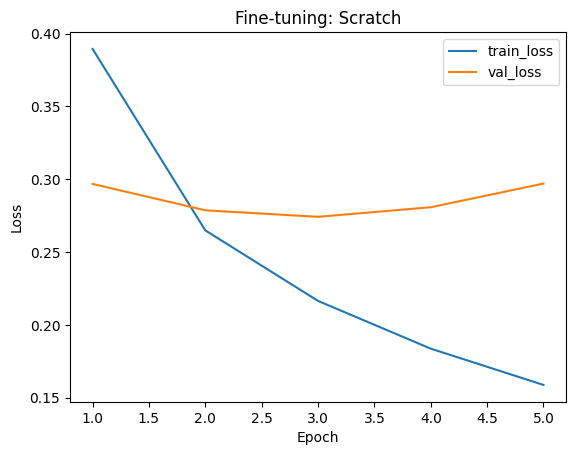

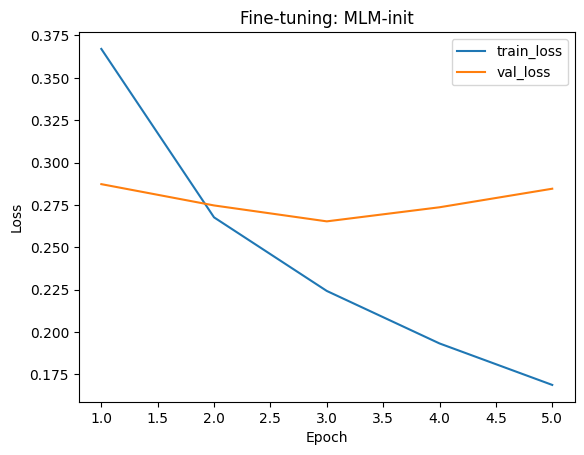

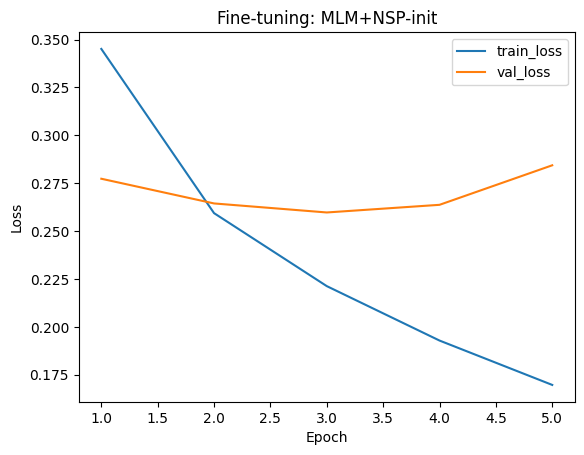

In [278]:
import matplotlib.pyplot as plt

def plot_hist(hist, title: str):
    train_loss = hist.get("train_loss", [])
    val_loss   = hist.get("val_loss", [])
    n = min(len(train_loss), len(val_loss))
    epochs = list(range(1, n + 1))

    plt.figure()
    plt.plot(epochs, train_loss[:n], label="train_loss")
    plt.plot(epochs, val_loss[:n], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

# 2) Plot Scratch always
plot_hist(scratch_hist, "Fine-tuning: Scratch")

# 3) Plot MLM-init only if mlm_model (and its history) exist
if "mlm_model" in globals() and "mlm_init_hist" in globals():
    plot_hist(mlm_init_hist, "Fine-tuning: MLM-init")
else:
    print("Skipping MLM-init curves (mlm_model or mlm_init_hist not found).")

# 4) Plot MLM+NSP-init only if pretrain_model (and its history) exist
if "pretrain_model" in globals() and "nsp_init_hist" in globals():
    plot_hist(nsp_init_hist, "Fine-tuning: MLM+NSP-init")
else:
    print("Skipping MLM+NSP-init curves (pretrain_model or nsp_init_hist not found).")


## Fine-tuning Comparison Plots  
Compare validation F1 curves (raw and best-so-far) across different encoder initializations.

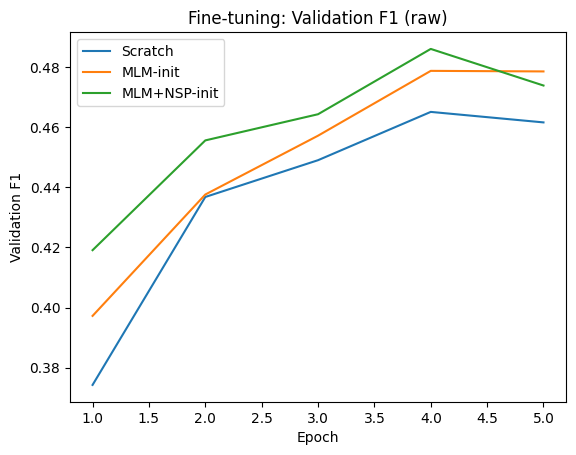

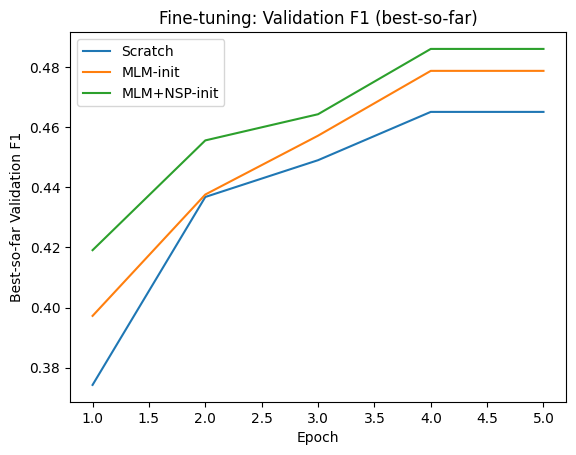

In [279]:
import matplotlib.pyplot as plt

# 1) Build hists = {...}
hists = {"Scratch": scratch_hist}

if "mlm_model" in globals() and "mlm_init_hist" in globals():
    hists["MLM-init"] = mlm_init_hist
if "pretrain_model" in globals() and "nsp_init_hist" in globals():
    hists["MLM+NSP-init"] = nsp_init_hist

def get_val_f1_list(hist):
    # handle common key variants
    if "val_f1" in hist:
        return hist["val_f1"]
    if "val_F1" in hist:
        return hist["val_F1"]
    # sometimes people store dicts per epoch; if so, adapt here
    raise KeyError(f"Couldn't find val_f1 in history keys: {list(hist.keys())}")

# 2) Plot raw validation F1 curves
plt.figure()
for name, hist in hists.items():
    vals = get_val_f1_list(hist)
    epochs = list(range(1, len(vals) + 1))
    plt.plot(epochs, vals, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("Fine-tuning: Validation F1 (raw)")
plt.legend()
plt.show()

# 3) Plot best-so-far validation F1 curves
plt.figure()
for name, hist in hists.items():
    vals = get_val_f1_list(hist)
    best_so_far = []
    best = float("-inf")
    for v in vals:
        if v > best:
            best = v
        best_so_far.append(best)
    epochs = list(range(1, len(best_so_far) + 1))
    plt.plot(epochs, best_so_far, label=name)
plt.xlabel("Epoch")
plt.ylabel("Best-so-far Validation F1")
plt.title("Fine-tuning: Validation F1 (best-so-far)")
plt.legend()
plt.show()


## Qualitative Inspection: Token-level Predictions  
Print one validation example with true vs. predicted NER tags for the best-performing fine-tuned model.

In [280]:
@torch.no_grad()
def pretty_print_ner_tokens(tokens, true_ids, pred_ids, max_tokens=60):
    """
    tokens: list[str] (already truncated to real length)
    true_ids/pred_ids: 1D lists/arrays of label ids aligned to tokens
    Prints TOKEN | TRUE | PRED | ✓/x
    Skips positions where true_id == cfg.ignore_index.
    """
    shown = 0
    print(f"{'TOKEN':20s}  {'TRUE':12s}  {'PRED':12s}  OK")
    print("-" * 52)

    for tok, t, p in zip(tokens, true_ids, pred_ids):
        if t == cfg.ignore_index:
            continue
        true_tag = id2label[int(t)]
        pred_tag = id2label[int(p)]
        ok = "✓" if int(t) == int(p) else "x"
        print(f"{tok[:20]:20s}  {true_tag:12s}  {pred_tag:12s}  {ok}")
        shown += 1
        if shown >= max_tokens:
            break


# ---- Select which model to inspect (based on BEST VAL F1, not test) ----
run_name = None
model_to_inspect = None

if "results" in globals() and isinstance(results, list) and len(results) > 0:
    # Expect rows like: {"Init": ..., "Best Val F1": ..., "model": ...} or similar
    # We'll search for the model object if you stored it, otherwise fall back to known variables.
    best_row = max(results, key=lambda r: r.get("Best Val F1", float("-inf")))
    run_name = best_row.get("Init", "BestValRun")

    # If you stored the trained model in the row (recommended), use it:
    if "model" in best_row:
        model_to_inspect = best_row["model"]

# Fallbacks if you didn't store models in `results`
if model_to_inspect is None:
    if "scratch_model" in globals():
        run_name = run_name or "Scratch"
        model_to_inspect = scratch_model
    elif "mlm_init_model" in globals():
        run_name = run_name or "MLM-init"
        model_to_inspect = mlm_init_model
    elif "nsp_init_model" in globals():
        run_name = run_name or "MLM+NSP-init"
        model_to_inspect = nsp_init_model
    else:
        raise NameError(
            "Couldn't find a fine-tuned model to inspect. "
            "Make sure you ran the fine-tuning experiments and kept a reference to the trained model."
        )

model_to_inspect.eval()

# ---- Get one batch from ft_valid_loader ----
batch = next(iter(ft_valid_loader))
input_ids      = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
token_type_ids = batch["token_type_ids"].to(device)
position_ids   = batch["position_ids"].to(device)
labels         = batch["labels"].to(device)
tokens_list    = batch["tokens"]  # list[list[str]] (kept on CPU)

# ---- Forward + predictions ----
logits = model_to_inspect(
    input_ids,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids,
    position_ids=position_ids,
)
preds = logits.argmax(dim=-1)

# ---- Show first example in batch ----
i = 0
L = int(attention_mask[i].sum().item())
tokens = tokens_list[i][:L]
true_ids = labels[i, :L].detach().cpu().tolist()
pred_ids = preds[i, :L].detach().cpu().tolist()

print(f"\nQualitative inspection run = {run_name}  | example index = {i}  | real length = {L}\n")
pretty_print_ner_tokens(tokens, true_ids, pred_ids, max_tokens=60)



Qualitative inspection run = MLM+NSP-init  | example index = 0  | real length = 29

TOKEN                 TRUE          PRED          OK
----------------------------------------------------
A                     O             O             ✓
Russian               B-NORP        I-ORG         x
diver                 O             I-ORG         x
has                   O             O             ✓
found                 O             O             ✓
the                   O             O             ✓
bodies                O             O             ✓
of                    O             O             ✓
three                 B-CARDINAL    B-CARDINAL    ✓
of                    O             O             ✓
the                   O             O             ✓
118                   B-CARDINAL    B-CARDINAL    ✓
sailors               O             O             ✓
who                   O             O             ✓
were                  O             O             ✓
killed                O      

## Concept Checks (answer in Markdown, no code)

1. **Why might MLM pretraining help NER?**  
   Explain the kind of information MLM forces the encoder to learn, and why that information could transfer to token-level labeling.

MLM forces the encoder to learn contextual word meaning, syntax, and relationships between tokens by predicting missing words from surrounding context. This builds rich token-level representations (e.g., recognizing names, locations, grammar patterns) that transfer well to NER, where the model must classify each token based on its context.

4. **Interpret the curves:** If the pretrained model reaches higher validation F1 earlier, what does that suggest?  
   Relate your answer to optimization and sample efficiency.

If the pretrained model reaches higher validation F1 earlier, it suggests better initialization and sample efficiency. The model already starts with useful language representations, so optimization is easier and requires fewer updates/data to reach good performance, leading to faster convergence and better generalization.

# Part 11 — Fine-tuning a Pretrained Transformer for NER

In this part we switch from our **from-scratch encoders** to a **pretrained Transformer** (e.g., DistilBERT/BERT) and fine-tune it for **Named Entity Recognition** using the Hugging Face `Trainer` API.

Why this matters:
- Pretraining gives strong language representations “for free”, so fine-tuning often reaches high NER performance with much less task-specific training.
- The main technical challenge for token classification is **label alignment**: our dataset labels are word-level, but the tokenizer produces **subword tokens**.
- We will also test **data efficiency** by training on different fractions of the training set and comparing Test F1.

## Choose Pretrained Backbone

Select a HuggingFace checkpoint and load its tokenizer for the pretrained NER fine-tuning experiments.

In [281]:
MODEL_NAME = "distilbert-base-cased"
# MODEL_NAME = "bert-base-cased"  # stronger but heavier

print("Using:", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print("num_labels:", num_labels)
print("example label:", id2label[12])

Using: distilbert-base-cased


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

num_labels: 37
example label: I-ORG


## Sanity Check: Labels Are Available

Quickly verify that the label mapping and label count are loaded from earlier parts.

In [282]:
# Ensure these exist from earlier parts
print("num_labels:", num_labels)
print("example label:", id2label[13])

num_labels: 37
example label: B-PERCENT


In [283]:
def tokenize_and_align_labels(examples):
    # 1) Tokenize (examples["tokens"] is a list of word lists)
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=cfg.max_len if hasattr(cfg, "max_len") else 256,  # or MAX_LEN_BERT if you have it
    )

    aligned_labels = []

    # 2) Align word-level ner_tags to token-level word_ids
    for i, word_labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)

        labels = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                # special tokens like [CLS], [SEP], padding
                labels.append(cfg.ignore_index)  # usually -100
            elif word_id != prev_word_id:
                # first subword of a word gets the word label
                labels.append(word_labels[word_id])
            else:
                # subsequent subwords: ignore (or you could repeat the label if desired)
                labels.append(cfg.ignore_index)
            prev_word_id = word_id

        aligned_labels.append(labels)

    # 3) Attach labels
    tokenized["labels"] = aligned_labels
    return tokenized


## Tokenize and Align Word-Level Labels

Convert word-level NER tags into token-level labels after subword tokenization.

In [284]:
hf_ner = DatasetDict({
    "train": ds["train"],
    "validation": ds["validation"],
    "test": ds["test"],
})

tok_ner = hf_ner.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=hf_ner["train"].column_names,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

print(tok_ner)

Map:   0%|          | 0/59924 [00:00<?, ? examples/s]

Map:   0%|          | 0/8528 [00:00<?, ? examples/s]

Map:   0%|          | 0/8262 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 59924
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 8528
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 8262
    })
})


## Trainer Metrics (Entity-Level)

Compute precision/recall/F1 from token-level predictions while ignoring special/padded positions.

In [288]:
from seqeval.metrics import precision_score, recall_score, f1_score
import numpy as np

def compute_metrics_trainer(eval_pred):
    # unpack eval_pred -> (logits, labels)
    logits, labels = eval_pred
    # logits: [B, T, C], labels: [B, T]

    # preds = argmax over last dim
    preds = np.argmax(logits, axis=-1)

    y_true_all, y_pred_all = [], []
    for lab_seq, pred_seq in zip(labels, preds):
        true_tags, pred_tags = [], []
        for l, p in zip(lab_seq, pred_seq):
            # skip ignore_index positions (pads + special tokens + subword continuations)
            if int(l) == cfg.ignore_index:
                continue
            true_tags.append(id2label[int(l)])
            pred_tags.append(id2label[int(p)])
        y_true_all.append(true_tags)
        y_pred_all.append(pred_tags)

    return {
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }


## TrainingArguments + Trainer Setup

Create version-safe HuggingFace `TrainingArguments` and `Trainer` kwargs (tokenizer/processing_class) for fine-tuning.

In [293]:
def make_training_args(
    output_dir: str,
    seed: int,
    num_train_epochs: float,
    learning_rate: float = 2e-5,
    train_bs: int = 16,
    eval_bs: int = 32,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
    eval_steps: int = 200,
    save_steps: int = 200,
    logging_steps: int = 50,
    save_total_limit: int = 1,
):
    ta_sig = inspect.signature(TrainingArguments.__init__)

    kwargs = dict(
        output_dir=output_dir,
        overwrite_output_dir=True,

        # core hyperparams
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,

        # logging / eval / saving
        logging_steps=logging_steps,
        logging_strategy="steps",
        report_to="none",
        evaluation_strategy="steps",  # may be overridden below for newer versions
        save_strategy="steps",
        eval_steps=eval_steps,
        save_steps=save_steps,
        save_total_limit=save_total_limit,

        # checkpoint selection
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        # reproducibility
        seed=seed,
        data_seed=seed,

        # token classification: keep columns needed for labels/word alignment
        remove_unused_columns=False,

        # mixed precision if available
        fp16=torch.cuda.is_available(),
    )

    # transformers version compatibility
    if "eval_strategy" in ta_sig.parameters:
        kwargs.pop("evaluation_strategy", None)
        kwargs["eval_strategy"] = "steps"

    return TrainingArguments(**kwargs)

def make_trainer_kwargs(model, args, train_dataset, eval_dataset):
    t_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics_trainer,
    )

    tr_sig = inspect.signature(Trainer.__init__)
    if "processing_class" in tr_sig.parameters:
        t_kwargs["processing_class"] = tokenizer
    else:
        t_kwargs["tokenizer"] = tokenizer

    return t_kwargs


## Tokenize + align word-level labels to subword tokens

Convert word-level NER tags into token-level labels using `word_ids()` and `ignore_index` for non-first subwords.

In [298]:
def plot_log_history(log_history, title_prefix=""):
    steps_train, loss_train = [], []
    steps_eval, f1_eval = [], []

    for item in log_history:
        if "loss" in item and "eval_loss" not in item and "step" in item:
            steps_train.append(item["step"])
            loss_train.append(item["loss"])
        if "eval_f1" in item and "step" in item:
            steps_eval.append(item["step"])
            f1_eval.append(item["eval_f1"])

    if steps_train:
        plt.figure()
        plt.plot(steps_train, loss_train)
        plt.xlabel("Step")
        plt.ylabel("Train loss")
        plt.title(f"{title_prefix} Train loss vs step")
        plt.show()

    if steps_eval:
        plt.figure()
        plt.plot(steps_eval, f1_eval, marker="o")
        plt.xlabel("Step")
        plt.ylabel("Validation F1")
        plt.title(f"{title_prefix} Val F1 vs step")
        plt.show()

## Build pretrained token-classification model

Load a pretrained backbone and adapt it to `num_labels` for NER.

In [302]:
def build_hf_ner_model():
    # Load pretrained token-classification model
    try:
        m = AutoModelForTokenClassification.from_pretrained(
            MODEL_NAME,
            num_labels=num_labels,
            id2label=id2label,
            label2id=label2id,
        )
    except TypeError:
        # older HF versions may not accept some kwargs
        m = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
        m.config.num_labels = num_labels
        m.config.id2label = id2label
        m.config.label2id = label2id

    # ensure attentions/hidden_states are OFF during Trainer runs (faster + less memory)
    m.config.output_attentions = False
    m.config.output_hidden_states = False

    return m


## Train on a fraction of the data

Subsample the training set, fine-tune, and return validation/test metrics and logs.

In [310]:
def run_data_fraction(
    frac: float,
    seed: int = 42,
    num_train_epochs: float = 1.0,
    learning_rate: float = 2e-5,
    train_bs: int = 16,
    eval_bs: int = 32,
    eval_steps: int = 200,
    save_steps: int = 200,
    logging_steps: int = 50,
):
    # ---- 1) subset of train ----
    n = len(tok_ner["train"])
    k = max(1, int(frac * n))
    sub = tok_ner["train"].shuffle(seed=seed).select(range(k))

    # ---- 2) model ----
    model = build_hf_ner_model()

    # ---- 3) training args ----
    out_dir = f"./hf_ner_frac_{frac:.3f}_seed_{seed}"
    args = make_training_args(
        output_dir=out_dir,
        seed=seed,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        train_bs=train_bs,
        eval_bs=eval_bs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_steps=eval_steps,
        save_steps=save_steps,
        logging_steps=logging_steps,
        save_total_limit=1,
    )

    # ---- 4) trainer ----
    trainer = Trainer(
        **make_trainer_kwargs(
            model=model,
            args=args,
            train_dataset=sub,
            eval_dataset=tok_ner["validation"],
        )
    )

    # ---- 5) train + eval ----
    trainer.train()

    val_metrics = trainer.evaluate(eval_dataset=tok_ner["validation"], metric_key_prefix="eval")
    test_metrics = trainer.evaluate(eval_dataset=tok_ner["test"], metric_key_prefix="test")
    log_history = trainer.state.log_history

    # ---- 6) extract test f1/loss robustly ----
    # (HF prefixes keys depending on metric_key_prefix)
    test_f1 = test_metrics.get("test_f1", test_metrics.get("eval_f1", None))
    test_loss = test_metrics.get("test_loss", test_metrics.get("eval_loss", None))

    return test_f1, test_loss, model, trainer, log_history


## Data efficiency sweep

Run the same pretrained model on multiple training fractions and plot Test F1 vs fraction.

In [322]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForTokenClassification, DataCollatorForTokenClassification
from seqeval.metrics import precision_score, recall_score, f1_score

IGNORE_INDEX = cfg.ignore_index  


def ids_to_tags_hf(labels, preds, id2label, ignore_index=IGNORE_INDEX):
    y_true_all, y_pred_all = [], []
    for lab_seq, pred_seq in zip(labels, preds):
        true_tags, pred_tags = [], []
        for l, p in zip(lab_seq, pred_seq):
            if int(l) == ignore_index:
                continue
            true_tags.append(id2label[int(l)])
            pred_tags.append(id2label[int(p)])
        y_true_all.append(true_tags)
        y_pred_all.append(pred_tags)
    return y_true_all, y_pred_all

@torch.no_grad()
def eval_hf_ner(model, loader, device, id2label):
    model.eval()

    total_loss_sum = 0.0
    total_tokens = 0
    token_correct = 0
    token_total = 0

    y_true_all, y_pred_all = [], []

    loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, reduction="sum")

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        logits = out.logits                    # [B,T,C]
        labels = batch["labels"]               # [B,T]
        preds = logits.argmax(dim=-1)          # [B,T]

        B, T, C = logits.shape
        loss_sum = loss_fn(logits.view(B * T, C), labels.view(B * T))
        n_tokens = (labels.view(-1) != IGNORE_INDEX).sum().item()

        total_loss_sum += float(loss_sum.item())
        total_tokens += int(n_tokens)

        mask = labels != IGNORE_INDEX
        token_correct += ((preds == labels) & mask).sum().item()
        token_total += mask.sum().item()

        # seqeval: append per-sequence tag lists (no padding)
        for lab_seq, pred_seq in zip(labels.detach().cpu().tolist(), preds.detach().cpu().tolist()):
            true_tags, pred_tags = [], []
            for l, p in zip(lab_seq, pred_seq):
                if int(l) == IGNORE_INDEX:
                    continue
                true_tags.append(id2label[int(l)])
                pred_tags.append(id2label[int(p)])
            y_true_all.append(true_tags)
            y_pred_all.append(pred_tags)

    return {
        "loss": total_loss_sum / max(total_tokens, 1),
        "token_acc": token_correct / max(token_total, 1),
        "precision": precision_score(y_true_all, y_pred_all),
        "recall": recall_score(y_true_all, y_pred_all),
        "f1": f1_score(y_true_all, y_pred_all),
    }

def train_one_epoch_hf_ner(model, loader, optimizer, device, grad_clip=1.0):
    model.train()
    total_loss_sum = 0.0
    total_tokens = 0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        logits = out.logits
        labels = batch["labels"]

        B, T, C = logits.shape
        loss_sum = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, reduction="sum")(
            logits.view(B * T, C), labels.view(B * T)
        )
        n_tokens = (labels.view(-1) != IGNORE_INDEX).sum().item()
        loss = loss_sum / max(n_tokens, 1)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss_sum += float(loss_sum.item())
        total_tokens += int(n_tokens)

    return total_loss_sum / max(total_tokens, 1)


def run_data_fraction_manual(
    frac: float,
    seed: int = 42,
    num_train_epochs: int = 1,
    learning_rate: float = 2e-5,
    train_bs: int = 16,
    eval_bs: int = 32,
):
    n = len(tok_ner["train"])
    k = max(1, int(frac * n))
    sub = tok_ner["train"].shuffle(seed=seed).select(range(k))

    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    train_loader = DataLoader(sub, batch_size=train_bs, shuffle=True, collate_fn=data_collator)
    valid_loader = DataLoader(tok_ner["validation"], batch_size=eval_bs, shuffle=False, collate_fn=data_collator)
    test_loader  = DataLoader(tok_ner["test"], batch_size=eval_bs, shuffle=False, collate_fn=data_collator)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    log_history = []
    for ep in range(1, num_train_epochs + 1):
        tr_loss = train_one_epoch_hf_ner(model, train_loader, optimizer, device)
        val_metrics = eval_hf_ner(model, valid_loader, device, id2label)
        log_history.append({"epoch": ep, "train_loss": tr_loss, **{f"val_{k}": v for k, v in val_metrics.items()}})

    test_metrics = eval_hf_ner(model, test_loader, device, id2label)
    return test_metrics["f1"], test_metrics["loss"], model, test_metrics, log_history


fractions = [0.10, 0.25, 1.00]
seed = cfg.seed

rows = []
logs_by_frac = {}

for f in fractions:
    print("Running fraction:", f)

    test_f1, test_loss, model, test_metrics, log_history = run_data_fraction_manual(
        frac=f,
        seed=seed,
        num_train_epochs=1,  # keep same for fairness
        learning_rate=2e-5,
        train_bs=16,
        eval_bs=32,
    )

    print("Done fraction:", f, "test_f1=", test_f1)

    rows.append({"frac": f, "test_f1": float(test_f1), "test_loss": float(test_loss)})
    logs_by_frac[f] = {"log_history": log_history, "test_metrics": test_metrics}

import pandas as pd
frac_df = pd.DataFrame(rows).sort_values("frac").reset_index(drop=True)
print(frac_df)





Running fraction: 0.1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Done fraction: 0.1 test_f1= 0.7273497754046954
Running fraction: 0.25


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Done fraction: 0.25 test_f1= 0.7922811009495471
Running fraction: 1.0


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Done fraction: 1.0 test_f1= 0.8580009716885296
   frac   test_f1  test_loss
0  0.10  0.727350   0.155544
1  0.25  0.792281   0.113627
2  1.00  0.858001   0.080606


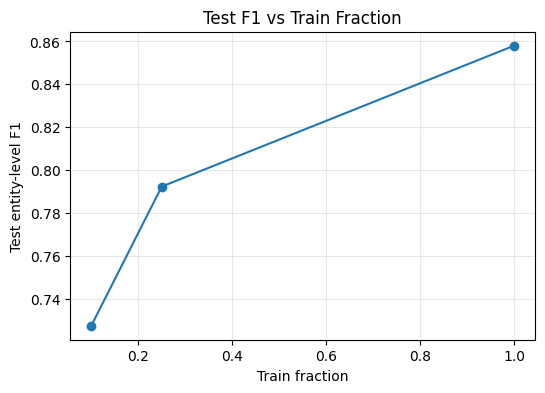

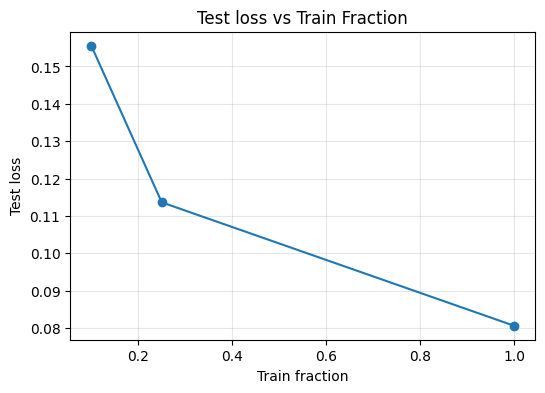


=== Fraction 0.1 ===

=== Fraction 0.25 ===

=== Fraction 1.0 ===


In [324]:
import matplotlib.pyplot as plt

# --- Test F1 vs Train Fraction ---
plt.figure(figsize=(6,4))
plt.plot(frac_df["frac"], frac_df["test_f1"], marker="o")
plt.xlabel("Train fraction")
plt.ylabel("Test entity-level F1")
plt.title("Test F1 vs Train Fraction")
plt.grid(True, alpha=0.3)
plt.show()

if "test_loss" in frac_df.columns:
    plt.figure(figsize=(6,4))
    plt.plot(frac_df["frac"], frac_df["test_loss"], marker="o")
    plt.xlabel("Train fraction")
    plt.ylabel("Test loss")
    plt.title("Test loss vs Train Fraction")
    plt.grid(True, alpha=0.3)
    plt.show()

for f in frac_df["frac"]:
    print(f"\n=== Fraction {f} ===")
    plot_log_history(logs_by_frac[f]["log_history"])


## Concept Checks (answer in Markdown, no code)

1. **Subword label alignment:**  
   Suppose a word is split into subwords, e.g. `["play", "##ing"]`.  
   - Which token(s) should receive the original word label?  
   - Which token(s) should receive `ignore_index`?  
   - Why?

Original word label: Assign the label to the first subword token (e.g., "play").

ignore_index: Assign ignore_index to the remaining subwords (e.g., "##ing").

Why: We only want one prediction per original word. Labeling every subword would duplicate supervision and distort loss/metrics, so extra subwords are ignored.

2. **Model choice trade-off:**  
   Compare using `distilbert-base-cased` vs `bert-base-cased` in terms of:
   - expected accuracy/F1
   - training/inference cost
   - when you would prefer each one

Expected accuracy/F1:

bert-base-cased: Usually higher F1/accuracy because it has more parameters and deeper representations.

distilbert-base-cased: Slightly lower performance (often a small drop), but still strong.

Training/inference cost:

bert-base-cased: Slower, more memory usage, heavier GPU/CPU cost.

distilbert-base-cased: ~40–60% faster and lighter; cheaper to train and deploy.

When to prefer each:

Use BERT-base: when maximum accuracy matters (research, final production model, enough compute).

Use DistilBERT: when you need faster training/inference, limited compute, or real-time deployment with minimal performance drop.

---

> **“In theory there is no difference between theory and practice. In practice there is.”**

This notebook is where Transformers stop being magic and start being engineering.

*Wish you luck,*  
**Sina Bayrami**

---